_______________________________________________________________________________
# Volatility Forecasting & Dynamic Risk Scaling (SPY / QQQ)
_______________________________________________________________________________

A reproducible, end-to-end time series forecasting project: **feature engineering → 21-day forward realized volatility prediction → business application (Dynamic Exposure Strategy)**.

# 1. Project overview
**Goal:** predict *future realized volatility* over a horizon **H** (default: 21 trading days ≈ 1 month) using only information available **up to the previous trading day** (no leakage).

**Why volatility?** Volatility is a core measure of risk in finance. If we can forecast it, we can adjust position sizes to maintain a stable risk level (the "business" part of this notebook).

**Assets:** SPY and QQQ (US equity ETFs).

**Outputs:**
- Forecasting results (Ridge vs HistGradientBoostingRegressor)
- A dynamic exposure strategy that uses the predicted volatility

# 2. Key finance terms (quick glossary)
- **Return (ret):** day-to-day percentage change in price (here we use log/percent returns).
- **Realized volatility:** volatility computed from past returns (e.g., rolling standard deviation). ------
- **Forward volatility target (y):** realized volatility computed over the *next* H days (the prediction target). ------
- **Sharpe ratio:** risk-adjusted return = average return / return volatility (higher is better).
- **Max drawdown:** worst peak-to-trough decline in an equity curve (risk metric).
- **Volatility targeting:** trading position sizing rule that increases exposure when predicted vol is low and decreases it when predicted vol is high.
- **Equity curve**: A line chart that shows how the value of an investment strategy evolves over time. It represents the cumulative growth of capital assuming all gains and losses are reinvested.

# 3. Reproducibility & timing assumptions

This notebook is designed to be **reproducible** (fixed seeds where relevant) and to avoid **look-ahead bias**.

- **Seeds**: we set global seeds for Python and NumPy; stochastic models/estimators also use `random_state`.
- **Data source**: market data is pulled from `yfinance`, which may update over time. For strict reproducibility, save a CSV snapshot of the downloaded OHLC data and load from disk.
- **Timing**: features use information available up to day t-1 (via .shift(1)), while the target is an **H-day forward realized volatility** computed from returns occurring over (t … t+H-1). This corresponds to taking a decision at time t using information up to t-1 and evaluating volatility from the start of day t onward.


# 4. Setup

## Imports
Below we import the libraries used throughout the notebook.

In [4]:
import os, random
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score, average_precision_score
from sklearn.inspection import permutation_importance
from IPython.display import display
import itertools
from sklearn.ensemble import HistGradientBoostingRegressor
import time


## Global configuration
We define the forecast horizon **H** and seeds for reproducibility.

In [5]:

H = 21
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# 5. Data loading
We use a small helper (`load_data`) that saves a local CSV *snapshot* the first time you download data, and reuses it later for reproducibility. -------------

In [6]:
def load_data(
    ticker: str,
    start: str,
    end: str,
    auto_adjust: bool = True,
    progress: bool = False,
    cache_dir: str = "data/raw",
) -> pd.DataFrame:
    """
    Load OHLCV data with a local CSV snapshot ("snapshot" = a frozen copy of the downloaded data).

    Workflow:
      - If the snapshot exists, load it from disk.
      - If the snapshot looks legacy/corrupted (e.g., index starts with 'Ticker') or cannot be parsed,
        re-download and overwrite it.
      - If it doesn't exist, download and save it.

    Notes:
      - yfinance often returns a DatetimeIndex; we only parse dates when reading from CSV.
      - This function normalizes yfinance output to flat columns (no MultiIndex).
      - `cache_dir` is configurable; 'data/raw' is a common project convention.
    """
    os.makedirs(cache_dir, exist_ok=True)

    adj_tag = "adj" if auto_adjust else "unadj"
    filename = f"{ticker}_{start}_{end}_{adj_tag}.csv"
    path = os.path.join(cache_dir, filename)

    def _normalize_yf(df: pd.DataFrame) -> pd.DataFrame:
        """
        Ensure yfinance output has flat columns (Close, High, Low, Open, Volume...).
        Handles MultiIndex columns like ('Close','SPY') by selecting the ticker level.
        """
        if isinstance(df.columns, pd.MultiIndex):
            # Usually levels are like names=['Price','Ticker']
            # We try to select the requested ticker on the last level.
            last_level = df.columns.get_level_values(-1)
            if ticker in last_level:
                df = df.xs(ticker, level=-1, axis=1)
            else:
                # Fallback: if only one ticker is present, take the first
                df = df.xs(last_level[0], level=-1, axis=1)

        # Optional: keep only common OHLCV columns if present
        common = [c for c in ["Open", "High", "Low", "Close", "Adj Close", "Volume"] if c in df.columns]
        if common:
            df = df[common].copy()

        return df

    def _download() -> pd.DataFrame:
        # Download single ticker. (Even if it returns MultiIndex, we normalize right after.)
        df_dl = yf.download(
            ticker,
            start=start,
            end=end,
            auto_adjust=auto_adjust,
            progress=progress,
        )
        return _normalize_yf(df_dl)

    def _save(df: pd.DataFrame) -> None:
        df = df.copy()
        df.index.name = "Date"
        df.to_csv(path)

    def _download_and_overwrite() -> pd.DataFrame:
        df_new = _download()
        _save(df_new)
        return df_new

    if os.path.exists(path):
        df = pd.read_csv(path, index_col=0)

        # Legacy/corrupt snapshot detection: first "date" is actually a header token
        if len(df.index) > 0 and str(df.index[0]) == "Ticker":
            return _download_and_overwrite()

        # Restore datetime index (robust to 'YYYY-MM-DD' and 'YYYY-MM-DD HH:MM:SS')
        try:
            df.index = pd.to_datetime(df.index, errors="raise")
        except Exception:
            return _download_and_overwrite()

        # Normalize columns in case the CSV was written from a MultiIndex structure
        df = _normalize_yf(df)
        return df

    return _download_and_overwrite()

# 6. Model Evaluation Metrics

- ROC AUC: Measures the model’s ability to distinguish between classes.

- PR AUC: Evaluates performance under class imbalance.

- Recall@TopK%: Percentage of true positives captured within the top X% highest scores.
- Recall@TopK%: Percentage of extreme volatility events captured when selecting the top X% highest predicted volatility days. Measures the model’s ability to detect tail risk.

- MAE: Average absolute prediction error.

- RMSE: Root mean squared error (penalizes large errors).

- Spearman: Rank correlation between predictions and true values.


In [7]:
def safe_roc_auc(y_true, score):
    y_true = pd.Series(y_true).astype(int)
    if y_true.nunique() < 2:
        return np.nan
    return float(roc_auc_score(y_true, score))

def safe_pr_auc(y_true, score):
    y_true = pd.Series(y_true).astype(int)
    if y_true.nunique() < 2:
        return np.nan
    return float(average_precision_score(y_true, score))

def spearman_corr(a, b):
    a = pd.Series(a).astype(float)
    b = pd.Series(b).astype(float)
    if len(a) < 3:
        return np.nan
    return float(a.corr(b, method="spearman"))

def recall_at_topk(y_true, score, top_frac=0.10):
    """Of the top X% days by score, what percentage of true positives do you capture?"""
    y_true = pd.Series(y_true).astype(int)
    score = pd.Series(score).astype(float)
    if y_true.nunique() < 2:
        return np.nan
    k = max(1, int(len(score) * top_frac))
    idx = score.sort_values(ascending=False).head(k).index
    # recall = TP / P
    P = y_true.sum()
    if P == 0:
        return np.nan
    TP = y_true.loc[idx].sum()
    return float(TP / P)


def eval_regression(y_true, y_pred):
    y_true = pd.Series(y_true).astype(float)
    y_pred = pd.Series(y_pred).astype(float).reindex(y_true.index)
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    spr = spearman_corr(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "Spearman": spr}


def eval_model_metrics_reg(model, X_tr, y_tr, X_val, y_val):
    model.fit(X_tr, y_tr)
    pred = pd.Series(model.predict(X_val), index=X_val.index)
    mae = float(mean_absolute_error(y_val, pred))
    rmse = float(np.sqrt(mean_squared_error(y_val, pred)))
    spr = float(pd.Series(y_val).corr(pred, method="spearman"))
    return mae, rmse, spr


# 7. Feature Engineering


### Target Variable

- **y_vol_fwd_H**
Forward realized volatility over the next H days (rolling standard deviation of future log returns).

This represents the uncertainty level the model aims to forecast.

### Baseline

- **vol_past_H**
Realized volatility over the past H days.

This acts as a naïve benchmark under the assumption that volatility is persistent.

## Feature Groups
_______________________
### 1. Trend / Momentum

- **mom_1w**

- **mom_1m**

- **mom_3m**

Log price change over short (1 week), medium (1 month), and long (3 months) horizons.

Why: Persistent directional moves can precede volatility expansions or regime shifts.

### 2. Historical Volatility

- **vol_1m_past**

- **vol_3m_past**

Rolling standard deviation of returns over 1 and 3 months.

Why: Volatility clustering is a well-documented time-series property.

### 3. Price Positioning (Relative Level)

- **z_price_3m**

Z-score of price relative to its 3-month rolling mean.

Why: Detects stretched conditions or deviations from recent equilibrium levels.

### 4. Shock & Tail Indicators

- **abs_ret_1d**

Absolute return of the previous day.

Why: Large shocks often increase short-term uncertainty.

- **skew_1m / skew_3m**

- **kurt_1m / kurt_3m**

Rolling skewness and kurtosis.

Why: Capture asymmetry and heavy-tailed behavior in return distributions.

### 5. Downside Risk

- **downside_vol_1m**

- **downside_vol_3m**

Volatility computed using only negative returns.

Why: Negative returns often have a stronger impact on future risk dynamics.

### 6. Regime Instability

- **vol_of_vol_1m**

Rolling standard deviation of recent volatility.

Why: Measures how stable or unstable the volatility regime is.

- **drawdown_3m**

Percentage drop from the 3-month rolling maximum.

Why: Proxy for stress conditions and potential structural shifts.

### 7. Range-Based Volatility (Optional)

- **parkinson_vol_1m**

- **parkinson_vol_3m**

Volatility estimated using intraday high–low ranges.

Why: Incorporates more price information than close-to-close returns.

In [8]:
def build_vol_dataset(
    prices: pd.Series | pd.DataFrame,
    H: int = 21,
    highs: pd.Series | None = None,
    lows: pd.Series | None = None
) -> pd.DataFrame:

    # --- ensure 1D Series (robust to Series/DataFrame inputs) ---
    if isinstance(prices, pd.DataFrame):
        prices = prices.squeeze()
    prices = pd.Series(prices).dropna().sort_index()

    if highs is not None:
        if isinstance(highs, pd.DataFrame):
            highs = highs.squeeze()
        highs = pd.Series(highs).reindex(prices.index)

    if lows is not None:
        if isinstance(lows, pd.DataFrame):
            lows = lows.squeeze()
        lows = pd.Series(lows).reindex(prices.index)


    # -----------------------------
    # Returns
    # -----------------------------
    ret = np.log(prices / prices.shift(1))
    df = pd.DataFrame({"price": prices, "ret": ret}).dropna()

    # -----------------------------
    # Feature windows
    # -----------------------------
    W_SHORT = 5
    W_MID   = 21
    W_LONG  = 63

    # Momentum
    df["mom_1w"] = np.log(df["price"].shift(1) / df["price"].shift(1 + W_SHORT))
    df["mom_1m"] = np.log(df["price"].shift(1) / df["price"].shift(1 + W_MID))
    df["mom_3m"] = np.log(df["price"].shift(1) / df["price"].shift(1 + W_LONG))

    # Past volatility features
    df["vol_1m_past"] = df["ret"].rolling(W_MID).std().shift(1)
    df["vol_3m_past"] = df["ret"].rolling(W_LONG).std().shift(1)

    # Price z-score (3m)
    mu = df["price"].rolling(W_LONG).mean().shift(1)
    sd = df["price"].rolling(W_LONG).std().shift(1)
    df["z_price_3m"] = (df["price"].shift(1) - mu) / sd

    # Absolute return shock
    df["abs_ret_1d"] = df["ret"].abs().shift(1)

    # Downside volatility
    neg_ret = df["ret"].copy()
    neg_ret[neg_ret > 0] = 0.0
    df["downside_vol_1m"] = np.sqrt((neg_ret**2).rolling(W_MID).mean()).shift(1)
    df["downside_vol_3m"] = np.sqrt((neg_ret**2).rolling(W_LONG).mean()).shift(1)

    # Skewness / Kurtosis
    df["skew_1m"] = df["ret"].rolling(W_MID).skew().shift(1)
    df["kurt_1m"] = df["ret"].rolling(W_MID).kurt().shift(1)
    df["skew_3m"] = df["ret"].rolling(W_LONG).skew().shift(1)
    df["kurt_3m"] = df["ret"].rolling(W_LONG).kurt().shift(1)

    # Vol-of-vol
    vol_1m = df["ret"].rolling(W_MID).std()
    df["vol_of_vol_1m"] = vol_1m.rolling(W_MID).std().shift(1)

    # Drawdown 3m
    rolling_max = df["price"].rolling(W_LONG).max().shift(1)
    df["drawdown_3m"] = (df["price"].shift(1) / rolling_max) - 1.0

    # Parkinson volatility (if highs/lows provided)
    if highs is not None and lows is not None:
        high = highs.reindex(df.index).astype(float)
        low = lows.reindex(df.index).astype(float)
        hl = np.log(high / low)
        parkinson_daily = np.sqrt((hl**2) / (4.0 * np.log(2.0)))
        df["parkinson_vol_1m"] = parkinson_daily.rolling(W_MID).mean().shift(1)
        df["parkinson_vol_3m"] = parkinson_daily.rolling(W_LONG).mean().shift(1)

    # Baseline (past H volatility)
    df["vol_past_H"] = df["ret"].rolling(H).std().shift(1)

    # -----------------------------
    # TARGET (future realized volatility)
    # Volatility of next H returns starting at t
    # -----------------------------
    df["y_vol_fwd_H"] = df["ret"].rolling(H).std().shift(-(H - 1))

    df = df.dropna()
    return df

The design emphasizes:

- No data leakage
- Multi-horizon signals
- Regime awareness
- Robust statistical features
- Baseline benchmarking

All features are computed using data available up to t-1 to ensure realistic out-of-sample evaluation.

# 8. Time-Series Split with Gap

The embargo gap prevents leakage from overlapping forward-looking target windows, ensuring a clean and realistic separation between training and test periods.

In [9]:
def time_split_with_gap(X: pd.DataFrame, y: pd.Series, train_ratio=0.8, gap=21):
    """
    Temporal Split 80/20 with gap:
      Train: [0 : cut)
      Gap:   [cut : cut+gap)
      Test:  [cut+gap : end)
    """
    X = X.sort_index()
    y = y.loc[X.index].copy()
    n = len(X)
    cut = int(n * train_ratio)
    tr_end = cut
    te_start = cut + gap
    if te_start >= n:
        raise ValueError("There is insufficient data for testing after applying gap.")
    return (X.iloc[:tr_end].copy(), y.iloc[:tr_end].copy(),
            X.iloc[te_start:].copy(), y.iloc[te_start:].copy())


# 9. Correlation-Based Feature Pruning 

Removes highly correlated features (|ρ| > threshold) by discarding the variable with higher average correlation to the rest of the dataset, reducing redundancy and improving model stability.

In [10]:
def drop_highly_correlated_features_smart(X: pd.DataFrame, threshold=0.85):
    corr = X.corr().abs()
    cols = corr.columns.tolist()
    to_drop = set()

    mean_corr = corr.mean(axis=1)
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    pairs = np.where(upper.values > threshold)
    pairs = list(zip(pairs[0], pairs[1]))

    for i, j in pairs:
        fi, fj = cols[i], cols[j]
        if fi in to_drop or fj in to_drop:
            continue
        # drop the most “redundant” on average
        if mean_corr[fi] >= mean_corr[fj]:
            to_drop.add(fi)
        else:
            to_drop.add(fj)

    X_reduced = X.drop(columns=list(to_drop))
    return X_reduced, sorted(list(to_drop)), corr


# 10. Model Implementations

The modeling approach contrasts:

- **Ridge Regression (with scaling)**: Regularized linear baseline model for stability and interpretability.
- **Histogram Gradient Boosting**: Nonlinear boosted model with L2 regularization and MAE loss for robustness to outliers and automatic modeling of nonlinear feature interactions.

This comparison highlights trade-offs between:

- Linear vs nonlinear structure
- Stability vs flexibility
- Model transparency vs predictive power

In [11]:
def make_model_ridge(alpha=5.0):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("reg", Ridge(alpha=alpha, random_state=42))
    ])

def make_model_hgbr(
    learning_rate=0.03,
    max_iter=600,
    max_depth=3,
    min_samples_leaf=40,
    l2_regularization=1.0,
    random_state=42
):
    return HistGradientBoostingRegressor(
        loss="absolute_error",
        learning_rate=learning_rate,
        max_iter=max_iter,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        l2_regularization=l2_regularization,
        max_bins=255,
        random_state=random_state
    )


# 11. Permutation-Based Feature Selection (Out-of-Sample)

Computes permutation importance on the validation set and selects features whose importance remains positive after accounting for variability (mean - z·std > 0).

This ensures that selected features have stable and meaningful predictive contribution.

In [12]:
def permutation_importance_oos_regression(model, X_val, y_val, scoring="neg_mean_absolute_error", n_repeats=30, random_state=42):
    r = permutation_importance(
        model, X_val, y_val,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )
    imp_df = pd.DataFrame({
        "feature": X_val.columns,
        "importance_mean": r.importances_mean,
        "importance_std": r.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    return imp_df


def select_features_by_perm_condition(imp_df: pd.DataFrame, z: float = 1.0, min_features: int = 2):
    cond = imp_df["importance_mean"] - z * imp_df["importance_std"]
    keep = imp_df.loc[cond > 0, "feature"].tolist()
    if len(keep) >= min_features:
        return keep
    return imp_df.sort_values("importance_mean", ascending=False).head(min_features)["feature"].tolist()

# 12. Walk-Forward Subset Evaluation

## Walk-Forward Validation with Embargo

Creates multiple chronological train/validation splits with a configurable gap between them to prevent temporal leakage.

Supports two training modes:

- Rolling window (default): Fixed training size (train_size)
- Expanding window: Training starts at the beginning and grows over time

### Why This Matters

- Preserves temporal ordering (no shuffling)
- Prevents leakage from overlapping forward-looking targets
- Simulates realistic retraining cycles
- Evaluates model stability across multiple time periods

In [13]:

def walkforward_splits_reg(X, y, n_splits=8, val_size=252, gap=21, expanding=False, train_size=2520):
    """
    Walk-forward at the end of the dataset (rolling by default) with gap filling.

    """
    X = X.sort_index()
    y = y.loc[X.index].copy()

    n = len(X)
    total_val = n_splits * val_size
    start_first_val = n - total_val
    if start_first_val - gap <= 0:
        raise ValueError("There is not enough data for those n_splits/val_size/gap.")

    splits = []
    for i in range(n_splits):
        val_start = start_first_val + i * val_size
        val_end = min(val_start + val_size, n)

        train_end = val_start - gap
        if train_end <= 0:
            continue

        tr_start = 0 if expanding else max(0, train_end - train_size)

        X_tr = X.iloc[tr_start:train_end]
        y_tr = y.iloc[tr_start:train_end]
        X_val = X.iloc[val_start:val_end]
        y_val = y.iloc[val_start:val_end]

        splits.append((X_tr, y_tr, X_val, y_val))

    if not splits:
        raise ValueError("Valid splits could not be generated (check parameters).")
    return splits


## Walk-Forward Feature Subset Search

Performs exhaustive feature subset evaluation using embargo-aware walk-forward validation.

Subsets are ranked by mean MAE or RMSE across multiple walk-forward splits, with the standard deviation used to assess performance stability and robustness over time.

### Why This Matters

- Fully out-of-sample evaluation
- Robustness assessed across multiple time periods
- Avoids overfitting to a single split
- Provides both performance level (mean) and stability (std)
- Enables objective-driven feature selection

In [14]:

def eval_all_subsets_walkforward_regression(
    X, y, model_factory,
    n_splits=8, val_size=252, gap=21,
    expanding=False, train_size=2520,
    min_k=1, max_k=None,
    objective="MAE"  # "MAE" o "RMSE"
):
    feats = list(X.columns)
    Kmax = len(feats) if max_k is None else min(max_k, len(feats))

    subsets = []
    for k in range(min_k, Kmax + 1):
        for comb in itertools.combinations(feats, k):
            subsets.append(list(comb))

    splits = walkforward_splits_reg(
        X, y,
        n_splits=n_splits, val_size=val_size, gap=gap,
        expanding=expanding, train_size=train_size
    )

    rows = []
    for subset in subsets:
        maes, rmses, sprs = [], [], []
        for X_tr, y_tr, X_val, y_val in splits:
            m = model_factory()
            mae, rmse, spr = eval_model_metrics_reg(m, X_tr[subset], y_tr, X_val[subset], y_val)
            maes.append(mae); rmses.append(rmse); sprs.append(spr)

        rows.append({
            "k": len(subset),
            "features": subset,
            "MAE_mean": float(np.mean(maes)),
            "MAE_std": float(np.std(maes, ddof=1)) if len(maes) > 1 else 0.0,
            "RMSE_mean": float(np.mean(rmses)),
            "RMSE_std": float(np.std(rmses, ddof=1)) if len(rmses) > 1 else 0.0,
            "Spearman_mean": float(np.nanmean(sprs)),
            "Spearman_std": float(np.nanstd(sprs, ddof=1)) if np.sum(~np.isnan(sprs)) > 1 else 0.0,
            "n_splits": len(splits),
        })

    rep = pd.DataFrame(rows)
    if objective.upper() == "RMSE":
        rep = rep.sort_values(["RMSE_mean", "Spearman_mean", "k"], ascending=[True, False, True]).reset_index(drop=True)
    else:
        rep = rep.sort_values(["MAE_mean", "Spearman_mean", "k"], ascending=[True, False, True]).reset_index(drop=True)
    return rep

# 13. Live Walk-Forward OOS Simulation

Generates production-style out-of-sample predictions by retraining the model sequentially on past data (with embargo) and predicting future blocks.

This approach mirrors real deployment conditions and ensures strictly forward-looking evaluation.

### Why This Matters

- Reflects real deployment behavior.
- Evaluates model performance under dynamic retraining.
- Tests robustness across changing time regimes.
- Avoids overly optimistic backtest-style evaluation.

In [15]:
def live_walkforward_oos_regression(
    X_is: pd.DataFrame,
    y_is: pd.Series,
    X_oos: pd.DataFrame,
    y_oos: pd.Series,
    model_factory,
    gap: int,
    block_size: int = 252,
    expanding: bool = False,
    train_size: int = 2520
):
    """
    Generates “production-type” OOS predictions:
    - in each OOS block, train ONLY with past data (embargo gap)
    - predict the next block
    """
    X_all = pd.concat([X_is, X_oos], axis=0)
    y_all = pd.concat([y_is, y_oos], axis=0)

    oos_start_pos = len(X_is)
    oos_end_pos = len(X_all)

    preds = []
    meta = []

    val_start = oos_start_pos
    while val_start < oos_end_pos:
        val_end = min(val_start + block_size, oos_end_pos)

        train_end = val_start - gap
        if train_end <= 0:
            break

        tr_start = 0 if expanding else max(0, train_end - train_size)

        X_tr = X_all.iloc[tr_start:train_end]
        y_tr = y_all.iloc[tr_start:train_end].astype(float)

        X_val = X_all.iloc[val_start:val_end]
        y_val = y_all.iloc[val_start:val_end].astype(float)

        m = model_factory()
        m.fit(X_tr, y_tr)
        yhat = m.predict(X_val)

        preds.append(pd.Series(yhat, index=X_val.index, name="yhat"))

        meta.append({
            "val_start": X_val.index.min(),
            "val_end": X_val.index.max(),
            "n_train": len(X_tr),
            "n_val": len(X_val),
            "y_tr_mean": float(y_tr.mean()),
            "y_val_mean": float(y_val.mean()),
        })

        val_start = val_end

    yhat_live = pd.concat(preds).sort_index()
    meta_live = pd.DataFrame(meta)
    return yhat_live, meta_live

# 14. Comprehensive Model Evaluation (Regression + Extreme Event Detection)

Evaluates predictive accuracy (MAE, RMSE, Spearman) and extreme volatility detection (ROC AUC, PR AUC, Recall@TopK%), with direct comparison against a baseline model.

Note: Extreme periods are defined using a volatility threshold, and the model is evaluated on its ability to detect these high-volatility events.

In [16]:

def evaluate_full(y_true, y_pred, baseline, p75_threshold, top_frac=0.10):
    y_true = y_true.loc[y_pred.index].astype(float)
    baseline = baseline.loc[y_pred.index].astype(float)
    y_pred = y_pred.astype(float)

    reg = eval_regression(y_true, y_pred)
    reg_b = eval_regression(y_true, baseline)

    high_true = (y_true > p75_threshold).astype(int)

    out = {}
    out.update(reg)
    out["MAE_baseline"] = reg_b["MAE"]
    out["RMSE_baseline"] = reg_b["RMSE"]
    out["Spearman_baseline"] = reg_b["Spearman"]

    out["ROC_AUC_HV"] = safe_roc_auc(high_true, y_pred)
    out["PR_AUC_HV"] = safe_pr_auc(high_true, y_pred)
    out[f"Recall_T{int(top_frac*100)}%_HV"] = recall_at_topk(high_true, y_pred, top_frac=top_frac)

    out["ROC_AUC_HV_baseline"] = safe_roc_auc(high_true, baseline)
    out["PR_AUC_HV_baseline"] = safe_pr_auc(high_true, baseline)
    out[f"Recall_T{int(top_frac*100)}%_HV_baseline"] = recall_at_topk(high_true, baseline, top_frac=top_frac)

    return out





In [17]:
# =========================================================
# Runner integrado (FS hasta 2022 + robustness 80/20 + final OOS 2023+ + subperiodos)
# =========================================================


# 15. End-to-End Volatility Forecasting Pipeline (Feature Selection + Production-Style OOS)

Runs the full workflow for a given ticker:

- **Load data**

Downloads adjusted prices and (optionally) High/Low for range-based volatility features.

- **Build supervised dataset**
  
Creates time-series features and defines target and baseline

- **Feature selection using only data up to fs_end (2022-12-31 inclusive), preventing leakage from future periods**
  
Removes highly correlated features (corr_thr).    
Computes out-of-sample permutation importance using a time split with embargo (gap=H).   
Runs walk-forward subset search to select the best feature subset (ranked by MAE by default). 

- **Robustness test (temporal 80/20 + live walk-forward retraining)**

The robustness test uses a chronological 80/20 split (last ~20% as the test period) and evaluates it via block-wise walk-forward retraining, predicting the test period in chunks of block_size (252) observations.

Its **goal** is to assess performance stability across different market regimes (e.g., COVID-19 crisis). Since feature selection was performed using data up to the end of 2022, this robustness period may partially overlap with data that influenced model design. Therefore, it is not a fully pure holdout.

However, it provides insight into how stable the model is over time, **how performance evolves under regime shifts**, and how it would have behaved under live retraining.

In short, **this test measures temporal consistency and robustness, not strict generalization purity**.

- **Final “pure” OOS test (2023+)**
  
Trains only on data up to fs_end (2022-12-31) and evaluates on 2023+ using the same live walk-forward procedure. This period represents the true generalization test, answering: After finalizing the entire modeling pipeline using data up to 2022, **how well does it perform on completely unseen future data?**

In [18]:
def run_pipeline_for_ticker(
    ticker: str,
    start="2005-01-01",
    end="2026-01-31",
    H=21,
    fs_end="2022-12-31",
    corr_thr=0.85,
    perm_repeats=30,
    perm_z=1.0,
    subset_n_splits=8,
    subset_val_size=252,
    subset_max_k=8,
    alpha=5.0,
    top_frac=0.10,
    robustness_train_ratio=0.80,   # temporal split for robustness
    block_size=252,                # Approximate annual block for walk-forward
    expanding=False,
    train_size=2520,
    model_type="hgbr"
):
    """
    Version with Robustness and Final OOS in “production” mode using live_walkforward_oos_regression.

    Requires the following to already exist:
      - build_vol_dataset
      - drop_highly_correlated_features_smart
      - make_model
      - permutation_importance_oos_regression
      - select_features_by_perm_condition
      - eval_all_subsets_walkforward_regression
      - time_split_with_gap
      - live_walkforward_oos_regression  
      - evaluate_full
    """
    # -----------------------------
    # Model factory (Ridge vs HGBR)
    # -----------------------------
    if model_type == "ridge":
        model_factory = lambda: make_model_ridge(alpha=alpha)
    elif model_type == "hgbr":
        model_factory = lambda: make_model_hgbr()
    else:
        raise ValueError("model_type must be 'ridge' or 'hgbr'")

    # -----------------------------
    # 1) Download OHLC (Parkinson needs High/Low)

    # -----------------------------
    raw = load_data(ticker, start=start, end=end, auto_adjust=True, progress=False)
    
    close = raw["Close"].dropna()
    highs = raw["High"].dropna()
    lows  = raw["Low"].dropna()

    # -----------------------------
    # 2) Dataset vol (includes Parkinson if highs/lows are not None)
    # -----------------------------
    df = build_vol_dataset(close, H=H, highs=highs, lows=lows)

    target = "y_vol_fwd_H"
    baseline_col = "vol_past_H"

    base_features = [
        "mom_1w","mom_1m","mom_3m",
        "vol_1m_past","vol_3m_past","z_price_3m",
        "abs_ret_1d",
        "downside_vol_1m","downside_vol_3m",
        "skew_1m","kurt_1m","skew_3m","kurt_3m",
        "vol_of_vol_1m",
        "drawdown_3m",
        "vol_past_H",
    ]
    parkinson_feats = ["parkinson_vol_1m", "parkinson_vol_3m"]
    features_all = base_features + [c for c in parkinson_feats if c in df.columns]

    # -----------------------------
    # 3) Feature Selection dataset (<= fs_end)
    # -----------------------------
    fs_end_dt = pd.to_datetime(fs_end)
    df_fs = df.loc[df.index <= fs_end_dt].copy()
    if len(df_fs) < 500:
        raise ValueError("FS dataset too small. Check fs_end or data range.")

    X_fs = df_fs[features_all].copy()
    y_fs = df_fs[target].copy().astype(float)

    # 3.1 Collinearity
    X_c, dropped_corr, corr = drop_highly_correlated_features_smart(X_fs, threshold=corr_thr)
    y_c = y_fs.loc[X_c.index].copy()

    # 3.2 Permutation importance (internal split 80/20 with gap=H)
    X_tr, y_tr, X_val, y_val = time_split_with_gap(X_c, y_c, train_ratio=0.8, gap=H)

    m0 = model_factory()
    m0.fit(X_tr, y_tr)
    imp_df = permutation_importance_oos_regression(
        m0, X_val, y_val,
        scoring="neg_mean_absolute_error",
        n_repeats=perm_repeats
    )
    perm_keep = select_features_by_perm_condition(imp_df, z=perm_z, min_features=2)

    # 3.3 Walk-forward best subset (on perm_keep)
    X_subset = X_c[perm_keep].copy()
    y_subset = y_c.loc[X_subset.index].copy()

    rep_subsets = eval_all_subsets_walkforward_regression(
        X_subset, y_subset,
        model_factory= model_factory,
        n_splits=subset_n_splits,
        val_size=subset_val_size,
        gap=H,
        expanding=expanding,
        train_size=train_size,
        min_k=1,
        max_k=min(subset_max_k, len(perm_keep)),
        objective="MAE"
    )
    features_final = list(rep_subsets.iloc[0]["features"])

    # ============================================================
    # 4) ROBUSTNESS TEST (80/20 time split) -> WALK-FORWARD “PRODUCTION”
    # ============================================================
    X_all = df[features_final].copy()
    y_all = df[target].copy().astype(float)
    base_all = df[baseline_col].copy().astype(float)

    # 80/20 split with gap (gap=H)
    X_tr_r, y_tr_r, X_te_r, y_te_r = time_split_with_gap(
        X_all, y_all, train_ratio=robustness_train_ratio, gap=H
    )

    # P75 threshold calculated ONLY in terms of robustness
    p75_r = float(y_tr_r.quantile(0.75))

    # Walk-forward production-like on the test section (X_te_r)
    yhat_r, meta_r = live_walkforward_oos_regression(
        X_is=X_tr_r, y_is=y_tr_r,
        X_oos=X_te_r, y_oos=y_te_r,
        model_factory=model_factory,
        gap=H,
        block_size=block_size,
        expanding=expanding,
        train_size=train_size
    )

    # Align y_true and baseline to the generated predictions (in case there are edges)
    y_true_r = y_te_r.loc[yhat_r.index].astype(float)
    base_te_r = base_all.loc[yhat_r.index].astype(float)

    metrics_robustness = evaluate_full(
        y_true_r, yhat_r, base_te_r,
        p75_threshold=p75_r, top_frac=top_frac
    )

    # ============================================================
    #5) FINAL OOS PURO (2023+) -> WALK-FORWARD “PRODUCTION”
    # ============================================================
    test_start = pd.to_datetime("2023-01-01")
    df_train_final = df.loc[df.index <= fs_end_dt].copy()
    df_test_final  = df.loc[df.index >= test_start].copy()

    if len(df_test_final) <= H + 50:
        raise ValueError("OOS final too small after applying embargo. Check end or H.")

    # Explicit embargo at the start of the final test (to avoid “sticking” to the edge)
    df_test_final = df_test_final.iloc[H:].copy()

    X_tr_f = df_train_final[features_final].copy()
    y_tr_f = df_train_final[target].copy().astype(float)

    X_te_f = df_test_final[features_final].copy()
    y_te_f = df_test_final[target].copy().astype(float)

    # P75 threshold ONLY with final train (≤ 2022)
    p75_f = float(y_tr_f.quantile(0.75))

    # Walk-forward production (train with past data and predict in blocks within 2023+)
    yhat_f, meta_f = live_walkforward_oos_regression(
        X_is=X_tr_f, y_is=y_tr_f,
        X_oos=X_te_f, y_oos=y_te_f,
        model_factory=model_factory,
        gap=H,
        block_size=block_size,
        expanding=expanding,
        train_size=train_size
    )

    y_true_f = y_te_f.loc[yhat_f.index].astype(float)
    base_te_f = df.loc[yhat_f.index, baseline_col].astype(float)

    metrics_final_oos = evaluate_full(
        y_true_f, yhat_f, base_te_f,
        p75_threshold=p75_f, top_frac=top_frac
    )

    return {
        "ticker": ticker,
        "model_type": model_type,

        # FS
        "fs_end": fs_end,
        "features_all": features_all,
        "features_final": features_final,
        "dropped_corr": dropped_corr,
        "corr": corr,
        "perm_importance": imp_df,
        "perm_keep": perm_keep,
        "subset_report": rep_subsets,

        # Robustness (walk-forward)
        "robustness_train_ratio": robustness_train_ratio,
        "robustness_train_period": (X_tr_r.index.min(), X_tr_r.index.max()),
        "robustness_test_period": (X_te_r.index.min(), X_te_r.index.max()),
        "robustness_yhat": yhat_r,
        "robustness_y_true": y_true_r,
        "p75_r": p75_r,
        "robustness_meta": meta_r,
        "metrics_robustness": metrics_robustness,
        "robustness_baseline": base_te_r,

        

        # Final OOS (walk-forward)
        "final_train_period": (X_tr_f.index.min(), X_tr_f.index.max()),
        "final_test_period": (X_te_f.index.min(), X_te_f.index.max()),
        "final_yhat": yhat_f,
        "final_y_true": y_true_f,
        "p75_f": p75_f,
        "final_meta": meta_f,
        "metrics_final_oos": metrics_final_oos,
        "final_baseline": base_te_f
    }


# 16. Baseline Benchmarking Utilities

Adds a baseline row per ticker (from *_baseline columns) for consistent reporting

In [19]:
def add_baseline_rows(summary: pd.DataFrame) -> pd.DataFrame:
    df = summary.copy()

    model_metrics = [c for c in df.columns if not c.endswith("_baseline")]
    base_metrics  = [c for c in df.columns if c.endswith("_baseline")]

    baseline_rows = []
    for ticker in df.index.get_level_values(0).unique():
        one = df.loc[(ticker, df.loc[ticker].index[0])]  

        row = {"ticker": ticker, "model": "baseline"}
        for c in base_metrics:
            row[c.replace("_baseline", "")] = one[c]
        row["n_features"] = 1
        baseline_rows.append(row)

    baseline_df = pd.DataFrame(baseline_rows).set_index(["ticker", "model"])

    df2 = df[model_metrics].copy()
    out = pd.concat([df2, baseline_df], axis=0)

    order = ["baseline", "ridge", "hgbr"]
    out = out.reset_index()
    out["model"] = pd.Categorical(out["model"], categories=order, ordered=True)
    out = out.sort_values(["ticker", "model"]).set_index(["ticker", "model"])

    return out


Computes the percentage improvement in MAE/RMSE and the absolute differences in scoring metrics relative to the baseline, summarizing the model’s performance lift.

In [20]:
def diff_vs_baseline(
    absolute_df: pd.DataFrame,
    error_metrics=("MAE", "RMSE"),
    score_metrics=("Spearman", "ROC_AUC_HV","PR_AUC_HV", "Recall_T10%_HV")
) -> pd.DataFrame:
    out_rows = []

    for ticker in absolute_df.index.get_level_values(0).unique():
        base = absolute_df.loc[(ticker, "baseline")]

        for model in absolute_df.loc[ticker].index:
            row = {"ticker": ticker, "model": model}

            for m in error_metrics:
                row[f"{m}_impr_vs_base_%"] = 0.0 if model == "baseline" else 100 * (base[m] - absolute_df.loc[(ticker, model), m]) / base[m]

            for m in score_metrics:
                row[f"Δ{m}_vs_base"] = 0.0 if model == "baseline" else (absolute_df.loc[(ticker, model), m] - base[m])

            out_rows.append(row)

    diff_df = pd.DataFrame(out_rows).set_index(["ticker", "model"])

    order = ["baseline", "ridge", "hgbr"]
    diff_df = diff_df.reset_index()
    diff_df["model"] = pd.Categorical(diff_df["model"], categories=order, ordered=True)
    diff_df = diff_df.sort_values(["ticker", "model"]).set_index(["ticker", "model"])

    return diff_df

# 17. Model Execution & Cross-Ticker Comparison (SPY vs QQQ)

Runs the full pipeline for Ridge and HGBR on SPY and QQQ, reporting:

- Robustness metrics
- Final pure OOS metrics
- Selected feature counts
- Execution time

Enables direct comparison across models and assets.

In [21]:
# --- SPY Ridge ---

start = time.perf_counter()
res_spy_ridge = run_pipeline_for_ticker("SPY", H=H, model_type="ridge", perm_repeats=50, block_size=63, train_size=1260)
print(f" SPY Ridge time: {time.perf_counter() - start:.2f} seconds")

# --- SPY HGBR ---
start = time.perf_counter()
res_spy_hgbr = run_pipeline_for_ticker("SPY", H=H, model_type="hgbr", perm_repeats=50, block_size=63, train_size=1260)
elapsed = time.perf_counter() - start
print(f" SPY HGBR time: {elapsed/60:.2f} minutes")

# --- QQQ Ridge ---
start = time.perf_counter()
res_qqq_ridge = run_pipeline_for_ticker("QQQ", H=H, model_type="ridge", perm_repeats=50, block_size=63, train_size=1260)
print(f" QQQ Ridge time: {time.perf_counter() - start:.2f} seconds")

# --- QQQ HGBR ---
start = time.perf_counter()
res_qqq_hgbr = run_pipeline_for_ticker("QQQ", H=H, model_type="hgbr", perm_repeats=50, block_size=63, train_size=1260)
elapsed = time.perf_counter() - start
print(f" QQQ HGBR time: {elapsed/60:.2f} minutes")

summary_robust_compare = pd.DataFrame([
    {"ticker":"SPY", "model":"ridge", **res_spy_ridge["metrics_robustness"], "n_features": len(res_spy_ridge["features_final"])},
    {"ticker":"SPY", "model":"hgbr", **res_spy_hgbr["metrics_robustness"], "n_features": len(res_spy_hgbr["features_final"])},
    {"ticker":"QQQ", "model":"ridge", **res_qqq_ridge["metrics_robustness"], "n_features": len(res_qqq_ridge["features_final"])},
    {"ticker":"QQQ", "model":"hgbr", **res_qqq_hgbr["metrics_robustness"], "n_features": len(res_qqq_hgbr["features_final"])},
]).set_index(["ticker","model"])

summary_final_compare = pd.DataFrame([
    {"ticker":"SPY", "model":"ridge", **res_spy_ridge["metrics_final_oos"], "n_features": len(res_spy_ridge["features_final"])},
    {"ticker":"SPY", "model":"hgbr", **res_spy_hgbr["metrics_final_oos"], "n_features": len(res_spy_hgbr["features_final"])},
    {"ticker":"QQQ", "model":"ridge", **res_qqq_ridge["metrics_final_oos"], "n_features": len(res_qqq_ridge["features_final"])},
    {"ticker":"QQQ", "model":"hgbr", **res_qqq_hgbr["metrics_final_oos"], "n_features": len(res_qqq_hgbr["features_final"])},
]).set_index(["ticker","model"])



 SPY Ridge time: 10.20 seconds
 SPY HGBR time: 4.28 minutes
 QQQ Ridge time: 10.43 seconds
 QQQ HGBR time: 2.23 minutes


# Feature Selection Summary

# Correlation-Based Feature Filtering

Before model selection, highly correlated predictors were removed to reduce redundancy and mitigate multicollinearity.

In [59]:
def show_corr_summary(res, label):
    dropped = res["dropped_corr"]
    total_before = len(res["features_all"])
    total_after  = len(res["features_final"])
    
    print(f"\n==================== {label} | Correlation Filter ====================")
    print(f"Initial features: {total_before}")
    print(f"Final features: {total_after}")
    print(f"Dropped due to correlation: {len(dropped)} ({round(100*len(dropped)/total_before,1)}%)")
    
    if len(dropped) > 0:
        print("Dropped features:", dropped)

In [60]:
show_corr_summary(res_spy_ridge, "SPY - Ridge")
show_corr_summary(res_spy_hgbr,  "SPY - HGBR")
show_corr_summary(res_qqq_ridge, "QQQ - Ridge")
show_corr_summary(res_qqq_hgbr,  "QQQ - HGBR")


==================== SPY - Ridge | Correlation Filter ====================
Initial features: 18
Final features: 3
Dropped due to correlation: 6 (33.3%)
Dropped features: ['downside_vol_1m', 'downside_vol_3m', 'drawdown_3m', 'parkinson_vol_1m', 'vol_1m_past', 'vol_3m_past']

==================== SPY - HGBR | Correlation Filter ====================
Initial features: 18
Final features: 4
Dropped due to correlation: 6 (33.3%)
Dropped features: ['downside_vol_1m', 'downside_vol_3m', 'drawdown_3m', 'parkinson_vol_1m', 'vol_1m_past', 'vol_3m_past']

==================== QQQ - Ridge | Correlation Filter ====================
Initial features: 18
Final features: 2
Dropped due to correlation: 6 (33.3%)
Dropped features: ['downside_vol_1m', 'downside_vol_3m', 'drawdown_3m', 'parkinson_vol_1m', 'vol_1m_past', 'vol_3m_past']

==================== QQQ - HGBR | Correlation Filter ====================
Initial features: 18
Final features: 3
Dropped due to correlation: 6 (33.3%)
Dropped features: ['down

**Interpretation**

* Roughly one-third of the original features were redundant from a correlation standpoint.
* Most dropped variables are alternative volatility proxies, indicating strong overlap within volatility-based measures.
* The filtering step simplifies the feature space without materially reducing informational content.

**Why This Matters**

* Reduces noise and overfitting risk.
* Improves interpretability.
* Ensures that subsequent model differences are not driven by multicollinearity.

# Permutation Feature Importance

This function reports permutation-based feature importance, separating predictors that contribute positively from those that degrade performance.

Permutation importance measures how much model error increases when a feature is randomly shuffled.
Higher positive values indicate stronger predictive contribution.


**Why This Matters**

- Identifies the true drivers of predictive performance.
- Detects redundant or potentially harmful predictors.
- Provides model-agnostic interpretability (works for both Ridge and HGBR).
- Validates whether selected features genuinely contribute to out-of-sample performance


**Interpretation Guidelines**   
- Consistently positive importance across assets suggests structural predictive relevance.
- Features with near-zero importance may be redundant.
- Negative importance signals potential overfitting or noise sensitivity.

For each feature:
- Positive importance → Model performance deteriorates when the feature is shuffled → the feature adds predictive value.
- Negative importance → Model performance improves when the feature is shuffled → the feature may introduce noise or instability.

In [61]:
def show_importance_tables(res, label):
    imp = res["perm_importance"].sort_values("importance_mean", ascending=False)

    # Separate positives and negatives
    imp_pos = imp[imp["importance_mean"] > 0].sort_values("importance_mean", ascending=False)
    imp_neg = imp[imp["importance_mean"] < 0].sort_values("importance_mean", ascending=True)

    print(f"\n==================== {label} ====================")

    if len(imp_pos) > 0:
        print("\nPositive Permutation Importance:")
        display(imp_pos.round(6))

    if len(imp_neg) > 0:
        print("\nNegative Permutation Importance:")
        display(imp_neg.round(6))

## SPY- Ridge

In [62]:
show_importance_tables(res_spy_ridge, "SPY - Ridge")


==================== SPY - Ridge ====================

Positive Permutation Importance:


,feature,importance_mean,importance_std
0,vol_past_H,0.000957,0.000084
1,mom_1w,0.000235,0.000043
2,mom_3m,0.000059,0.000016
3,parkinson_vol_3m,0.000052,0.000038
4,mom_1m,0.000023,0.000025
5,kurt_1m,0.000020,0.000008
6,skew_3m,0.000019,0.000013
7,skew_1m,0.000002,0.000001



Negative Permutation Importance:


,feature,importance_mean,importance_std
11,vol_of_vol_1m,-0.000088,0.000018
10,abs_ret_1d,-0.000008,0.000013
9,kurt_3m,-0.000008,0.000013
8,z_price_3m,-0.000004,0.000003


**Top contributor**:

vol_past_H (by far the strongest signal)

**Interpretation**

SPY Ridge performance is primarily driven by volatility persistence. Momentum adds incremental value, while skewness and kurtosis measures (distribution asymmetry and tail risk) as well as volatility-of-volatility metrics contribute little or may introduce noise.

## SPY - HGBR

In [63]:
show_importance_tables(res_spy_hgbr,  "SPY - HGBR")


==================== SPY - HGBR ====================

Positive Permutation Importance:


,feature,importance_mean,importance_std
0,z_price_3m,0.000122,0.000022
1,vol_past_H,0.000111,0.000056
2,mom_1w,0.000109,0.000017
3,mom_1m,0.000102,0.000014
4,skew_3m,0.000040,0.000028
5,kurt_1m,0.000038,0.000009
6,abs_ret_1d,0.000001,0.000001



Negative Permutation Importance:


,feature,importance_mean,importance_std
11,kurt_3m,-0.000125,0.000025
10,mom_3m,-0.000096,0.000021
9,skew_1m,-0.000086,0.000010
8,parkinson_vol_3m,-0.000085,0.000072
7,vol_of_vol_1m,-0.000062,0.000025


**Top contributors**:

- z_price_3m
- vol_past_H
- mom_1w
- mom_1m

**Interpretation**   
HGBR distributes importance more evenly across features. It extracts value from price normalization and multiple momentum horizons, but several skewness and kurtosis features show negative importance, suggesting the model may be sensitive to unstable tail-risk measures.

#  QQQ - Ridge

In [64]:
show_importance_tables(res_qqq_ridge, "QQQ - Ridge")


==================== QQQ - Ridge ====================

Positive Permutation Importance:


,feature,importance_mean,importance_std
0,vol_past_H,0.000973,0.000077
1,parkinson_vol_3m,0.000367,0.000058
2,mom_1w,0.000260,0.000053
3,mom_1m,0.000197,0.000048
4,z_price_3m,0.000075,0.000020
5,mom_3m,0.000023,0.000006
6,abs_ret_1d,0.000020,0.000014
7,vol_of_vol_1m,0.000017,0.000003



Negative Permutation Importance:


,feature,importance_mean,importance_std
11,skew_1m,-0.000012,0.000006
10,kurt_1m,-0.000009,0.000008
9,kurt_3m,-0.000005,0.000003
8,skew_3m,-0.000002,0.000009


**Top contributors**:

- vol_past_H
- parkinson_vol_3m
- mom_1w
- mom_1m

**Interpretation**   
For QQQ, volatility measures dominate even more clearly. Momentum contributes meaningfully, while skewness and kurtosis (measures of return asymmetry and tail risk) provide little incremental value.

## QQQ - HGBR

In [65]:
show_importance_tables(res_qqq_hgbr,  "QQQ - HGBR")


==================== QQQ - HGBR ====================

Positive Permutation Importance:


,feature,importance_mean,importance_std
0,parkinson_vol_3m,0.000390,0.000092
1,vol_past_H,0.000201,0.000065
2,z_price_3m,0.000196,0.000025
3,mom_1w,0.000146,0.000024
4,mom_1m,0.000080,0.000018



Negative Permutation Importance:


,feature,importance_mean,importance_std
11,kurt_3m,-0.000168,0.000037
10,skew_3m,-0.000127,0.000037
9,skew_1m,-0.000103,0.000013
8,kurt_1m,-0.000027,0.000010
7,mom_3m,-0.000015,0.000018
6,vol_of_vol_1m,-0.000005,0.000007
5,abs_ret_1d,-0.000001,0.000001


**Top contributors**:

- parkinson_vol_3m
- vol_past_H
- z_price_3m
- mom_1w

**Interpretation**   
HGBR relies heavily on volatility-based features and price normalization. However, several skewness and kurtosis (measures of return asymmetry and tail risk) features degrade performance when shuffled, suggesting nonlinear sensitivity to noisy tail-risk variables.

## Cross-Asset & Cross-Model Insights

- Volatility is the dominant structural driver across all models and assets.
- Short-term momentum consistently adds value.
- Higher-moment features (skewness, kurtosis) often contribute little or negatively.
- Nonlinear models exhibit:
    - More distributed importance
    - Greater sensitivity to noisy features

# Final Selected Features by Model and Asset

This section reports the optimal feature combination selected via cross-validated MAE minimization, including average error and stability across splits.

In [66]:
def show_best_subset(res, label):
    best = res["subset_report"].iloc[0]

    print(f"\n==================== {label} | Best Subset ====================")
    print("Objective value (MAE_mean):", round(best["MAE_mean"], 6))
    print("MAE std across splits:", round(best["MAE_std"], 6))
    print("Number of features:", best["k"])
    print("Features:", best["features"])

In [67]:
show_best_subset(res_spy_ridge, "SPY - Ridge")
show_best_subset(res_spy_hgbr,  "SPY - HGBR")
show_best_subset(res_qqq_ridge, "QQQ - Ridge")
show_best_subset(res_qqq_hgbr,  "QQQ - HGBR")


==================== SPY - Ridge | Best Subset ====================
Objective value (MAE_mean): 0.003341
MAE std across splits: 0.001675
Number of features: 3
Features: ['vol_past_H', 'mom_1w', 'kurt_1m']

==================== SPY - HGBR | Best Subset ====================
Objective value (MAE_mean): 0.003721
MAE std across splits: 0.002243
Number of features: 4
Features: ['vol_past_H', 'mom_1w', 'mom_1m', 'kurt_1m']

==================== QQQ - Ridge | Best Subset ====================
Objective value (MAE_mean): 0.003812
MAE std across splits: 0.001736
Number of features: 2
Features: ['vol_past_H', 'mom_1w']

==================== QQQ - HGBR | Best Subset ====================
Objective value (MAE_mean): 0.004125
MAE std across splits: 0.002438
Number of features: 3
Features: ['vol_past_H', 'z_price_3m', 'mom_1w']


# Feature Structure: Linear vs Nonlinear Models

This section compares the final predictors selected by the linear (Ridge) and nonlinear (HGBR) models to examine whether the nonlinear model relies on fundamentally different signals or mainly extends the same core feature structure.

### SPY — Model Comparison

In [68]:
spy_feats_ridge = set(res_spy_ridge["features_final"])
spy_feats_hgbr = set(res_spy_hgbr["features_final"])
qqq_feats_ridge = set(res_qqq_ridge["features_final"])
qqq_feats_hgbr = set(res_qqq_hgbr["features_final"])

print("\nCommon features (Ridge & HGBR - SPY):", spy_feats_ridge & spy_feats_hgbr)
print("Only Ridge:", spy_feats_ridge - spy_feats_hgbr)
print("Only HGBR:", spy_feats_hgbr - spy_feats_ridge)


Common features (Ridge & HGBR - SPY): {'kurt_1m', 'mom_1w', 'vol_past_H'}
Only Ridge: set()
Only HGBR: {'mom_1m'}


**Interpretation**

For SPY, both models rely on the same core predictive structure: volatility, short-term momentum, and return distribution asymmetry (kurtosis).   
HGBR adds one additional medium-term momentum feature, suggesting incremental nonlinear refinement rather than a structurally different signal.

### QQQ — Model Comparison

In [117]:
print("\nCommon features (Ridge & HGBR - QQQ):", qqq_feats_ridge & qqq_feats_hgbr)
print("Only Ridge:", qqq_feats_ridge - qqq_feats_hgbr)
print("Only HGBR:", qqq_feats_hgbr - qqq_feats_ridge)


Common features (Ridge & HGBR - QQQ): {'mom_1w', 'vol_past_H'}
Only Ridge: set()
Only HGBR: {'z_price_3m'}


**Interpretation**   
For QQQ, both models again share the same structural backbone (volatility + short-term momentum).   
HGBR introduces a price-normalization feature, indicating asset-specific nonlinear adaptation.

**Takeaways**

- Core predictors (vol_past_H, mom_1w) are stable across models and assets → evidence of a robust underlying signal.
- The nonlinear model does not replace the linear structure — it builds on top of it.
- HGBR adds a limited number of asset-specific features, while the core predictive signals remain shared across models.

**Overall**: The nonlinear model improves results by slightly enhancing the same core signals used by the linear model, not by finding a completely new predictive pattern.

# Cross-Asset Feature Portability (SPY vs QQQ)

This section compares the final predictors selected for SPY and QQQ to examine whether the same signals consistently emerge across assets or whether feature selection reflects asset-specific dynamics.

## Ridge — High Structural Consistency

In [70]:
print("\nCommon features (SPY & QQQ - Ridge):", spy_feats_ridge & qqq_feats_ridge)
print("Only SPY:", spy_feats_ridge - qqq_feats_ridge)
print("Only QQQ:", qqq_feats_ridge - spy_feats_ridge)



Common features (SPY & QQQ - Ridge): {'mom_1w', 'vol_past_H'}
Only SPY: {'kurt_1m'}
Only QQQ: set()


**Interpretation**   
Ridge exhibits strong cross-asset stability.
The core signal (volatility + short-term momentum) remains identical across markets, with only a minor distributional feature (kurt_1m) appearing exclusively in SPY.
This suggests that the linear signal structure is largely portable across assets.

## HGBR — Greater Asset Adaptation

In [71]:
print("\nCommon features (SPY & QQQ - Hgbr):", spy_feats_hgbr & qqq_feats_hgbr)
print("Only SPY:", spy_feats_hgbr - qqq_feats_hgbr)
print("Only QQQ:", qqq_feats_hgbr - spy_feats_hgbr)


Common features (SPY & QQQ - Hgbr): {'mom_1w', 'vol_past_H'}
Only SPY: {'kurt_1m', 'mom_1m'}
Only QQQ: {'z_price_3m'}


**Interpretation**

HGBR maintains the same core backbone but introduces additional asset-dependent features.
For SPY, it expands into higher-moment and medium-term momentum signals.
For QQQ, it incorporates a price-normalization term.

This suggests that the nonlinear model adapts more flexibly to asset-specific dynamics.

**Overall Insight**   
- The predictive backbone (volatility + short-term momentum) is stable across assets and models.
- Ridge demonstrates stronger structural portability.
- HGBR adds selective refinements that vary across assets, suggesting that part of the signal structure is asset-specific.

Overall, both assets share the same core predictive structure, with volatility and short-term momentum appearing consistently across models. Differences across assets are incremental rather than structural. However, the nonlinear model introduces additional asset-specific features, resulting in a more adaptive but less uniform feature structure across assets.

# 18. Performance Tables: Absolute Metrics & Differences vs Baseline

- **Absolute tables** show raw performance levels.

- **Relative tables** highlight whether models truly outperform the baseline and by how much.

In [22]:
#1) ABSOLUTE table (baseline as row)
robust_abs = add_baseline_rows(summary_robust_compare)
final_abs  = add_baseline_rows(summary_final_compare)


#2) DIFFERENCES vs. BASELINE Table
robust_diff = diff_vs_baseline(
    robust_abs,
    error_metrics=("MAE","RMSE"),
    score_metrics=("Spearman","ROC_AUC_HV","PR_AUC_HV","Recall_T10%_HV")
)

final_diff = diff_vs_baseline(
    final_abs,
    error_metrics=("MAE","RMSE"),
    score_metrics=("Spearman","ROC_AUC_HV","PR_AUC_HV","Recall_T10%_HV")
)

In [23]:
print("\n==================== ROBUSTNESS (Absolute) ====================")
display(robust_abs.round(6))

print("\n==================== ROBUSTNESS (Δ vs Baseline) ====================")
display(robust_diff.round(3))



==================== ROBUSTNESS (Absolute) ====================


MAE      RMSE  Spearman  ROC_AUC_HV  PR_AUC_HV  \
ticker model                                                           
QQQ    baseline  0.003636  0.005507  0.652917    0.881222   0.789536   
       ridge     0.003582  0.004829  0.606047    0.817481   0.742787   
       hgbr      0.003461  0.004638  0.568342    0.833351   0.781649   
SPY    baseline  0.003132  0.005008  0.618694    0.854691   0.675500   
       ridge     0.003008  0.004241  0.587119    0.830599   0.680956   
       hgbr      0.002751  0.004070  0.610367    0.848165   0.720761   

                 Recall_T10%_HV  n_features  
ticker model                                 
QQQ    baseline        0.221662           1  
       ridge           0.221662           2  
       hgbr            0.239295           3  
SPY    baseline        0.278523           1  
       ridge           0.271812           3  
       hgbr            0.288591           4


==================== ROBUSTNESS (Δ vs Baseline) ====================


MAE_impr_vs_base_%  RMSE_impr_vs_base_%  ΔSpearman_vs_base  \
ticker model                                                                  
QQQ    baseline               0.000                0.000              0.000   
       ridge                  1.503               12.318             -0.047   
       hgbr                   4.831               15.778             -0.085   
SPY    baseline               0.000                0.000              0.000   
       ridge                  3.963               15.309             -0.032   
       hgbr                  12.167               18.729             -0.008   

                 ΔROC_AUC_HV_vs_base  ΔPR_AUC_HV_vs_base  \
ticker model                                               
QQQ    baseline                0.000               0.000   
       ridge                  -0.064              -0.047   
       hgbr                   -0.048              -0.008   
SPY    baseline                0.000               0.000   
       ridge                  -0.024               0.005   
       hgbr                   -0.007               0.045   

                 ΔRecall_T10%_HV_vs_base  
ticker model                              
QQQ    baseline                    0.000  
       ridge                       0.000  
       hgbr                        0.018  
SPY    baseline                    0.000  
       ridge                      -0.007  
       hgbr                        0.010

### Robustness Test (80/20 + Walk-Forward)
_____________________________________________________________________________________________________________________________________________

**QQQ**

- Error reduction is modest:
    - Ridge: +1.5% MAE improvement
    - HGBR: +4.8% MAE improvement
- RMSE improvements are stronger (12–16%).
- However, both models underperform the baseline in Spearman, ROC AUC, and PR AUC.
- HGBR slightly improves Recall@Top10%.

**Interpretation**:   
For QQQ, the models reduce prediction error, but they do not consistently outperform the baseline in ranking or extreme-event discrimination.
The volatility persistence baseline remains competitive in this period, especially in classification-style metrics.  

Additionally, HGBR shows broader improvements than Ridge in this period, particularly in error reduction and extreme-event recall, while Ridge remains stronger in ranking performance.

**SPY**

- Error improvements are more pronounced:
    - Ridge: +4.0% MAE
    - HGBR: +12.2% MAE
- RMSE improves significantly (15–19%).
- HGBR improves PR AUC (+0.045) and Recall@Top10%.
- For both models, changes in Spearman (ranking performance) and ROC AUC (extreme-event discrimination) are minimal and slightly negative relative to the baseline.

**Interpretation**:

For SPY, nonlinear modeling (HGBR) shows broader improvements than Ridge and the baseline in this period. Particularly, HGBR delivers meaningful error reduction and moderate gains in extreme-event precision, though ranking performance (Spearman) remains broadly unchanged relative to the baseline.

In [24]:
print("\n==================== FINAL OOS (2023+) (Absolute) ====================")
display(final_abs.round(6))

print("\n==================== FINAL OOS (2023+) (Δ vs Baseline) ====================")
display(final_diff.round(3))



==================== FINAL OOS (2023+) (Absolute) ====================


MAE      RMSE  Spearman  ROC_AUC_HV  PR_AUC_HV  \
ticker model                                                           
QQQ    baseline  0.003661  0.005838  0.287307    0.709980   0.240170   
       ridge     0.003398  0.004781  0.379836    0.759837   0.312758   
       hgbr      0.003312  0.004518  0.188607    0.731016   0.392606   
SPY    baseline  0.003165  0.005394  0.220893    0.658243   0.196824   
       ridge     0.002967  0.004357  0.369197    0.771817   0.286831   
       hgbr      0.002515  0.004053  0.340722    0.750883   0.271541   

                 Recall_T10%_HV  n_features  
ticker model                                 
QQQ    baseline        0.333333           1  
       ridge           0.386667           2  
       hgbr            0.493333           3  
SPY    baseline        0.389831           1  
       ridge           0.372881           3  
       hgbr            0.355932           4


==================== FINAL OOS (2023+) (Δ vs Baseline) ====================


MAE_impr_vs_base_%  RMSE_impr_vs_base_%  ΔSpearman_vs_base  \
ticker model                                                                  
QQQ    baseline               0.000                0.000              0.000   
       ridge                  7.196               18.103              0.093   
       hgbr                   9.528               22.609             -0.099   
SPY    baseline               0.000                0.000              0.000   
       ridge                  6.239               19.225              0.148   
       hgbr                  20.527               24.868              0.120   

                 ΔROC_AUC_HV_vs_base  ΔPR_AUC_HV_vs_base  \
ticker model                                               
QQQ    baseline                0.000               0.000   
       ridge                   0.050               0.073   
       hgbr                    0.021               0.152   
SPY    baseline                0.000               0.000   
       ridge                   0.114               0.090   
       hgbr                    0.093               0.075   

                 ΔRecall_T10%_HV_vs_base  
ticker model                              
QQQ    baseline                    0.000  
       ridge                       0.053  
       hgbr                        0.160  
SPY    baseline                    0.000  
       ridge                      -0.017  
       hgbr                       -0.034

### Final Pure OOS (2023+)
_____________________________________________________________________________________________________________________________________________

**QQQ**

- Strong improvements in error:
    - Ridge: +7.2% MAE
    - HGBR: +9.5% MAE
- RMSE improves substantially (18–23%), with HGBR delivering the largest reduction.
- Ridge improves Spearman (+0.093).
- HGBR significantly improves extreme detection:
    - PR AUC +0.152
    - Recall@Top10% +0.160

**Interpretation:**    
For QQQ, in true unseen data, both models outperform the baseline meaningfully.

HGBR delivers stronger gains in predictive accuracy (MAE, RMSE) and extreme-event precision (PR AUC and Recall@Top10%), while Ridge shows superior ranking consistency (Spearman) and slightly stronger ROC AUC improvement


**SPY**

- Substantial error reduction:
    - Ridge: +6.2% MAE
    - HGBR: +20.5% MAE
- RMSE improves by ~19–25%, with HGBR delivering the largest reduction.
- Both models significantly improve ranking (Spearman) and extreme-event discrimination (ROC/PR AUC), with Ridge showing the largest gains.
- Recall@Top10% slightly decreases relative to baseline for both models.

**Interpretation**:
For SPY, both models generalize well beyond the baseline in this unseen period, although Recall@Top10% declines slightly.

Additionally, Ridge outperforms in ranking and extreme-event discrimination metrics, while HGBR achieves stronger error reduction



# 19. Block-Level Stability Dashboard (Walk-Forward Monitoring)

## Purpose:
Evaluates model stability over time by computing performance per walk-forward prediction block, comparing Ridge vs HGBR against the baseline.

## What it does    
Given the walk-forward outputs (yhat, y_true, baseline, and per-block meta), this function:

- Splits the evaluation period into the same time blocks used during live walk-forward prediction.
- Computes metrics block-by-block using evaluate_full (model vs baseline).
- Builds two block-level comparison tables:
    - MAE table: MAE for Ridge/HGBR/baseline + % improvement vs baseline + best model per block
    - Spearman table: Spearman for Ridge/HGBR/baseline + difference vs baseline + best model per block
- Produces summary panels per metric with:
    - Mean performance across blocks
    - Std across blocks (stability)
    - Worst block (tail risk)
    - Win rate vs baseline (consistency)
    - Flags for instability:
        - **High dispersion across blocks**:   
          Triggered when the standard deviation across blocks is large relative to the mean (std > 40% of mean).   
          → Indicates unstable performance over time.
        - **Worst block spike (error metrics)**:
          Triggered when the worst block error is much larger than the average (worst > 1.5 × mean).   
          → Detects extreme degradation in specific periods.
        - **Signal disappears (ranking metrics)**:
          Triggered when performance in at least one block is zero or negative.
          → Indicates loss of predictive signal in some regimes.
        - **Inconsistent wins vs baseline**:
        - Triggered when the model beats the baseline in less than 60% of blocks.
        - → Measures lack of consistency over time.
 
## Why it matters

Average metrics can hide regime effects. Block-level monitoring helps answer:    
- Does performance stay consistent across time, or is it driven by a few periods?
- Which model is more reliable across changing conditions?
- How often does the model beat the baseline (win rate), not just on average?


In [25]:
def block_stability_dashboard(res_hgbr, res_ridge, label="SPY", split="robustness", top_frac=0.10):
    import numpy as np
    import pandas as pd

    pd.set_option("display.max_colwidth", None)

    # =========================
    # Helpers
    # =========================
    def _get_inputs(res, split_):
        meta_ = res[f"{split_}_meta"].copy()
        meta_["val_start"] = pd.to_datetime(meta_["val_start"])
        meta_["val_end"]   = pd.to_datetime(meta_["val_end"])
        yhat_  = res[f"{split_}_yhat"]
        ytrue_ = res[f"{split_}_y_true"]
        base_  = res[f"{split_}_baseline"]
        p75_   = res["p75_r"] if split_ == "robustness" else res["p75_f"]
        return meta_, yhat_, ytrue_, base_, p75_

    def _evaluate_by_block(meta_, ytrue_, yhat_, base_, p75_, top_frac_):
        rows_ = []
        for _, r in meta_.iterrows():
            s, e = r["val_start"], r["val_end"]
            idx = ytrue_.index[(ytrue_.index >= s) & (ytrue_.index <= e)]
            if len(idx) == 0:
                continue

            met_model = evaluate_full(
                ytrue_.loc[idx], yhat_.loc[idx], base_.loc[idx],
                p75_threshold=p75_, top_frac=top_frac_
            )
            met_base = evaluate_full(
                ytrue_.loc[idx], base_.loc[idx], base_.loc[idx],
                p75_threshold=p75_, top_frac=top_frac_
            )

            rows_.append({
                "val_start": s,
                "val_end": e,
                "n": len(idx),
                "MAE": met_model["MAE"],
                "MAE_base": met_base["MAE"],
                "Spearman": met_model["Spearman"],
                "Spearman_base": met_base["Spearman"],
            })
        return pd.DataFrame(rows_)

    def _summary_one_metric(tab, metric, better, model_name):
        vals = tab[metric]
        vals_base = tab[f"{metric}_base"]

        mean = vals.mean()
        std = vals.std(ddof=1)
        worst = vals.max() if better == "lower" else vals.min()
        win_rate = (vals < vals_base).mean() if better == "lower" else (vals > vals_base).mean()

        flags = []
        if pd.notna(std) and pd.notna(mean) and std > 0.4 * abs(mean):
            flags.append("High dispersion between blocks")
        if better == "lower" and pd.notna(worst) and pd.notna(mean) and worst > 1.5 * mean:
            flags.append("Worst block is substantially worse than the average")
        if better == "higher" and pd.notna(worst) and worst <= 0:
            flags.append("Signal disappears in some blocks")
        if pd.notna(win_rate) and win_rate < 0.6:
            flags.append("Does not consistently outperform the baseline")

        return {
            "model": model_name,
            "metric": metric,
            "mean": mean,
            "std_blocks": std,
            "worst_block": worst,
            "win_rate_vs_base": win_rate,
            "flags": "\n".join(f"• {f}" for f in flags) if flags else ""
        }

    # Green/red coloring for improvements vs. baseline
    def _color_pos_neg(v):
        if pd.isna(v):
            return ""
        if v > 0:
            return "background-color: #d4f4dd; color: #155724;"
        if v < 0:
            return "background-color: #f8d7da; color: #721c24;"
        return ""

    # Formatters (visual only, does NOT change data)
    def _fmt_strip(x, decimals):
        if pd.isna(x):
            return ""
        return f"{x:.{decimals}f}".rstrip("0").rstrip(".")

    fmt5 = lambda x: _fmt_strip(x, 5)
    fmt2 = lambda x: _fmt_strip(x, 2)

    # =========================
    # Inputs
    # =========================
    meta_h, yhat_h, ytrue_h, base_h, p75_h = _get_inputs(res_hgbr, split)
    meta_r, yhat_r, ytrue_r, base_r, p75_r = _get_inputs(res_ridge, split)

    tab_h = _evaluate_by_block(meta_h, ytrue_h, yhat_h, base_h, p75_h, top_frac)
    tab_r = _evaluate_by_block(meta_r, ytrue_r, yhat_r, base_r, p75_r, top_frac)

    # Empty case: we return consistent structures
    if tab_h.empty or tab_r.empty:
        empty_summary = pd.DataFrame(columns=[
            "model","metric","mean","std_blocks","worst_block","win_rate_vs_base","flags"
        ]).style.set_properties(subset=["flags"], **{"white-space": "pre-line"})

        cols_mae = [
            "label","split","val_start","val_end","n",
            "MAE_ridge","MAE_hgbr","MAE_base",
            "MAE_ridge_vs_base_%diff","MAE_hgbr_vs_base_%diff",
            "Best_Model"
        ]
        cols_spr = [
            "label","split","val_start","val_end","n",
            "Spearman_ridge","Spearman_hgbr","Spearman_base",
            "ΔSpear_ridge_vs_base","ΔSpear_hgbr_vs_base",
            "Best_Model"
        ]
        return empty_summary, empty_summary, pd.DataFrame(columns=cols_mae).style, pd.DataFrame(columns=cols_spr).style

    merged = (
        tab_h.merge(tab_r, on=["val_start","val_end"], how="inner", suffixes=("_hgbr", "_ridge"))
        .sort_values("val_start")
        .reset_index(drop=True)
    )

    # =========================
    # Metrics vs baseline
    # =========================
    merged["MAE_hgbr_vs_base_%diff"] = (
        (merged["MAE_base_hgbr"] - merged["MAE_hgbr"]) / merged["MAE_base_hgbr"].replace(0, pd.NA)
    ) * 100

    merged["MAE_ridge_vs_base_%diff"] = (
        (merged["MAE_base_ridge"] - merged["MAE_ridge"]) / merged["MAE_base_ridge"].replace(0, pd.NA)
    ) * 100

    merged["ΔSpear_hgbr_vs_base"] = merged["Spearman_hgbr"] - merged["Spearman_base_hgbr"]
    merged["ΔSpear_ridge_vs_base"] = merged["Spearman_ridge"] - merged["Spearman_base_ridge"]

    # =========================
    # MAE TABLE
    # =========================
    tabla_mae = pd.DataFrame({
        "label": label,
        "split": split.upper(),
        "val_start": merged["val_start"],
        "val_end": merged["val_end"],
        "n": merged["n_hgbr"],
        "MAE_ridge": merged["MAE_ridge"],
        "MAE_hgbr": merged["MAE_hgbr"],
        "MAE_base": merged["MAE_base_hgbr"],
        "MAE_ridge_vs_base_%diff": merged["MAE_ridge_vs_base_%diff"],
        "MAE_hgbr_vs_base_%diff": merged["MAE_hgbr_vs_base_%diff"],
    })

    tol_mae = 2.0
    diff_mae = tabla_mae["MAE_ridge_vs_base_%diff"] - tabla_mae["MAE_hgbr_vs_base_%diff"]
    tabla_mae["Best_Model"] = np.where(
        diff_mae > tol_mae, "Ridge",
        np.where(diff_mae < -tol_mae, "HGBR", "Tie")
    )

    tabla_mae = tabla_mae[
        ["label","split","val_start","val_end","n",
         "MAE_ridge","MAE_hgbr","MAE_base",
         "MAE_ridge_vs_base_%diff","MAE_hgbr_vs_base_%diff",
         "Best_Model"]
    ]

    # =========================
    # SPEARMAN TABLE
    # =========================
    tabla_spearman = pd.DataFrame({
        "label": label,
        "split": split.upper(),
        "val_start": merged["val_start"],
        "val_end": merged["val_end"],
        "n": merged["n_hgbr"],
        "Spearman_ridge": merged["Spearman_ridge"],
        "Spearman_hgbr": merged["Spearman_hgbr"],
        "Spearman_base": merged["Spearman_base_hgbr"],
        "ΔSpear_ridge_vs_base": merged["ΔSpear_ridge_vs_base"],
        "ΔSpear_hgbr_vs_base": merged["ΔSpear_hgbr_vs_base"],
    })

    tol_spearman = 0.03
    diff_s = tabla_spearman["ΔSpear_ridge_vs_base"] - tabla_spearman["ΔSpear_hgbr_vs_base"]
    tabla_spearman["Best_Model"] = np.where(
        diff_s > tol_spearman, "Ridge",
        np.where(diff_s < -tol_spearman, "HGBR", "Tie")
    )

    tabla_spearman = tabla_spearman[
        ["label","split","val_start","val_end","n",
         "Spearman_ridge","Spearman_hgbr","Spearman_base",
         "ΔSpear_ridge_vs_base","ΔSpear_hgbr_vs_base",
         "Best_Model"]
    ]

    # =========================
    # SUMMARIES
    # =========================
    summary_mae = pd.DataFrame([
        _summary_one_metric(
            merged.rename(columns={"MAE_ridge":"MAE","MAE_base_ridge":"MAE_base"}),
            "MAE","lower","Ridge"
        ),
        _summary_one_metric(
            merged.rename(columns={"MAE_hgbr":"MAE","MAE_base_hgbr":"MAE_base"}),
            "MAE","lower","HGBR"
        ),
    ])

    summary_spearman = pd.DataFrame([
        _summary_one_metric(
            merged.rename(columns={"Spearman_ridge":"Spearman","Spearman_base_ridge":"Spearman_base"}),
            "Spearman","higher","Ridge"
        ),
        _summary_one_metric(
            merged.rename(columns={"Spearman_hgbr":"Spearman","Spearman_base_hgbr":"Spearman_base"}),
            "Spearman","higher","HGBR"
        ),
    ])

    # =========================
    # Stylers (visual format only)
    # =========================
    summary_num_cols = ["mean", "std_blocks", "worst_block", "win_rate_vs_base"]

    summary_mae_view = (
        summary_mae.style
        .format(fmt5, subset=summary_num_cols, na_rep="")
        .set_properties(subset=["flags"], **{"white-space": "pre-line"})
    )

    summary_spearman_view = (
        summary_spearman.style
        .format(fmt5, subset=summary_num_cols, na_rep="")
        .set_properties(subset=["flags"], **{"white-space": "pre-line"})
    )

    mae_cols_5 = ["MAE_ridge", "MAE_hgbr", "MAE_base"]
    mae_cols_2 = ["MAE_ridge_vs_base_%diff", "MAE_hgbr_vs_base_%diff"]

    tabla_mae_view = (
        tabla_mae.style
        .format(fmt5, subset=mae_cols_5, na_rep="")
        .format(fmt2, subset=mae_cols_2, na_rep="")
        .map(_color_pos_neg, subset=mae_cols_2)
    )

    spr_cols_5 = [
        "Spearman_ridge","Spearman_hgbr","Spearman_base",
        "ΔSpear_ridge_vs_base","ΔSpear_hgbr_vs_base"
    ]

    tabla_spearman_view = (
        tabla_spearman.style
        .format(fmt5, subset=spr_cols_5, na_rep="")
        .map(_color_pos_neg, subset=["ΔSpear_ridge_vs_base","ΔSpear_hgbr_vs_base"])
    )

    return summary_mae_view, summary_spearman_view, tabla_mae_view, tabla_spearman_view

## SPY - Robustness Period

In [26]:
SPY_summary_mae, SPY_summary_spearman, SPY_tabla_mae, SPY_tabla_spearman = block_stability_dashboard(res_spy_hgbr, res_spy_ridge, label="SPY", split="robustness", top_frac=0.10)

Block-level robustness analysis for SPY, comparing Ridge and HGBR against the baseline to evaluate temporal stability and regime sensitivity.

### Block-Level MAE Stability

In [27]:

display(SPY_summary_mae)

,model,metric,mean,std_blocks,worst_block,win_rate_vs_base,flags
0,Ridge,MAE,0.00298,0.00173,0.00924,0.35294,• High dispersion between blocks • Worst block is substantially worse than the average • Does not consistently outperform the baseline
1,HGBR,MAE,0.00268,0.00173,0.008,0.52941,• High dispersion between blocks • Worst block is substantially worse than the average • Does not consistently outperform the baseline


In [28]:
SPY_mae_df = SPY_tabla_mae.data
SPY_mae_df["Best_Model"].value_counts(normalize=True) * 100

Best_Model
HGBR     58.823529
Ridge    35.294118
Tie       5.882353
Name: proportion, dtype: float64

In [29]:
display(SPY_tabla_mae)

,label,split,val_start,val_end,n,MAE_ridge,MAE_hgbr,MAE_base,MAE_ridge_vs_base_%diff,MAE_hgbr_vs_base_%diff,Best_Model
0,SPY,ROBUSTNESS,2021-12-03 00:00:00,2022-03-04 00:00:00,63,0.00237,0.00294,0.00249,5.02,-18.02,Ridge
1,SPY,ROBUSTNESS,2022-03-07 00:00:00,2022-06-03 00:00:00,63,0.0044,0.00483,0.00426,-3.34,-13.5,Ridge
2,SPY,ROBUSTNESS,2022-06-06 00:00:00,2022-09-02 00:00:00,63,0.00317,0.00308,0.00353,10.25,12.66,HGBR
3,SPY,ROBUSTNESS,2022-09-06 00:00:00,2022-12-02 00:00:00,63,0.00299,0.00334,0.00273,-9.5,-22.11,Ridge
4,SPY,ROBUSTNESS,2022-12-05 00:00:00,2023-03-07 00:00:00,63,0.00154,0.002,0.00148,-3.49,-34.95,Ridge
5,SPY,ROBUSTNESS,2023-03-08 00:00:00,2023-06-06 00:00:00,63,0.00249,0.0025,0.00196,-26.81,-27.19,Tie
6,SPY,ROBUSTNESS,2023-06-07 00:00:00,2023-09-06 00:00:00,63,0.00226,0.00139,0.00106,-112.08,-30.82,HGBR
7,SPY,ROBUSTNESS,2023-09-07 00:00:00,2023-12-05 00:00:00,63,0.00265,0.00209,0.00195,-36.27,-7.54,HGBR
8,SPY,ROBUSTNESS,2023-12-06 00:00:00,2024-03-07 00:00:00,63,0.00171,0.00095,0.00114,-49.93,16.82,HGBR
9,SPY,ROBUSTNESS,2024-03-08 00:00:00,2024-06-06 00:00:00,63,0.00265,0.00123,0.00174,-52.55,29.13,HGBR


Block-level analysis reveals significant temporal instability.

- Both models show high dispersion across blocks and extreme worst-period spikes, indicating strong regime sensitivity.
- Neither model consistently outperforms the baseline:
    - Ridge wins in ~35% of blocks.
    - HGBR wins in ~53% of blocks.
- HGBR dominates Ridge in most blocks (~59%), but gains versus baseline are not stable.

**Interpretation**:   
Although average MAE improves, performance is uneven across time and heavily regime-dependent.   
The baseline remains competitive in multiple periods, highlighting that robustness gains are incremental rather than structurally consistent.

### Block-Level Spearman Stability

In [30]:
display(SPY_summary_spearman)

,model,metric,mean,std_blocks,worst_block,win_rate_vs_base,flags
0,Ridge,Spearman,0.1478,0.27487,-0.47413,0.94118,• High dispersion between blocks • Signal disappears in some blocks
1,HGBR,Spearman,0.09278,0.27879,-0.42361,0.76471,• High dispersion between blocks • Signal disappears in some blocks


In [31]:
SPY_spearman_df = SPY_tabla_spearman.data
SPY_spearman_df["Best_Model"].value_counts(normalize=True) * 100

Best_Model
Ridge    52.941176
HGBR     47.058824
Name: proportion, dtype: float64

In [32]:
display(SPY_tabla_spearman)

,label,split,val_start,val_end,n,Spearman_ridge,Spearman_hgbr,Spearman_base,ΔSpear_ridge_vs_base,ΔSpear_hgbr_vs_base,Best_Model
0,SPY,ROBUSTNESS,2021-12-03 00:00:00,2022-03-04 00:00:00,63,0.50365,0.26925,0.36329,0.14036,-0.09404,Ridge
1,SPY,ROBUSTNESS,2022-03-07 00:00:00,2022-06-03 00:00:00,63,0.24755,0.06128,-0.27002,0.51757,0.3313,Ridge
2,SPY,ROBUSTNESS,2022-06-06 00:00:00,2022-09-02 00:00:00,63,0.27563,-0.05938,-0.24851,0.52415,0.18913,Ridge
3,SPY,ROBUSTNESS,2022-09-06 00:00:00,2022-12-02 00:00:00,63,0.49117,0.54301,-0.54517,1.03634,1.08818,HGBR
4,SPY,ROBUSTNESS,2022-12-05 00:00:00,2023-03-07 00:00:00,63,0.41695,-0.0433,0.12774,0.28922,-0.17103,Ridge
5,SPY,ROBUSTNESS,2023-03-08 00:00:00,2023-06-06 00:00:00,63,0.12548,0.32647,-0.09327,0.21875,0.41974,HGBR
6,SPY,ROBUSTNESS,2023-06-07 00:00:00,2023-09-06 00:00:00,63,0.23733,-0.06641,-0.28984,0.52717,0.22343,Ridge
7,SPY,ROBUSTNESS,2023-09-07 00:00:00,2023-12-05 00:00:00,63,0.36617,-0.42361,-0.38969,0.75586,-0.03392,Ridge
8,SPY,ROBUSTNESS,2023-12-06 00:00:00,2024-03-07 00:00:00,63,-0.0217,-0.05986,-0.06893,0.04724,0.00907,Ridge
9,SPY,ROBUSTNESS,2024-03-08 00:00:00,2024-06-06 00:00:00,63,0.23805,0.34476,-0.23013,0.46817,0.57489,HGBR


Block-level results show strong regime dependence in ranking performance.

- Both models exhibit high dispersion across blocks and occasional negative Spearman values, indicating that the ranking signal weakens or reverses in some periods.
- Despite this variability, both models consistently outperform the baseline:
    - Ridge wins in ~94% of blocks.
    - HGBR wins in ~76% of blocks.
- Ridge shows slightly higher average Spearman and marginally more stable performance than HGBR.

**Interpretation**:   
Ranking improvements are frequent relative to the baseline, but not uniformly stable across time. Performance remains sensitive to market regimes, with Ridge providing marginally more consistent ranking behavior.

## QQQ - Robustness Period

In [33]:
QQQ_summary_mae, QQQ_summary_spearman, QQQ_tabla_mae, QQQ_tabla_spearman = block_stability_dashboard(res_qqq_hgbr, res_qqq_ridge, label="QQQ", split="robustness", top_frac=0.10)

Block-level robustness analysis for QQQ, comparing Ridge and HGBR against the baseline to evaluate temporal stability and regime sensitivity.

### Block-Level MAE Stability

In [34]:
display(QQQ_summary_mae)

,model,metric,mean,std_blocks,worst_block,win_rate_vs_base,flags
0,Ridge,MAE,0.00357,0.00199,0.0105,0.41176,• High dispersion between blocks • Worst block is substantially worse than the average • Does not consistently outperform the baseline
1,HGBR,MAE,0.0034,0.00177,0.00889,0.41176,• High dispersion between blocks • Worst block is substantially worse than the average • Does not consistently outperform the baseline


In [35]:
QQQ_mae_df = QQQ_tabla_mae.data
QQQ_mae_df["Best_Model"].value_counts(normalize=True) * 100

Best_Model
HGBR     58.823529
Ridge    41.176471
Name: proportion, dtype: float64

In [36]:
display(QQQ_tabla_mae)

,label,split,val_start,val_end,n,MAE_ridge,MAE_hgbr,MAE_base,MAE_ridge_vs_base_%diff,MAE_hgbr_vs_base_%diff,Best_Model
0,QQQ,ROBUSTNESS,2021-12-03 00:00:00,2022-03-04 00:00:00,63,0.00395,0.00376,0.00303,-30.6,-24.19,HGBR
1,QQQ,ROBUSTNESS,2022-03-07 00:00:00,2022-06-03 00:00:00,63,0.00557,0.00586,0.00482,-15.53,-21.59,Ridge
2,QQQ,ROBUSTNESS,2022-06-06 00:00:00,2022-09-02 00:00:00,63,0.00306,0.0033,0.00329,7.12,-0.41,Ridge
3,QQQ,ROBUSTNESS,2022-09-06 00:00:00,2022-12-02 00:00:00,63,0.00366,0.00335,0.00381,3.81,11.93,HGBR
4,QQQ,ROBUSTNESS,2022-12-05 00:00:00,2023-03-07 00:00:00,63,0.00309,0.003,0.00276,-11.98,-8.56,HGBR
5,QQQ,ROBUSTNESS,2023-03-08 00:00:00,2023-06-06 00:00:00,63,0.00193,0.00318,0.00134,-44.05,-136.94,Ridge
6,QQQ,ROBUSTNESS,2023-06-07 00:00:00,2023-09-06 00:00:00,63,0.00212,0.00175,0.00115,-84.19,-52.12,HGBR
7,QQQ,ROBUSTNESS,2023-09-07 00:00:00,2023-12-05 00:00:00,63,0.00316,0.00247,0.00245,-28.86,-0.62,HGBR
8,QQQ,ROBUSTNESS,2023-12-06 00:00:00,2024-03-07 00:00:00,63,0.0018,0.00135,0.00154,-16.62,12.44,HGBR
9,QQQ,ROBUSTNESS,2024-03-08 00:00:00,2024-06-06 00:00:00,63,0.00324,0.00174,0.00264,-22.43,34.19,HGBR


Block-level results indicate strong regime sensitivity.

- Both models show high dispersion across blocks and extreme worst-period spikes.
- Neither model consistently beats the baseline (win rate ≈ 41%).
- HGBR outperforms Ridge in ~59% of blocks, but this does not translate into stable gains versus the baseline.

**Interpretation**:
Although some blocks show meaningful improvements, performance is uneven across time and heavily regime-dependent.
For QQQ in the robustness period, the baseline remains highly competitive and model gains are not structurally consistent.

### Block-Level Spearman Stability

In [37]:
display(QQQ_summary_spearman)

,model,metric,mean,std_blocks,worst_block,win_rate_vs_base,flags
0,Ridge,Spearman,0.11882,0.28563,-0.38546,0.88235,• High dispersion between blocks • Signal disappears in some blocks
1,HGBR,Spearman,0.00238,0.3946,-0.55539,0.82353,• High dispersion between blocks • Signal disappears in some blocks


In [38]:
QQQ_spearman_df = QQQ_tabla_spearman.data
QQQ_spearman_df["Best_Model"].value_counts(normalize=True) * 100

Best_Model
Ridge    64.705882
HGBR     17.647059
Tie      17.647059
Name: proportion, dtype: float64

In [39]:
display(QQQ_tabla_spearman)

,label,split,val_start,val_end,n,Spearman_ridge,Spearman_hgbr,Spearman_base,ΔSpear_ridge_vs_base,ΔSpear_hgbr_vs_base,Best_Model
0,QQQ,ROBUSTNESS,2021-12-03 00:00:00,2022-03-04 00:00:00,63,0.67766,0.77925,0.3833,0.29435,0.39595,HGBR
1,QQQ,ROBUSTNESS,2022-03-07 00:00:00,2022-06-03 00:00:00,63,0.26978,0.19176,-0.35772,0.6275,0.54948,Ridge
2,QQQ,ROBUSTNESS,2022-06-06 00:00:00,2022-09-02 00:00:00,63,0.35671,0.21011,0.03907,0.31764,0.17104,Ridge
3,QQQ,ROBUSTNESS,2022-09-06 00:00:00,2022-12-02 00:00:00,63,0.01171,0.55288,-0.41177,0.42348,0.96465,HGBR
4,QQQ,ROBUSTNESS,2022-12-05 00:00:00,2023-03-07 00:00:00,63,-0.38546,-0.43633,-0.43428,0.04882,-0.00205,Ridge
5,QQQ,ROBUSTNESS,2023-03-08 00:00:00,2023-06-06 00:00:00,63,0.184,-0.10033,-0.24285,0.42684,0.14252,Ridge
6,QQQ,ROBUSTNESS,2023-06-07 00:00:00,2023-09-06 00:00:00,63,0.26363,-0.19471,-0.59274,0.85637,0.39804,Ridge
7,QQQ,ROBUSTNESS,2023-09-07 00:00:00,2023-12-05 00:00:00,63,0.20411,-0.27197,-0.47528,0.67939,0.20331,Ridge
8,QQQ,ROBUSTNESS,2023-12-06 00:00:00,2024-03-07 00:00:00,63,0.20425,-0.16206,0.3305,-0.12625,-0.49256,Ridge
9,QQQ,ROBUSTNESS,2024-03-08 00:00:00,2024-06-06 00:00:00,63,0.22609,0.25429,-0.3869,0.613,0.64119,Tie


Block-level results show strong regime dependence in ranking performance.

- Both models exhibit high dispersion across blocks and occasional negative Spearman values, indicating that the ranking signal weakens or reverses in some periods.
- Despite this variability, both models frequently outperform the baseline:
    - Ridge wins in ~88% of blocks.
    - HGBR wins in ~82% of blocks.
- Ridge shows higher average Spearman (0.12 vs ~0.00) and more consistent block-level performance, outperforming HGBR in ~65% of blocks.

**Interpretation**:
Ranking improvements relative to the baseline are common but not uniformly stable over time. Performance remains regime-sensitive, with Ridge providing more reliable ranking consistency, while HGBR is more volatile across periods.

## SPY - Final Pure OOS (2023+) Period

In [40]:
SPY_final_summary_mae, SPY_final_summary_spearman, SPY_final_tabla_mae, SPY_final_tabla_spearman = block_stability_dashboard(res_spy_hgbr, res_spy_ridge, label="SPY", split="final", top_frac=0.10)

### Block-Level MAE Stability

In [41]:
display(SPY_final_summary_mae)

,model,metric,mean,std_blocks,worst_block,win_rate_vs_base,flags
0,Ridge,MAE,0.00296,0.00196,0.0091,0.33333,• High dispersion between blocks • Worst block is substantially worse than the average • Does not consistently outperform the baseline
1,HGBR,MAE,0.00247,0.00227,0.00935,0.75,• High dispersion between blocks • Worst block is substantially worse than the average


In [42]:
SPY_mae_final_df = SPY_final_tabla_mae.data
SPY_mae_final_df["Best_Model"].value_counts(normalize=True) * 100


Best_Model
HGBR     83.333333
Ridge     8.333333
Tie       8.333333
Name: proportion, dtype: float64

In [43]:
display(SPY_final_tabla_mae)

,label,split,val_start,val_end,n,MAE_ridge,MAE_hgbr,MAE_base,MAE_ridge_vs_base_%diff,MAE_hgbr_vs_base_%diff,Best_Model
0,SPY,FINAL,2023-02-02 00:00:00,2023-05-03 00:00:00,63,0.00192,0.00288,0.00175,-9.92,-65.05,Ridge
1,SPY,FINAL,2023-05-04 00:00:00,2023-08-03 00:00:00,63,0.00251,0.00148,0.00127,-97.52,-16.43,HGBR
2,SPY,FINAL,2023-08-04 00:00:00,2023-11-01 00:00:00,63,0.00238,0.00181,0.00117,-103.85,-55.43,HGBR
3,SPY,FINAL,2023-11-02 00:00:00,2024-02-02 00:00:00,63,0.00213,0.0015,0.00184,-15.61,18.64,HGBR
4,SPY,FINAL,2024-02-05 00:00:00,2024-05-03 00:00:00,63,0.00215,0.00084,0.00135,-59.19,38.03,HGBR
5,SPY,FINAL,2024-05-06 00:00:00,2024-08-05 00:00:00,63,0.00319,0.0031,0.00377,15.37,17.75,HGBR
6,SPY,FINAL,2024-08-06 00:00:00,2024-11-01 00:00:00,63,0.00237,0.00168,0.00299,20.68,43.73,HGBR
7,SPY,FINAL,2024-11-04 00:00:00,2025-02-05 00:00:00,63,0.00228,0.00206,0.0022,-3.43,6.52,HGBR
8,SPY,FINAL,2025-02-06 00:00:00,2025-05-07 00:00:00,63,0.0091,0.00935,0.01404,35.18,33.44,Tie
9,SPY,FINAL,2025-05-08 00:00:00,2025-08-07 00:00:00,63,0.00246,0.00233,0.00312,20.92,25.28,HGBR


Block-level analysis reveals clear structural dominance of HGBR in the unseen 2023+ period.

- Both models show dispersion across blocks and occasional worst-period spikes, indicating regime sensitivity.
- However, performance differences are materially asymmetric:
    - Ridge beats the baseline in only ~33% of blocks.
    - HGBR beats the baseline in ~75% of blocks.
- HGBR dominates Ridge in ~83% of blocks, with consistent improvements in MAE across most evaluation windows.

**Interpretation**:    
Although volatility regimes still affect performance, improvements in this fully out-of-sample period are structurally stronger for HGBR.
Unlike the robustness test, gains versus the baseline are broad and persistent, suggesting that nonlinear modeling generalizes more effectively for SPY in 2023+.

### Block-Level Spearman Stability

In [44]:
display(SPY_final_summary_spearman)

,model,metric,mean,std_blocks,worst_block,win_rate_vs_base,flags
0,Ridge,Spearman,0.04741,0.20673,-0.35162,0.83333,• High dispersion between blocks • Signal disappears in some blocks
1,HGBR,Spearman,0.14573,0.38425,-0.48553,0.75,• High dispersion between blocks • Signal disappears in some blocks


In [45]:
SPY_spearman_final_df = SPY_final_tabla_spearman.data
SPY_spearman_final_df["Best_Model"].value_counts(normalize=True) * 100

Best_Model
HGBR     58.333333
Ridge    33.333333
Tie       8.333333
Name: proportion, dtype: float64

In [46]:
display(SPY_final_tabla_spearman)

,label,split,val_start,val_end,n,Spearman_ridge,Spearman_hgbr,Spearman_base,ΔSpear_ridge_vs_base,ΔSpear_hgbr_vs_base,Best_Model
0,SPY,FINAL,2023-02-02 00:00:00,2023-05-03 00:00:00,63,0.37702,0.20572,-0.30756,0.68457,0.51328,Ridge
1,SPY,FINAL,2023-05-04 00:00:00,2023-08-03 00:00:00,63,0.22926,-0.42584,0.22542,0.00384,-0.65126,Ridge
2,SPY,FINAL,2023-08-04 00:00:00,2023-11-01 00:00:00,63,0.0625,-0.17612,0.27703,-0.21453,-0.45315,Ridge
3,SPY,FINAL,2023-11-02 00:00:00,2024-02-02 00:00:00,63,-0.13119,-0.48553,-0.4374,0.30621,-0.04813,Ridge
4,SPY,FINAL,2024-02-05 00:00:00,2024-05-03 00:00:00,63,-0.04988,0.39319,-0.84663,0.79675,1.23982,HGBR
5,SPY,FINAL,2024-05-06 00:00:00,2024-08-05 00:00:00,63,0.11972,0.25771,-0.16681,0.28653,0.42452,HGBR
6,SPY,FINAL,2024-08-06 00:00:00,2024-11-01 00:00:00,63,0.18035,0.66646,0.14943,0.03091,0.51703,HGBR
7,SPY,FINAL,2024-11-04 00:00:00,2025-02-05 00:00:00,63,-0.10801,-0.08144,-0.47451,0.3665,0.39307,Tie
8,SPY,FINAL,2025-02-06 00:00:00,2025-05-07 00:00:00,63,-0.14358,-0.00288,-0.16542,0.02184,0.16254,HGBR
9,SPY,FINAL,2025-05-08 00:00:00,2025-08-07 00:00:00,63,0.22509,0.64524,0.15975,0.06533,0.48549,HGBR


Block-level results show regime-dependent ranking performance in the fully unseen period.

- HGBR achieves higher average Spearman (0.146 vs 0.047 for Ridge).
- HGBR outperforms Ridge in ~58% of blocks.
- Both models frequently beat the baseline (Ridge ~83%, HGBR ~75%).
- However, dispersion is high and both models experience periods where the ranking signal weakens or turns negative.

**Interpretation**:   
In the true OOS period, HGBR delivers stronger average ranking performance, but with higher volatility across blocks. Ridge is more moderate and slightly more stable, while both models remain sensitive to regime shifts.

## QQQ - Final Pure OOS (2023+) Period

In [47]:
QQQ_final_summary_mae, QQQ_final_summary_spearman, QQQ_final_tabla_mae, QQQ_final_tabla_spearman = block_stability_dashboard(res_qqq_hgbr, res_qqq_ridge, label="QQQ", split="final", top_frac=0.10)

### Block-Level MAE Stability

In [48]:
display(QQQ_final_summary_mae)


,model,metric,mean,std_blocks,worst_block,win_rate_vs_base,flags
0,Ridge,MAE,0.0034,0.00214,0.00991,0.33333,• High dispersion between blocks • Worst block is substantially worse than the average • Does not consistently outperform the baseline
1,HGBR,MAE,0.00326,0.00222,0.00986,0.5,• High dispersion between blocks • Worst block is substantially worse than the average • Does not consistently outperform the baseline


In [49]:
QQQ_mae_final_df = QQQ_final_tabla_mae.data
QQQ_mae_final_df["Best_Model"].value_counts(normalize=True) * 100

Best_Model
HGBR     41.666667
Ridge    33.333333
Tie      25.000000
Name: proportion, dtype: float64

In [50]:
display(QQQ_final_tabla_mae)

,label,split,val_start,val_end,n,MAE_ridge,MAE_hgbr,MAE_base,MAE_ridge_vs_base_%diff,MAE_hgbr_vs_base_%diff,Best_Model
0,QQQ,FINAL,2023-02-02 00:00:00,2023-05-03 00:00:00,63,0.00254,0.00275,0.00227,-11.93,-21.04,Ridge
1,QQQ,FINAL,2023-05-04 00:00:00,2023-08-03 00:00:00,63,0.00169,0.00267,0.00095,-77.29,-179.73,Ridge
2,QQQ,FINAL,2023-08-04 00:00:00,2023-11-01 00:00:00,63,0.00255,0.00194,0.00144,-77.28,-35.05,HGBR
3,QQQ,FINAL,2023-11-02 00:00:00,2024-02-02 00:00:00,63,0.00271,0.00233,0.00235,-15.06,0.95,HGBR
4,QQQ,FINAL,2024-02-05 00:00:00,2024-05-03 00:00:00,63,0.00249,0.00133,0.00226,-9.96,41.18,HGBR
5,QQQ,FINAL,2024-05-06 00:00:00,2024-08-05 00:00:00,63,0.0037,0.00353,0.00456,18.85,22.71,HGBR
6,QQQ,FINAL,2024-08-06 00:00:00,2024-11-01 00:00:00,63,0.00276,0.00282,0.00388,28.78,27.17,Tie
7,QQQ,FINAL,2024-11-04 00:00:00,2025-02-05 00:00:00,63,0.00229,0.00246,0.00193,-18.64,-27.4,Ridge
8,QQQ,FINAL,2025-02-06 00:00:00,2025-05-07 00:00:00,63,0.00991,0.00986,0.01449,31.62,31.94,Tie
9,QQQ,FINAL,2025-05-08 00:00:00,2025-08-07 00:00:00,63,0.00379,0.00372,0.00361,-4.73,-2.94,Tie


Block-level results show **no clear structural dominance** in the fully unseen period.

* HGBR achieves slightly lower average MAE (0.00326 vs 0.00340).
* HGBR wins in ~42% of blocks, Ridge in ~33%, with ~25% ties.
* Neither model consistently outperforms the baseline (win rates ≤ 50%).
* Dispersion across blocks is high, and both models experience sharp performance spikes in adverse regimes.

**Interpretation:**   
In the true OOS period for QQQ, predictive gains are modest and regime-dependent. While HGBR shows a small average edge, improvements are not persistent across time, and the baseline remains competitive.


### Block-Level Spearman Stability

In [51]:
display(QQQ_final_summary_spearman)


,model,metric,mean,std_blocks,worst_block,win_rate_vs_base,flags
0,Ridge,Spearman,0.0444,0.3127,-0.33137,0.75,• High dispersion between blocks • Signal disappears in some blocks
1,HGBR,Spearman,0.00815,0.3152,-0.5651,0.58333,• High dispersion between blocks • Signal disappears in some blocks • Does not consistently outperform the baseline


In [52]:
QQQ_spearman_final_df = QQQ_final_tabla_spearman.data
QQQ_spearman_final_df["Best_Model"].value_counts(normalize=True) * 100


Best_Model
Ridge    41.666667
HGBR     41.666667
Tie      16.666667
Name: proportion, dtype: float64

In [53]:
display(QQQ_final_tabla_spearman)

,label,split,val_start,val_end,n,Spearman_ridge,Spearman_hgbr,Spearman_base,ΔSpear_ridge_vs_base,ΔSpear_hgbr_vs_base,Best_Model
0,QQQ,FINAL,2023-02-02 00:00:00,2023-05-03 00:00:00,63,0.53221,0.5589,0.60801,-0.0758,-0.04911,Tie
1,QQQ,FINAL,2023-05-04 00:00:00,2023-08-03 00:00:00,63,-0.11886,-0.24592,-0.34149,0.22264,0.09557,Ridge
2,QQQ,FINAL,2023-08-04 00:00:00,2023-11-01 00:00:00,63,-0.2307,-0.1522,-0.62759,0.39689,0.47539,HGBR
3,QQQ,FINAL,2023-11-02 00:00:00,2024-02-02 00:00:00,63,-0.16033,-0.18583,-0.38628,0.22595,0.20045,Tie
4,QQQ,FINAL,2024-02-05 00:00:00,2024-05-03 00:00:00,63,-0.33137,0.16604,-0.84673,0.51536,1.01277,HGBR
5,QQQ,FINAL,2024-05-06 00:00:00,2024-08-05 00:00:00,63,0.31063,0.36876,0.08276,0.22787,0.286,HGBR
6,QQQ,FINAL,2024-08-06 00:00:00,2024-11-01 00:00:00,63,0.32671,0.23616,0.4147,-0.08799,-0.17854,Ridge
7,QQQ,FINAL,2024-11-04 00:00:00,2025-02-05 00:00:00,63,-0.16494,-0.13276,-0.26195,0.09701,0.1292,HGBR
8,QQQ,FINAL,2025-02-06 00:00:00,2025-05-07 00:00:00,63,-0.27007,0.00276,-0.31864,0.04858,0.3214,HGBR
9,QQQ,FINAL,2025-05-08 00:00:00,2025-08-07 00:00:00,63,0.1311,-0.2064,0.00456,0.12654,-0.21096,Ridge


Block-level results show strong regime dependence in ranking performance.

- Both models exhibit high dispersion across blocks and occasional negative Spearman values, indicating that the ranking signal weakens or reverses in some periods.
- Improvements versus the baseline are not consistent:
    - Ridge beats the baseline in ~75% of blocks.
    - HGBR beats the baseline in ~58% of blocks.
- When comparing both models directly, results are balanced (Ridge ~42%, HGBR ~42%, 17% ties), although Ridge achieves slightly higher average Spearman (0.044 vs 0.008) and more stable performance.

**Interpretation**:    
Ranking improvements in the true OOS period are modest and not structurally persistent. Performance remains highly regime-sensitive, with Ridge providing relatively more consistent ranking behavior, while HGBR displays greater volatility across blocks.

---
# Cross-Asset Generalization Analysis

 This module evaluates how well a model that performs on SPY also performs on QQQ.

* Compares MAE improvement vs baseline between SPY and QQQ.
* Compares ranking performance (either ΔSpearman vs baseline or absolute Spearman).
* Computes a **cross-asset decay metric**, measuring how much performance drops when moving from SPY to QQQ.


Interpretation of decay metric (SPY → QQQ):
- Positive decay → model performance drops in QQQ
- Negative decay → model performance improves in QQQ
- Zero → performance remains perfectly stable across assets

Note: The decay metric is computed separately for each model (Ridge and HGBR).
  
**Purpose:**   
To determine whether performance improvements are specific to one asset (SPY) or whether the model’s predictive signal remains effective when applied to a different but related market (QQQ).


In [54]:
def _decay_pct(spy_val, qqq_val, eps=1e-12):
    if spy_val is None or not np.isfinite(spy_val):
        return np.nan
    if abs(spy_val) < eps:
        return np.nan
    return (spy_val - qqq_val) / spy_val


def cross_asset_stability_tables(diff_df, abs_df, tickers=("SPY","QQQ")):

    src, tgt = tickers

    models_abs  = set(abs_df.index.get_level_values("model")) - {"baseline"}
    models_diff = set(diff_df.index.get_level_values("model")) - {"baseline"}
    models = sorted(models_abs.intersection(models_diff))

    abs_rows, vs_rows = [], []

    for model in models:

        # -------------------------
        # ABSOLUTE TABLE
        # -------------------------
        mae_src = float(abs_df.loc[(src, model), "MAE"])
        mae_tgt = float(abs_df.loc[(tgt, model), "MAE"])

        spr_src = float(abs_df.loc[(src, model), "Spearman"])
        spr_tgt = float(abs_df.loc[(tgt, model), "Spearman"])

        abs_rows.append({
            "model": model,

            f"MAE ({src})": mae_src,
            f"MAE ({tgt})": mae_tgt,
            # ❌ Removed: ΔMAE (QQQ−SPY)
            f"Decay_MAE_% ({src}→{tgt})": 100 * _decay_pct(mae_src, mae_tgt),

            f"Spearman ({src})": spr_src,
            f"Spearman ({tgt})": spr_tgt,
            f"ΔSpearman ({tgt}−{src})": spr_tgt - spr_src,
            f"Decay_Spearman_% ({src}→{tgt})": 100 * _decay_pct(spr_src, spr_tgt),
        })

        # -------------------------
        # VS BASELINE TABLE (no changes)
        # -------------------------
        mae_impr_src = float(diff_df.loc[(src, model), "MAE_impr_vs_base_%"])
        mae_impr_tgt = float(diff_df.loc[(tgt, model), "MAE_impr_vs_base_%"])

        dspr_src = float(diff_df.loc[(src, model), "ΔSpearman_vs_base"])
        dspr_tgt = float(diff_df.loc[(tgt, model), "ΔSpearman_vs_base"])

        vs_rows.append({
            "model": model,
            f"MAE_impr_vs_base_% ({src})": mae_impr_src,
            f"MAE_impr_vs_base_% ({tgt})": mae_impr_tgt,
            f"Decay_MAE_impr_% ({src}→{tgt})": 100 * _decay_pct(mae_impr_src, mae_impr_tgt),

            f"ΔSpearman_vs_base ({src})": dspr_src,
            f"ΔSpearman_vs_base ({tgt})": dspr_tgt,
            f"Δ(ΔSpearman_vs_base) ({tgt}−{src})": dspr_tgt - dspr_src,
        })

    abs_table = pd.DataFrame(abs_rows).set_index("model")
    vs_base_table = pd.DataFrame(vs_rows).set_index("model")

    return abs_table, vs_base_table

## 1. Cross-Asset Structural Stability (Absolute Performance)

In [55]:

stab_abs_robust, stab_vsbase_robust = cross_asset_stability_tables(
    diff_df=robust_diff,
    abs_df=robust_abs,
    tickers=("SPY", "QQQ")
)

stab_abs_final, stab_vsbase_final = cross_asset_stability_tables(
    diff_df=final_diff,
    abs_df=final_abs,
    tickers=("SPY", "QQQ")
)

print("\n==================== ROBUSTNESS | Structural Stability (Absolute) ====================")
display(stab_abs_robust.round(3))



==================== ROBUSTNESS | Structural Stability (Absolute) ====================


,MAE (SPY),MAE (QQQ),Decay_MAE_% (SPY→QQQ),Spearman (SPY),Spearman (QQQ),ΔSpearman (QQQ−SPY),Decay_Spearman_% (SPY→QQQ)
model,,,,,,,
hgbr,0.003,0.003,-25.810,0.610,0.568,-0.042,6.885
ridge,0.003,0.004,-19.086,0.587,0.606,0.019,-3.224


Block-aggregated results indicate **strong cross-asset stability for both models in absolute terms**.

* **MAE remains stable or slightly improves on QQQ** for both models
  (HGBR: −25.8% decay; Ridge: −19.1%), meaning error does not deteriorate when moving to QQQ.
* **Ranking performance (Spearman) is largely preserved**:

  * Ridge slightly improves (+3.2% relative gain vs SPY).
  * HGBR’s ranking performance decreases by ~7% when moving to QQQ, though the magnitude remains moderate.

**Interpretation:**
During the robustness period, both models generalize well across assets at the structural level. Error stability is strong, and ranking performance transfers with only minor variation. There is no evidence of meaningful cross-asset degradation.


In [56]:
print("\n==================== FINAL OOS 2023+ | Structural Stability (Absolute) ====================")
display(stab_abs_final.round(3))


==================== FINAL OOS 2023+ | Structural Stability (Absolute) ====================


,MAE (SPY),MAE (QQQ),Decay_MAE_% (SPY→QQQ),Spearman (SPY),Spearman (QQQ),ΔSpearman (QQQ−SPY),Decay_Spearman_% (SPY→QQQ)
model,,,,,,,
hgbr,0.003,0.003,-31.711,0.341,0.189,-0.152,44.645
ridge,0.003,0.003,-14.518,0.369,0.380,0.011,-2.882


In the fully unseen period, cross-asset behavior diverges between models.

* **MAE remains stable and improves** on QQQ for both models (HGBR: −31.7%; Ridge: −14.5%), indicating no cross-asset degradation in absolute predictive accuracy.
* **Ranking performance differs materially**:

  * **Ridge remains stable**, with a slight improvement in Spearman (+2.9% on QQQ).
  * **HGBR shows a substantial decline**, with Spearman dropping ~45% when moving to QQQ.

**Interpretation:**
While both models maintain — and in fact improve — absolute error stability across assets (with HGBR achieving the strongest MAE reduction), only Ridge preserves ranking consistency. In contrast, HGBR’s nonlinear signal appears more asset-specific in the true OOS period, exhibiting a pronounced deterioration in ranking performance when moving to QQQ.

## 2. Cross-Asset Value-Add Stability (Relative to Baseline)

In [57]:
print("\n==================== ROBUSTNESS | Value-Add Stability (vs Baseline) ====================")

display(stab_vsbase_robust.round(3))


==================== ROBUSTNESS | Value-Add Stability (vs Baseline) ====================


,MAE_impr_vs_base_% (SPY),MAE_impr_vs_base_% (QQQ),Decay_MAE_impr_% (SPY→QQQ),ΔSpearman_vs_base (SPY),ΔSpearman_vs_base (QQQ),Δ(ΔSpearman_vs_base) (QQQ−SPY)
model,,,,,,
hgbr,12.167,4.831,60.296,-0.008,-0.085,-0.076
ridge,3.963,1.503,62.078,-0.032,-0.047,-0.015


When evaluating improvement relative to the baseline, both models exhibit a substantial loss of edge when moving from SPY to QQQ.

* **MAE value-add compresses materially**:

  * HGBR: +12.2% → +4.8% (~60% reduction in improvement).
  * Ridge: +4.0% → +1.5% (~62% reduction).
* **Ranking value-add deteriorates further**:

  * Both models already show slightly negative ΔSpearman vs baseline on SPY.
  * The ranking contribution weakens further on QQQ (−0.076 for HGBR; −0.015 for Ridge).

**Interpretation:**
During the robustness period, most of the economic edge observed on SPY does not carry over to QQQ. For both models, error-reduction gains shrink substantially (by roughly 60%), and ranking performance relative to the baseline weakens further. This indicates that model outperformance is not consistently transferable across assets, but instead appears driven by asset-specific dynamics.

In [58]:
print("\n==================== FINAL OOS 2023+ | Value-Add Stability (vs Baseline) ====================")
display(stab_vsbase_final.round(3))


==================== FINAL OOS 2023+ | Value-Add Stability (vs Baseline) ====================


,MAE_impr_vs_base_% (SPY),MAE_impr_vs_base_% (QQQ),Decay_MAE_impr_% (SPY→QQQ),ΔSpearman_vs_base (SPY),ΔSpearman_vs_base (QQQ),Δ(ΔSpearman_vs_base) (QQQ−SPY)
model,,,,,,
hgbr,20.527,9.528,53.585,0.120,-0.099,-0.219
ridge,6.239,7.196,-15.325,0.148,0.093,-0.056


In the fully unseen period, cross-asset transferability differs materially between models.

* **MAE value-add**

  * **HGBR loses ~54% of its error-reduction advantage** when moving from SPY to QQQ (+20.5% → +9.5%).
  * **Ridge slightly improves its value-add on QQQ** (−15% decay), showing stronger portability.

* **Ranking value-add (ΔSpearman vs baseline)**

  * **HGBR’s ranking edge reverses**: from +0.120 on SPY to −0.099 on QQQ (−0.219 change).
  * **Ridge maintains positive ranking value-add**, with only a modest reduction (−0.056 change).

**Interpretation:**
In the true OOS period, Ridge shows stronger cross-asset portability of its economic edge. Its MAE improvement versus the baseline persists and slightly increases on QQQ (−15% decay), while ranking value-add remains positive with only a mild reduction.

In contrast, HGBR loses over half of its error-reduction advantage (~54% decay), and its ranking edge reverses from positive to negative.

Economically, this suggests that Ridge’s incremental outperformance is structurally transferable across markets, whereas HGBR’s nonlinear gains are more asset-specific and do not generalize consistently.

---
# Business Application

In [72]:
raw_spy = load_data( ticker="SPY", start="2005-01-01", end="2026-01-31", auto_adjust=True, progress=False)
close_spy = raw_spy["Close"].dropna()

raw_qqq = load_data(ticker="QQQ", start="2005-01-01", end="2026-01-31", auto_adjust=True, progress=False)
close_qqq = raw_qqq["Close"].dropna()


# -----------------------------
# 1.1) Improvements (helpers)
# -----------------------------

# Dynamic Risk-Adjusted Position Sizing

### Purpose of the Function

vol_target_weights computes dynamic portfolio exposure weights designed to maintain a stable target volatility over time.

Instead of keeping exposure constant, the function adjusts position size based on predicted volatility, ensuring that the portfolio’s expected risk remains approximately constant.

This is a practical example of:   
- Risk normalization
- Signal-to-action transformation
- Model output calibration into decision variables
- Applied time-series risk control

### What Problem It Solves
----------------------------------------------------------------------------------------------------------------------------------------------
Predictive models often output volatility forecasts, but forecasts alone do not define an actionable strategy.

This function transforms:   
Model prediction → Risk-controlled decision variable (position size)

It prevents:   
- Overexposure during volatile regimes
- Underutilization of capital during calm regimes
- Instability in risk-adjusted performance metrics

In [73]:

def vol_target_weights(
    vol_pred_daily: pd.Series,
    target_ann_vol: float = 0.12,
    cap_leverage: float = 1.5,
    floor_leverage: float = 0.0,
    eps: float = 1e-12
) -> pd.Series:
    """
    weight = (target daily vol) / (predicted daily vol)
    - Higher predicted vol -> lower weight
    - Lower predicted vol  -> higher weight (capped)
    """
    vol_pred_daily = vol_pred_daily.astype(float).clip(lower=eps)
    target_daily_vol = target_ann_vol / np.sqrt(252.0)
    w = target_daily_vol / vol_pred_daily
    w = w.clip(lower=floor_leverage, upper=cap_leverage)
    return w.rename("weight")


# Signal Smoothing with Exponential Moving Average (EMA)

## Purpose of the Function

smooth_weights_ema applies exponential smoothing to a time-series of target weights in order to reduce noise and abrupt changes.

Instead of fully replacing the previous value at every step, the function progressively moves toward the new target. This reduces abrupt changes and makes the system more stable and robust to short-term noise.

## What Problem It Solves

In time-series systems, model predictions often exhibit high-frequency fluctuations that reflect noise rather than true signal.

If you directly act on every small fluctuation:   
- You introduce instability
- You increase unnecessary system reactions
- You amplify noise instead of signal

This function implements a low-pass filter that:    
- Dampens short-term fluctuations
- Preserves longer-term trends
- Reduces sensitivity to prediction noise

It transforms a volatile signal into a smoother, more robust control variable.

In [74]:

def smooth_weights_ema(w_desired: pd.Series, alpha: float = 0.2) -> pd.Series:
    """
    Recursive EMA-like smoothing:
      w_t = (1-alpha)*w_{t-1} + alpha*w*_t
    This reduces noisy weight moves (lower turnover).
    """
    w = w_desired.astype(float).copy()
    if len(w) == 0:
        return w.rename("weight")

    out = np.empty(len(w))
    prev = float(w.iloc[0])
    out[0] = prev
    for i in range(1, len(w)):
        prev = (1.0 - alpha) * prev + alpha * float(w.iloc[i])
        out[i] = prev

    return pd.Series(out, index=w.index, name="weight")


# Threshold-Based Update Filter (No-Trade Band Logic)

## Purpose of the Function

apply_no_trade_band prevents small, insignificant changes in a time-series signal from triggering updates.

Instead of updating the value every time a new target is slightly different, the function only updates when the change exceeds a predefined threshold (band).


## What Problem It Solves

In many time-series systems, even after smoothing, outputs still fluctuate slightly.

If you react to every small variation:     
- The system becomes overly sensitive
- You introduce unnecessary adjustments
- You increase instability and operational cost
- You amplify noise rather than meaningful signal

This function introduces a **minimum change requirement** before updating the output.

It acts as a decision filter that separates:    
- Minor noise → ignore
- Significant shift → update

This improves robustness and reduces unnecessary system reactions.


In [75]:
def apply_no_trade_band(w_target: pd.Series, band: float = 0.05) -> pd.Series:
    """
    No-trade band:
      If |w*_t - w_{t-1}| < band => keep previous weight (no rebalance).
    band is in "weight units" (e.g., 0.05 = 5% notional change).
    """
    w = w_target.astype(float).copy()
    if len(w) == 0:
        return w.rename("weight")

    out = np.empty(len(w))
    prev = float(w.iloc[0])
    out[0] = prev
    for i in range(1, len(w)):
        desired = float(w.iloc[i])
        if abs(desired - prev) < band:
            out[i] = prev
        else:
            prev = desired
            out[i] = prev

    return pd.Series(out, index=w.index, name="weight")

# Weekly Rebalancing Simulation (Frequency Control)

## Purpose of the Function

weekly_hold_weights converts a daily time-series of target values into a weekly-updated signal.

Instead of updating the value every day, the function:    
- Takes the first value of each week
- Keeps it constant for the entire week

## What Problem It Solves

In time-series systems, updating decisions too frequently can increase instability, operational cost, and overreaction to short-term noise.

In practice, many real-world systems operate at lower frequencies (e.g., weekly or monthly), even if signals are computed daily.

This function allows you to:    
- Reduce decision frequency
- Control update cadence
- Evaluate performance under slower execution schedules

It separates **signal computation frequency** from **decision execution frequency**, which is an important design principle in applied data systems.

In [76]:
def weekly_hold_weights(w_daily: pd.Series) -> pd.Series:
    """
    Weekly rebalancing approximation:
    Use the first available weight in each week and hold it for the week.
    """
    # Group by week period and take first observation, then broadcast back.
    w_week = w_daily.groupby(w_daily.index.to_period("W")).transform("first")
    return w_week.rename("weight")

# Prediction Level Calibration (Mean Ratio Scaling)

## Purpose of the Function

calibrate_vol_level_ratio adjusts the overall level of predicted values so they better match observed reality.

If a model systematically overestimates or underestimates volatility, this function rescales the predictions using a simple mean ratio correction.

In simple terms, it corrects consistent bias in the prediction level.


## What Problem It Solves

Predictive models are often directionally correct but biased in magnitude.

For example:   
- The model may consistently predict volatility that is too high
- Or consistently too low

Even if the pattern is correct, the scale may be miscalibrated.

This function fixes that by:    
- Comparing the average predicted value to the average realized value
- Computing a scaling factor
- Adjusting all predictions accordingly

It improves alignment between model outputs and observed data without changing the model structure.

In [77]:
def calibrate_vol_level_ratio(
    vol_pred: pd.Series,
    vol_realized: pd.Series,
    eps: float = 1e-12
) -> pd.Series:
    """
    Simple level calibration (ratio scaling):
      vol_cal = vol_pred * (mean(realized_vol) / mean(pred_vol))
    """
    vp = vol_pred.astype(float).clip(lower=eps)
    vr = vol_realized.astype(float).clip(lower=eps)
    scale = float(vr.mean() / vp.mean())
    return (vp * scale).rename(vol_pred.name)

# Enhanced Volatility-Targeting Backtest (Calibration, Filters, Execution Controls)

## Purpose of the Function

backtest_vol_targeting_enhanced runs a reproducible backtest for a volatility-targeting strategy using:
- Price data (close) → returns
- Predicted daily volatility (vol_pred_daily) → position sizing
- Optional modules to make the strategy more realistic and robust (calibration, trend filter, weekly rebalancing, smoothing, no-trade band, and transaction costs via turnover-based fees)

In short, it converts volatility predictions into position sizes, applies realistic execution rules (such as timing and transaction costs), and returns both performance results and intermediate metrics for analysis.

## “How it Works” (step-by-step)

- Compute daily returns from close.
- Align dates between returns and volatility predictions.
- (Optional) Calibrate predicted volatility to realized volatility using mean-ratio scaling.
- Calculate target position sizes (desired weights) by scaling exposure inversely to predicted volatility.
- (Optional) Apply trend filter (cap exposure when price is below SMA).
- (Optional) Reduce update frequency with weekly hold.
- (Optional) Smooth weights with EMA.
- (Optional) Apply a no-trade band (ignore small changes).
- Avoid look-ahead bias by ensuring that returns at time t are multiplied by weights decided at time t-1.
- Compute turnover, fees, strategy returns, and equity curves.

In [78]:
def backtest_vol_targeting_enhanced(
    close: pd.Series,
    vol_pred_daily: pd.Series,
    target_ann_vol: float = 0.12,
    cap_leverage: float = 1.5,
    floor_leverage: float = 0.0,
    fee_bps_per_turnover: float = 1.0,

    # Improvements toggles
    use_calibration: bool = False,
    calibration_window: int = 20,     # realized vol rolling window (in days)

    use_trend_filter: bool = False,
    trend_window: int = 200,
    trend_cap_below_sma: float = 0.5, # NEW: maximum cap when Close < SMA
    trend_off_weight: float | None = None,
    # If you set it (e.g., 0.5), in addition to capping, it will multiply by that factor.
    # Leave it at None if you ONLY want the cap.

    use_weekly_rebalance: bool = False,
    use_smoothing: bool = False,
    smooth_alpha: float = 0.2,
    use_no_trade_band: bool = False,
    no_trade_band: float = 0.05
) -> pd.DataFrame:
    """
    Run an enhanced volatility-targeting backtest with optional robustness modules.

    Overview
    --------
    Converts predicted daily volatility into dynamic position sizing (weights),
    applies optional post-processing (calibration, trend filter, weekly holding,
    smoothing, no-trade band), and evaluates strategy performance with
    turnover-based transaction fees.

    Key ideas (high-level)
    ----------------------
    - Decision rule: scale exposure inversely with predicted volatility
    - Realism: avoid look-ahead by lagging weights by 1 day
    - Costs: estimate fees proportional to turnover
    - Diagnostics: return intermediate series for analysis and debugging

    Optional modules
    ----------------
    use_calibration:
        Rescales predicted volatility so its mean matches realized volatility
        (computed with a rolling std over `calibration_window`).
    use_trend_filter:
        Caps exposure when price is below SMA(`trend_window`) to reduce risk in
        downtrends.
    use_weekly_rebalance:
        Updates weights weekly (hold within the week).
    use_smoothing:
        EMA smooths weights to reduce high-frequency changes.
    use_no_trade_band:
        Ignores small changes in target weights below `no_trade_band`.

    Returns
    -------
    pd.DataFrame
        Backtest output with:
        - ret: asset returns
        - vol_pred: volatility used (raw or calibrated)
        - weight: executed (lagged) weight
        - turnover: abs(weight change)
        - fee: turnover-based cost
        - strat_ret: strategy return net of fees
        - equity_strat: cumulative strategy equity curve
        - equity_bh: buy-and-hold equity curve
    """

    close = close.dropna()
    ret = close.pct_change().dropna().rename("ret")
    vol_pred_daily = vol_pred_daily.dropna()

    # Align on common dates
    idx = ret.index.intersection(vol_pred_daily.index)
    ret = ret.loc[idx]
    close = close.loc[idx]
    vol_pred_daily = vol_pred_daily.loc[idx]

    # Optional: calibrate predicted vol level to realized vol (ratio scaling)
    if use_calibration:
        realized_vol = ret.rolling(calibration_window).std()
        vol_used = calibrate_vol_level_ratio(vol_pred_daily, realized_vol).ffill()
    else:
        vol_used = vol_pred_daily

    # Desired weights from vol targeting
    w_desired = vol_target_weights(
        vol_pred_daily=vol_used,
        target_ann_vol=target_ann_vol,
        cap_leverage=cap_leverage,
        floor_leverage=floor_leverage
    )

    # Trend rule:
    # If Close > SMA200 => normal vol targeting
    # If Close < SMA200 => cap max weight at trend_cap_below_sma (e.g., 0.5)
    if use_trend_filter:
        sma = close.rolling(trend_window).mean()
        trend_on = close > sma

        w_desired = w_desired.copy()
        w_desired.loc[~trend_on] = np.minimum(w_desired.loc[~trend_on], trend_cap_below_sma)

        # Optional: in addition to capping, apply a scaling factor (to reproduce the previous behavior)
        if trend_off_weight is not None:
            w_desired.loc[~trend_on] = w_desired.loc[~trend_on] * float(trend_off_weight)

        w_desired = w_desired.rename("weight")

    # Optional: weekly rebalance (hold within week)
    if use_weekly_rebalance:
        w_desired = weekly_hold_weights(w_desired)

    # Optional: smooth weights
    if use_smoothing:
        w_desired = smooth_weights_ema(w_desired, alpha=smooth_alpha)

    # Optional: no-trade band
    if use_no_trade_band:
        w_desired = apply_no_trade_band(w_desired, band=no_trade_band)

    # No look-ahead: align -> ffill -> lag
    w_aligned = w_desired.reindex(ret.index).ffill()
    w_lag = w_aligned.shift(1).fillna(0.0)

    turnover = w_lag.diff().abs().fillna(0.0)
    fee = (fee_bps_per_turnover / 10000.0) * turnover

    strat_ret = (w_lag * ret) - fee
    strat_ret.name = "strat_ret"

    out = pd.DataFrame({
        "ret": ret,
        "vol_pred": vol_used,
        "weight": w_lag,
        "turnover": turnover,
        "fee": fee,
        "strat_ret": strat_ret
    })

    out["equity_strat"] = (1.0 + out["strat_ret"]).cumprod()
    out["equity_bh"] = (1.0 + out["ret"]).cumprod()

    return out

# -----------------------------
# 3) Performance metrics
# -----------------------------

# Performance Metrics Summary (Risk & Return Evaluation)

## Purpose of the Function

perf_stats computes a compact set of key performance metrics from a time-series of returns.

It transforms raw returns into interpretable indicators that summarize:   
- Growth
- Risk
- Risk-adjusted performance
- Drawdowns

## What It Computes   

Given daily returns:
- CAGR (Annualized Return): Estimated yearly compounded growth rate.
- Annualized Volatility: Standard deviation of returns scaled to yearly frequency.
- Sharpe Ratio: Risk-adjusted return   
Sharpe= mean return / volatility	​
- Maximum Drawdown: Worst peak-to-trough loss in cumulative equity.

In [79]:
def perf_stats(returns: pd.Series) -> dict:
    returns = returns.dropna()
    if len(returns) < 50:
        return {}

    equity = (1.0 + returns).cumprod()
    peak = equity.cummax()
    dd = equity / peak - 1.0

    mean_daily = returns.mean()
    std_daily = returns.std()

    ann_ret = (1.0 + mean_daily) ** 252 - 1.0
    ann_vol = std_daily * np.sqrt(252.0)

    sharpe = (mean_daily / (std_daily + 1e-12)) * np.sqrt(252.0)

    return {
        "CAGR": ann_ret,
        "AnnVol": ann_vol,
        "Sharpe": sharpe,
        "MaxDD": dd.min(),
        "AvgDailyTurnover": np.nan,
    }


# Strategy Performance & Exposure Summary

## Purpose of the Function

summarize_vol_targeting generates a concise summary of both performance metrics and exposure characteristics for a completed backtest.   
It combines return-based statistics (CAGR, Sharpe, drawdown, etc.) with position-related diagnostics (turnover and weight distribution).

In addition to return metrics, it computes:   
- AvgDailyTurnover: Average daily change in position size — proxy for trading intensity and cost.
- AvgWeight: Average exposure level over time.
- WeightP95 / WeightP05: Upper and lower percentiles of exposure — helps understand leverage distribution and tail behavior.

In simple terms, this function produces a compact, decision-ready summary of how the strategy performed and how it behaved.

In [80]:
def summarize_vol_targeting(bt: pd.DataFrame, name: str) -> pd.Series:
    stats = perf_stats(bt["strat_ret"])
    if not stats:
        return pd.Series(dtype=float)

    stats["AvgDailyTurnover"] = float(bt["turnover"].mean())
    stats["AvgWeight"] = float(bt["weight"].mean())
    stats["WeightP95"] = float(bt["weight"].quantile(0.95))
    stats["WeightP05"] = float(bt["weight"].quantile(0.05))
    return pd.Series(stats, name=name)

# -----------------------------
# 3.1) Timing test vs constant-weight benchmark
# -----------------------------

## Purpose of the Function

constant_weight_benchmark creates a simple baseline strategy that applies a fixed exposure to a return series.

It multiplies daily returns by a constant weight and returns the resulting strategy returns.

In simple terms, it simulates what performance would look like if you always held the same fixed position size.


## What Problem It Solves

When evaluating a dynamic strategy (e.g., volatility targeting), you need a benchmark to understand whether the added complexity provides value.

Without a baseline, it’s difficult to answer:   
- Is dynamic position sizing actually improving performance?
- Are risk controls adding value?
- Would a simple fixed exposure perform just as well?
  
This function provides that baseline.

In [81]:

def constant_weight_benchmark(ret: pd.Series, weight: float) -> pd.Series:
    strat_ret = weight * ret
    strat_ret.name = "const_weight_ret"
    return strat_ret


# Dynamic vs Constant Exposure Timing Test

## Purpose of the Function

timing_test evaluates whether a dynamic strategy truly adds value compared to a simple constant-weight benchmark.

It answers a key question: Does dynamic position sizing improve risk-adjusted performance, or would a fixed exposure perform just as well?

## What Problem It Solves

Dynamic strategies are more complex than fixed ones.   
But complexity only makes sense if it improves performance.

This function isolates the value of timing by:  
- Computing the average exposure used by the dynamic strategy
- Building a constant-weight benchmark using that same average exposure
- Comparing performance metrics between:
    - The dynamic strategy
    - The constant-weight strategy

This ensures a fair comparison — both strategies use the same average risk level.


## What It Measures

It compares:

- Sharpe Ratio (Dynamic vs Constant): Measures risk-adjusted performance.
- CAGR (Dynamic vs Constant): Measures long-term growth.
- Sharpe Improvement: Quantifies whether dynamic timing adds incremental value.    
If Sharpe_Dynamic > Sharpe_ConstantWeight → The timing mechanism adds value beyond simple exposure.

In [82]:
def timing_test(bt: pd.DataFrame, name: str) -> pd.Series:
    avg_weight = float(bt["weight"].mean())
    ret = bt["ret"]

    const_ret = constant_weight_benchmark(ret, avg_weight)

    stats_dyn = perf_stats(bt["strat_ret"])
    stats_const = perf_stats(const_ret)

    return pd.Series({
        "AvgWeight": avg_weight,
        "Sharpe_Dynamic": stats_dyn.get("Sharpe", np.nan),
        "Sharpe_ConstantWeight": stats_const.get("Sharpe", np.nan),
        "Sharpe_Improvement": stats_dyn.get("Sharpe", np.nan) - stats_const.get("Sharpe", np.nan),
        "CAGR_Dynamic": stats_dyn.get("CAGR", np.nan),
        "CAGR_ConstantWeight": stats_const.get("CAGR", np.nan),
    }, name=name)

# -----------------------------
# 4) Plot helpers
# -----------------------------

# Strategy Equity Curve Comparison (Visualization)

## Purpose of the Function

plot_equity_compare_fig visualizes and compares the cumulative performance of:
- A dynamic volatility-adjusted strategy
- A baseline strategy
- A buy-and-hold benchmark

It produces a clear equity curve chart that helps you see how different strategies grow over time on the same plot

## What Problem It Solves

Performance metrics (Sharpe, CAGR, etc.) are useful, but they don’t show:

- When performance differences occur
- How strategies behave during drawdowns
- Whether outperformance is consistent or concentrated

In [83]:
def plot_equity_compare_fig(bt_model: pd.DataFrame, bt_base: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(10, 5))  

    ax.plot(bt_model.index, bt_model["equity_strat"], label="VolTarget (model)")
    ax.plot(bt_base.index,  bt_base["equity_strat"],  label="VolTarget (baseline)")
    ax.plot(bt_model.index, bt_model["equity_bh"],     label="Buy & Hold")

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Cumulative Equity (Base = 1)")
    ax.legend()

    fig.tight_layout()
    return fig

# Exposure Dynamics Comparison (Weight Visualization)

## Purpose of the Function

plot_weight_compare_fig visualizes and compares how portfolio exposure (weights) evolves over time for:

- The dynamic model strategy
- The baseline strategy

It allows you to see how each strategy adjusts position size (exposure) across different market conditions.



## What Problem It Solves

Performance metrics alone don’t explain why a strategy behaves the way it does.

Two strategies might have similar returns but very different exposure patterns.

This function helps answer:   
- Is the model aggressively adjusting exposure?
- Is the strategy stable or highly reactive?
- Does it reduce exposure during volatile periods?
- How different is it from the baseline?

In [84]:
def plot_weight_compare_fig(bt_model: pd.DataFrame, bt_base: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(10, 5)) 
    
    ax.plot(bt_model.index, bt_model["weight"], label="Weight (model)")
    ax.plot(bt_base.index, bt_base["weight"], label="Weight (baseline)")
    
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel("Portfolio Exposure")
    ax.legend()
    
    fig.tight_layout()
    return fig


# Data-Driven Volatility Target Estimation

## Purpose of the Function

compute_objective_target_vol estimates a reasonable annual volatility target directly from historical price data.

Instead of arbitrarily choosing a fixed target (e.g., 12%), this function computes it using recent historical volatility.


## What Problem It Solves

Choosing a volatility target arbitrarily can introduce bias or unrealistic assumptions.

Markets change over time. A fixed volatility target might be:     
- Too high relative to recent market conditions
- Too low relative to historical norms

## What It Does (Step-by-Step)

- Compute daily returns from closing prices
- Calculate rolling 21-day volatility (annualized)
- Select the last lookback_years of data
- Set the target as the median volatility over that period

The result is a data-driven annual volatility target.

In [85]:
def compute_objective_target_vol(
    close: pd.Series,
    lookback_years: int = 5
) -> float:
    
    ret = close.pct_change().dropna()
    
    # Vol rolling 21 days annualized
    vol_roll = ret.rolling(21).std() * np.sqrt(252)
    vol_roll = vol_roll.dropna()
    
    # Use last N years
    lookback_days = 252 * lookback_years
    vol_recent = vol_roll.iloc[-lookback_days:]
    
    # Target = median (more robust than the mean)
    target_ann_vol = float(vol_recent.median())
    
    return target_ann_vol

# -----------------------------
# 6) Unified runner: baseline vs model, summary + timing test + plots
# -----------------------------

# End-to-End Volatility Targeting Experiment Runner

## Purpose of the Function

run_vol_targeting_bt_enhanced executes a complete volatility-adjusted backtest experiment and packages all results into a structured output.

In simple terms, it runs the full experiment pipeline and returns all results in one structured object.

## What It Does (High-Level Flow)

-  Automatic Target Selection   
If no volatility target is provided, it computes one from historical data.
- Align Model & Baseline Predictions    
Ensures both strategies are compared on identical dates.
- Run Backtests    
Executes enhanced backtests for:
    - Model predictions
    - Baseline predictions
- Generate Evaluation Tables    
Creates:    
    - Performance summary
    - Timing comparison table
- Optional Visualization    
Generates equity and exposure plots (without auto-rendering unless requested).
- Structured Output    
Returns a dictionary containing:
- Backtest results
- Tables
- Figures
- Metadata

In [86]:

def run_vol_targeting_bt_enhanced(
    res,
    close_series: pd.Series,
    label: str,
    # base params
    target_ann_vol: float | None = None,
    cap_leverage=1.5,
    floor_leverage=0.0,
    fee_bps_per_turnover=1.0,
    # improvements config
    improvements: dict | None = None,
    
    # NEW: full control of plots
    make_plots: bool = False, # By default, it does NOT create figures (and therefore they are not printed).
    do_display: bool = False, # By default, it does NOT display anything.
):


    """
    Run a complete volatility-adjusted strategy experiment.

    Overview
    --------
    Executes model and baseline backtests, computes performance
    and timing summaries, optionally generates plots, and returns
    all results in a structured dictionary.

    Some Parameters
    ----------
    res : dict-like
        Must contain model and baseline volatility predictions.
    close_series : pd.Series
        Price series used to compute returns.
    label : str
        Experiment label.
    improvements : dict, optional
        Configuration for optional enhancements (smoothing, filters, etc.).


    Returns
    -------
    dict
        Structured experiment output including:
        - Backtest results
        - Performance tables
        - Timing comparison
        - Optional figures
    """
    improvements = improvements or {}
    
    # NEW: automatic target if not specified
    if target_ann_vol is None:
        target_ann_vol = compute_objective_target_vol(close_series)

    # --- 1) prepare series of vol ---
    vol_model = res["final_yhat"].dropna()
    vol_base = res["final_baseline"].dropna()

    idx = vol_model.index.intersection(vol_base.index)
    vol_model = vol_model.loc[idx]
    vol_base = vol_base.loc[idx]

    # --- 2) backtests (model and baseline) ---
    bt_model = backtest_vol_targeting_enhanced(
        close=close_series,
        vol_pred_daily=vol_model,
        target_ann_vol=target_ann_vol,
        cap_leverage=cap_leverage,
        floor_leverage=floor_leverage,
        fee_bps_per_turnover=fee_bps_per_turnover,
        **improvements
    )

    bt_base = backtest_vol_targeting_enhanced(
        close=close_series,
        vol_pred_daily=vol_base,
        target_ann_vol=target_ann_vol,
        cap_leverage=cap_leverage,
        floor_leverage=floor_leverage,
        fee_bps_per_turnover=fee_bps_per_turnover,
        **improvements
    )

    # --- 3) tables (created, not displayed) ---
    perf_title = f"{label} | Performance Summary"
    timing_title = f"{label} | Timing Test vs Constant-Weight"

    summary_bt = pd.DataFrame([
        summarize_vol_targeting(bt_model, f"{label} (model)"),
        summarize_vol_targeting(bt_base, f"{label} (baseline)"),
        pd.Series(perf_stats(bt_model["ret"]), name="Buy & Hold")
    ])
    timing_summary = pd.DataFrame([
        timing_test(bt_model, f"{label} (model)"),
        timing_test(bt_base, f"{label} (baseline)")
    ])

    # --- 4) figures (only if requested) ---
    fig_equity = None
    fig_weight = None
    if make_plots:
        fig_equity = plot_equity_compare_fig(
            bt_model, bt_base, title=f"{label} - Volatility Targeting vs Buy & Hold"
        )
        fig_weight = plot_weight_compare_fig(
            bt_model, bt_base, title=f"{label} - Portfolio Exposure Over Time"
        )

        # key to prevent them from automatically rendering on notebooks
        plt.close(fig_equity)
        plt.close(fig_weight)

    # --- 5) pack everything ---
    out = {"label": label, 
           "improvements": improvements,
           # tables
           "performance_title": perf_title,
           "performance_table": summary_bt,
           "timing_title": timing_title,
           "timing_table": timing_summary,

           # complete backtests 
           "bt_model": bt_model,
           "bt_baseline": bt_base,
           # figures (can be None if make_plots=False)
           "fig_equity": fig_equity,
           "fig_weight": fig_weight,
          }

    # (optional) if you ever want it to display automatically
    if do_display:
        print(perf_title)
        display(summary_bt)
        
        print(timing_title)
        display(timing_summary)
        
        if make_plots:
            display(fig_equity)
            display(fig_weight)
    
    return out


# Model Comparison Table Builder

## Purpose of the Function

compare_two_models_from_tables creates a clean comparison table between two different models using their precomputed performance summaries.

It extracts:    
- The model results from experiment A
- The model results from experiment B
- A shared baseline and Buy & Hold benchmark (taken once)

## What It Does (Step-by-Step):   
- Extracts the model rows from both tables
- Extracts the baseline and Buy & Hold from one table only
- Renames rows consistently using the provided label
- Concatenates everything into a single comparison DataFrame

In [87]:
def compare_two_models_from_tables(
    table_model_a: pd.DataFrame,
    table_model_b: pd.DataFrame,
    label: str
) -> pd.DataFrame:
    """
    Build a comparison table using:
      - model A
      - model B
      - baseline and Buy&Hold for B (only once)

    label controls the name (e.g., “SPY | Final OOS (2023+)”)
    """

    #1 Extract models
    model_a = table_model_a.loc[
        [i for i in table_model_a.index if "(model)" in str(i)]
    ]

    model_b = table_model_b.loc[
        [i for i in table_model_b.index if "(model)" in str(i)]
    ]

    #2 Extract baseline and Buy&Hold ONLY from B
    baseline = table_model_b.loc[
        [i for i in table_model_b.index if "(baseline)" in str(i)]
    ].copy()

    buyhold = table_model_b.loc[["Buy & Hold"]].copy()

    #3 Rename automatically
    baseline.index = [f"{label} (baseline)"]
    buyhold.index = ["Buy & Hold"]

    #4 Build final table
    final_table = pd.concat([model_a, model_b, baseline, buyhold], axis=0)

    return final_table



# Timing Comparison Table Merger

## Purpose of the Function

timing_firstrow_a_plus_all_b builds a structured timing comparison table by:    
- Taking the first row from experiment A
- Appending all rows from experiment B


In [88]:
def timing_firstrow_a_plus_all_b(
    timing_a: pd.DataFrame,
    timing_b: pd.DataFrame
) -> pd.DataFrame:
    """
    Returns a DF where:
      - the first row is the first row of timing_a
      - the rest of the rows are the complete timing_b
    """
    first_row_a = timing_a.iloc[[0]].copy()
    out = pd.concat([first_row_a, timing_b], axis=0)
    return out

# Unified Performance Table Across Frameworks

## Purpose of the Function

unify_perf_tables_with_buyhold merges performance tables from two different strategy frameworks into a single, clean comparison table.

It:

- Removes duplicate baseline rows
- Preserves original model results
- Adds a column identifying the framework
- Ensures Buy & Hold appears only once

In simple terms, it builds a clean, comparable performance table across different strategy frameworks.

In [89]:
def unify_perf_tables_with_buyhold(
    perf_stab: pd.DataFrame,
    perf_regime: pd.DataFrame,
    label_stab: str = "Stabilized",
    label_regime: str = "Regime"
) -> pd.DataFrame:
    """
    1) Save the ‘Buy & Hold’ row from perf_stab (if it exists; if it is duplicated, take the first one)
    2) Delete rows whose index ends in ‘(baseline)’ in both tables
    3) Add the ‘Framework’ column at the beginning
    4) Join both tables while maintaining the original indexes
    5) Add the ‘Buy & Hold’ row with the ‘Buy & Hold’ index at the end (only once)
    """
    #1) Save Buy & Hold (single row)
    if "Buy & Hold" in perf_stab.index:
        buy_hold = perf_stab.loc[["Buy & Hold"]].copy()
        if len(buy_hold) > 1:
            buy_hold = buy_hold.iloc[[0]].copy()
    else:
        buy_hold = None

    #2) Remove baselines
    stab_clean = perf_stab[~perf_stab.index.astype(str).str.endswith("(baseline)")].copy()
    reg_clean  = perf_regime[~perf_regime.index.astype(str).str.endswith("(baseline)")].copy()

    # (optional but recommended) remove Buy & Hold if it is in the tables before joining
    stab_clean = stab_clean[stab_clean.index.astype(str) != "Buy & Hold"]
    reg_clean  = reg_clean[reg_clean.index.astype(str) != "Buy & Hold"]

    #3) Add Framework as the first column
    stab_clean.insert(0, "Framework", label_stab)
    reg_clean.insert(0, "Framework", label_regime)

    # 4) Join
    unified = pd.concat([stab_clean, reg_clean], axis=0)

    #5) Add Buy & Hold at the end (only once)
    if buy_hold is not None:
        buy_hold = buy_hold.copy()
        # We ensure that you have the same Framework column
        buy_hold.insert(0, "Framework", "Buy & Hold")
        buy_hold.index = ["Buy & Hold"]
        unified = pd.concat([unified, buy_hold], axis=0)

    return unified

# Unified Timing Comparison Across Frameworks

## Purpose of the Function

unify_timing_tables merges timing evaluation tables from two different strategy frameworks into a single, structured comparison table.

It:   
- Removes redundant baseline rows
- Preserves original model identifiers
- Adds a column specifying the framework
- Returns a clean, unified comparison table


In [90]:
def unify_timing_tables(timing_stab: pd.DataFrame,
                        timing_regime: pd.DataFrame,
                        label_stab: str = "Stabilized",
                        label_regime: str = "Regime") -> pd.DataFrame:
    """
    - Deletes rows whose index ends in ‘(baseline)’ in both tables
    - Keeps the original indexes
    - Adds ‘Framework’ as the first column
    """

    #1) Remove baseline
    stab_clean = timing_stab[~timing_stab.index.astype(str).str.endswith("(baseline)")].copy()
    reg_clean  = timing_regime[~timing_regime.index.astype(str).str.endswith("(baseline)")].copy()

    # 2) Add Framework column
    stab_clean["Framework"] = label_stab
    reg_clean["Framework"]  = label_regime

    # 3) Move Framework to the first column
    stab_clean = stab_clean[["Framework"] + [c for c in stab_clean.columns if c != "Framework"]]
    reg_clean  = reg_clean[["Framework"] + [c for c in reg_clean.columns if c != "Framework"]]

    #4) Join while maintaining indexes
    unified = pd.concat([stab_clean, reg_clean], axis=0)

    return unified

# -----------------------------
# 7) Choose improvement presets
# -----------------------------

# Strategy Configuration Presets (Stabilized vs Regime-Capped)

## Purpose of This Code

These two dictionaries define ready-to-use configuration presets for running the enhanced volatility-adjusted backtest with different behavior profiles.   
Instead of repeatedly passing many keyword arguments, you can select a preset and plug it directly into your experiment runner (via **improvements).     
In simple terms, they are reusable “strategy settings” that control how the backtest behaves.  


# What Each Preset Represents

## 1) `VOL_TARGET_STABILIZED` — “Stabilized” Variant

Designed to make the strategy less reactive and more stable by combining several noise-control mechanisms.

### Components

* **Calibration (`use_calibration=True`)**
  Rescales predicted volatility to better match realized volatility.
* **Calibration window (`calibration_window=20`)**
  Uses a 20-day (~1 month) rolling standard deviation of returns to estimate realized volatility for scaling.
* **Weekly rebalance**
  Updates exposure once per week instead of daily.
* **EMA smoothing (`smooth_alpha=0.2`)**
  Gradually adjusts exposure to reduce short-term fluctuations.
* **No-trade band (`no_trade_band=0.05`)**
  Ignores exposure changes smaller than 5%.
* **No trend filter**
  Pure volatility-based position sizing, without regime constraints.

### Goal   
Create a smoother, lower-turnover strategy that controls risk while minimizing unnecessary adjustments.

---

## 2) `VOL_TARGET_REGIME_CAP` — “Regime-Capped” Variant

Builds on the stabilized setup but adds a simple trend-based risk control mechanism.

### Components

* **Trend filter ON (`use_trend_filter=True`)**
  Detects market regime using a moving average rule.
* **Trend window (`trend_window=200`)**
  Uses a 200-day simple moving average (SMA) to define regime.
  → Common long-term trend indicator (~1 trading year).
* **Exposure cap below SMA (`trend_cap_below_sma=0.5`)**
  If price is below the 200-day SMA, maximum exposure is limited to 50%.
* **Optional additional scaling (`trend_off_weight=None`)**
  Can further scale exposure in risk-off regimes (disabled here).
* **Weekly rebalance + smoothing + no-trade band**
  Same stability controls as the Stabilized variant.

### Goal
Maintain stable risk control while reducing exposure during prolonged downtrends.


In [91]:
# Preset configurations for the enhanced backtest.
# These presets make experiments reproducible and easy to compare.


# "Stabilized" variant: focuses on reducing noise and unnecessary updates
# via calibration + weekly execution + smoothing + no-trade threshold.

VOL_TARGET_STABILIZED = dict(
    use_calibration=True,
    calibration_window=20,
    use_weekly_rebalance=True,
    use_smoothing=True,
    smooth_alpha=0.2,
    use_no_trade_band=True,
    no_trade_band=0.05,
    use_trend_filter=False
)


# "Regime-capped" variant: adds a trend-based risk cap (SMA regime)
# while keeping the same stability controls (weekly hold, smoothing, no-trade band).

VOL_TARGET_REGIME_CAP = dict(
    trend_window=200,
    trend_cap_below_sma=0.5,
    trend_off_weight=None,
    use_weekly_rebalance=True,
    use_smoothing=True,
    smooth_alpha=0.2,
    use_no_trade_band=True,
    no_trade_band=0.05,
    use_trend_filter=True,

)


# SPY – Stabilized Configuration: Out-of-Sample Evaluation (2023+)

This code runs the full volatility-adjusted backtest pipeline for two different predictive models:   
- Ridge Regression
- Histogram Gradient Boosting Regressor (HGBR)

Both are evaluated:   
- On SPY data
- In a final out-of-sample period (2023+)
- Using the same stabilized configuration

In simple terms, it compares how two different machine learning models perform when used to drive dynamic risk-adjusted allocation.

In [92]:
SPY_ridge_stabilized = run_vol_targeting_bt_enhanced(
    res_spy_ridge, close_spy, "SPY ridge | Final OOS (2023+)", target_ann_vol=None,  improvements=VOL_TARGET_STABILIZED, make_plots=True
)

SPY_hgbr_stabilized = run_vol_targeting_bt_enhanced(
    res_spy_hgbr, close_spy, "SPY hgbr  | Final OOS (2023+)", target_ann_vol=None, improvements=VOL_TARGET_STABILIZED, make_plots=True
)

This block builds and displays a structured comparison between two models (Ridge vs HGBR) evaluated in the same out-of-sample period (2023+).

It compares:   
- Overall performance metrics
- Timing effectiveness vs constant-weight exposure

## Performance Overview (SPY, Stabilized Configuration)

In [93]:
perf_compare_SPY_stabilized = compare_two_models_from_tables(
    SPY_ridge_stabilized["performance_table"],
    SPY_hgbr_stabilized["performance_table"],
    label="SPY | Final OOS (2023+)"
)

print("\n==================== Performance Summary | Final OOS (2023+) ====================")
display(perf_compare_SPY_stabilized)


==================== Performance Summary | Final OOS (2023+) ====================


,CAGR,AnnVol,Sharpe,MaxDD,AvgDailyTurnover,AvgWeight,WeightP95,WeightP05
SPY ridge | Final OOS (2023+) (model),0.207876,0.143273,1.318702,-0.163947,0.017735,1.052758,1.322888,0.767401
SPY hgbr | Final OOS (2023+) (model),0.202831,0.141408,1.306477,-0.164510,0.018032,1.058503,1.355652,0.660909
SPY | Final OOS (2023+) (baseline),0.205060,0.150872,1.236796,-0.163518,0.016103,1.105155,1.486297,0.684599
Buy & Hold,0.221349,0.153080,1.306740,-0.187552,NaN,NaN,NaN,NaN


The stabilized configuration delivers strong risk-adjusted performance in the 2023+ out-of-sample period.

- Both Ridge (Sharpe ≈ 1.32) and HGBR (Sharpe ≈ 1.31) outperform the volatility baseline (Sharpe 1.24), with HGBR also marginally exceeding the Sharpe of Buy & Hold.
- Volatility is reduced relative to the baseline (≈14% vs 15%).
- Drawdowns are similar to the baseline (~-16%) and lower than Buy & Hold (-18.8%).
- Turnover remains moderate (~1.8%), indicating stable exposure adjustments, although it is slightly higher than the baseline.
  
Ridge slightly outperforms HGBR in Sharpe and maintains a tighter exposure distribution, suggesting marginally more stable allocation dynamics.

## Timing Effect – Dynamic vs Constant Exposure (SPY, Stabilized Configuration)

In [94]:
timing_compare_SPY_stabilized = timing_firstrow_a_plus_all_b(
    SPY_ridge_stabilized["timing_table"],
    SPY_hgbr_stabilized["timing_table"]
)

print("\n==================== Timing Test | Dynamic vs Constant Weight ====================")
display(timing_compare_SPY_stabilized)


==================== Timing Test | Dynamic vs Constant Weight ====================


,AvgWeight,Sharpe_Dynamic,Sharpe_ConstantWeight,Sharpe_Improvement,CAGR_Dynamic,CAGR_ConstantWeight
SPY ridge | Final OOS (2023+) (model),1.052758,1.318702,1.30674,0.011962,0.207876,0.234296
SPY hgbr | Final OOS (2023+) (model),1.058503,1.306477,1.30674,-0.000263,0.202831,0.235714
SPY hgbr | Final OOS (2023+) (baseline),1.105155,1.236796,1.30674,-0.069944,0.205060,0.247290


This timing test evaluates whether dynamic volatility-based adjustments improve performance relative to holding a constant exposure equal to the strategy’s average weight.

* **Ridge (model)** shows a small positive timing contribution (+0.012 Sharpe), indicating modest benefit from dynamic exposure adjustments.
* **HGBR (model)** shows virtually no timing advantage (Sharpe improvement ≈ 0), suggesting that most performance comes from average exposure rather than timing skill.
* The **baseline** exhibits negative timing value (-0.07 Sharpe), meaning dynamic adjustments reduce risk-adjusted performance relative to constant exposure.

In terms of CAGR, constant-weight exposure outperforms dynamic allocation in this strong market regime, consistent with reduced responsiveness during upward trends.

# SPY – Equity Curve Comparison (Stabilized Dynamic Exposure Strategy)

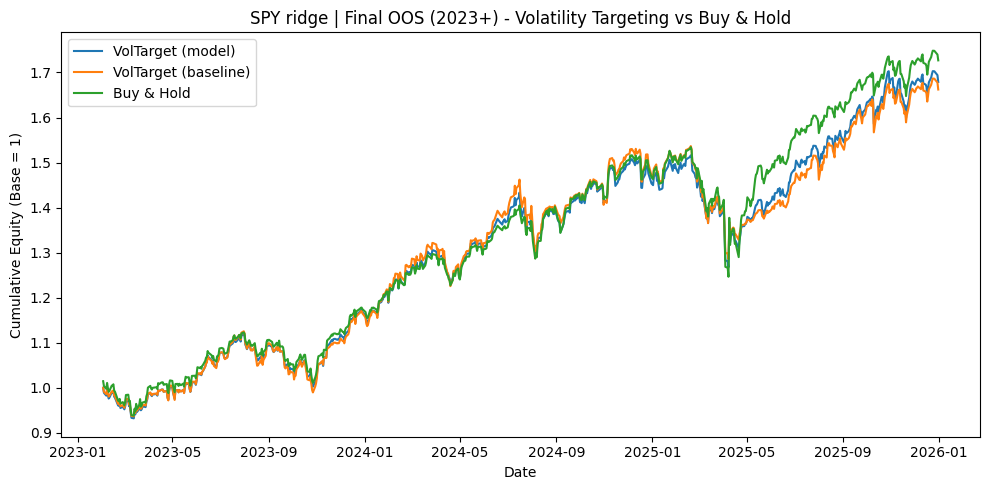

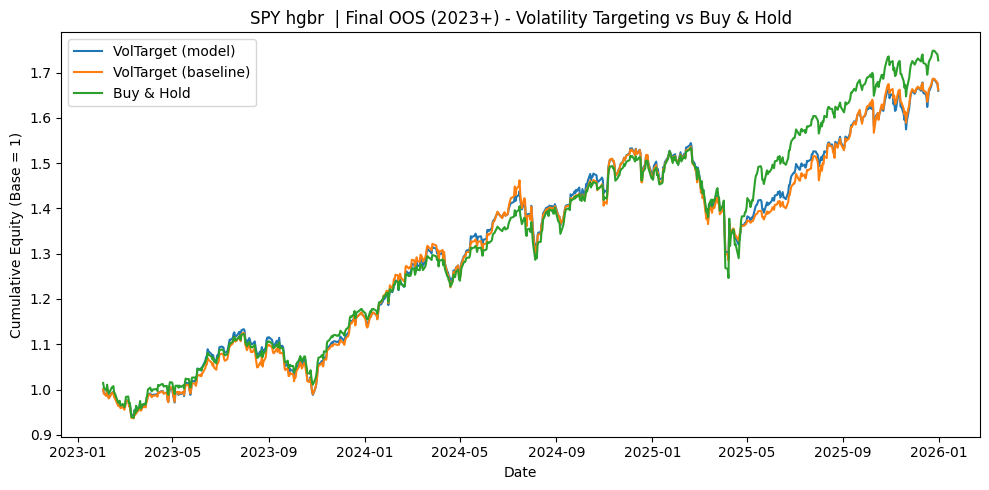

In [95]:
display(SPY_ridge_stabilized["fig_equity"])
display(SPY_hgbr_stabilized["fig_equity"])


## Key Takeaways

- Dynamic exposure strategies produces equity paths very similar to Buy & Hold, but with controlled exposure adjustments.
- Machine learning models slightly improve performance relative to the volatility baseline, with Ridge showing marginally stronger performance during the second half of 2025
- When embedded in the same dynamic exposure strategy, Ridge and HGBR produce very similar equity curves, suggesting that model choice has a relatively small impact on overall strategy performance, although Ridge perform slightly better. 
- During strong bull markets, such as the second half of 2025, Buy & Hold tends to capture slightly more upside.

# SPY – Dynamic Exposure Comparison (Stabilized Allocation)¶

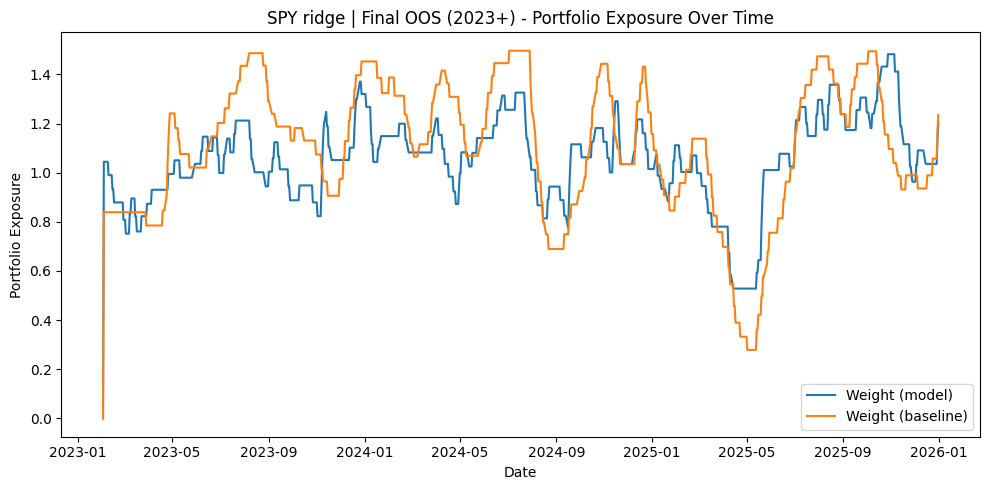

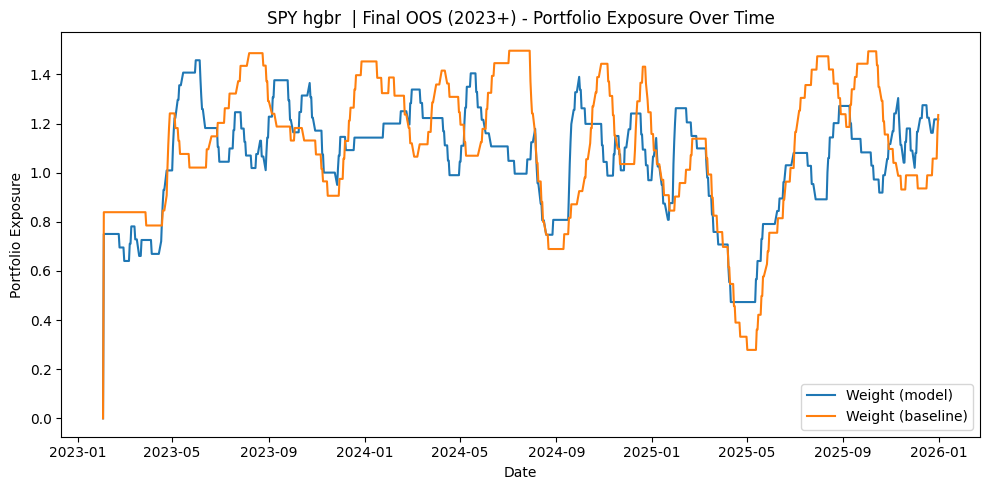

In [96]:
display(SPY_ridge_stabilized["fig_weight"])
display(SPY_hgbr_stabilized["fig_weight"])


## Key Takeaways

- **Both approaches adjust exposure dynamically according to predicted volatility**    
Both the baseline and the machine learning models scale exposure between roughly 0.5 and 1.5, increasing leverage during low-volatility periods and reducing exposure when volatility rises.
This confirms that both implementations follow the same risk-scaling framework.

- **The machine learning models produce smoother exposure paths**   
Compared with the baseline, the model-based exposure tends to vary more gradually, while the baseline often reacts more aggressively to volatility spikes.      
This suggests that the models provide a more stable volatility estimate, resulting in smoother position adjustments.

- **The baseline sometimes reduces exposure more aggressively**   
During certain volatility spikes (e.g., early 2025), the baseline reduces exposure to very low levels, while the models maintain moderately higher exposure.       
This behavior indicates that the baseline volatility estimate reacts more strongly to short-term volatility shocks.

- **Differences between Ridge and HGBR are relatively small**   
The exposure patterns generated by the Ridge and HGBR models are broadly similar, indicating that the overall strategy structure has a larger impact on exposure behavior than the specific model used. However, the Ridge model tends to produce slightly smoother exposure adjustments, while HGBR occasionally shows more pronounced changes in portfolio exposure.


## Backtest Data Structure Example

In [97]:
print("Below we show the first 5 rows of the backtest output.")
display(SPY_ridge_stabilized["bt_model"].head(5))


Below we show the first 5 rows of the backtest output.


,ret,vol_pred,weight,turnover,fee,strat_ret,equity_strat,equity_bh
Date,,,,,,,,
2023-02-02,0.014557,0.008212,0.000000,0.000000,0.000000,0.000000,1.000000,1.014557
2023-02-03,-0.010629,0.008007,1.044344,1.044344,0.000104,-0.011205,0.988795,1.003773
2023-02-06,-0.006111,0.009195,1.044344,0.000000,0.000000,-0.006382,0.982484,0.997639
2023-02-07,0.013079,0.008587,1.044344,0.000000,0.000000,0.013659,0.995903,1.010687
2023-02-08,-0.010935,0.008463,1.044344,0.000000,0.000000,-0.011420,0.984531,0.999635


**Note** The baseline backtest has the same structure but uses historical volatility as forecast. 

If you want to inspect the baseline strategy results, you can access the baseline backtest directly from the model output: SPY_ridge_stabilized["bt_baseline"]

# QQQ – Stabilized Configuration: Out-of-Sample Evaluation (2023+)

In [98]:
QQQ_ridge_stabilized = run_vol_targeting_bt_enhanced(
    res_qqq_ridge, close_qqq, "QQQ ridge | Final OOS (2023+)",    target_ann_vol=None,  improvements=VOL_TARGET_STABILIZED, make_plots=True
)

QQQ_hgbr_stabilized = run_vol_targeting_bt_enhanced(
    res_qqq_hgbr, close_qqq, "QQQ hgbr  | Final OOS (2023+)", target_ann_vol=None, improvements=VOL_TARGET_STABILIZED, make_plots=True
)

## Performance Overview (QQQ, Stabilized Configuration)

In [99]:
perf_compare_QQQ_stabilized = compare_two_models_from_tables(
    QQQ_ridge_stabilized["performance_table"],
    QQQ_hgbr_stabilized["performance_table"],
    label="QQQ | Final OOS (2023+)"
)

print("\n==================== Performance Summary | Final OOS (2023+) ====================")
display(perf_compare_QQQ_stabilized)




==================== Performance Summary | Final OOS (2023+) ====================


,CAGR,AnnVol,Sharpe,MaxDD,AvgDailyTurnover,AvgWeight,WeightP95,WeightP05
QQQ ridge | Final OOS (2023+) (model),0.291526,0.193113,1.325414,-0.208177,0.015081,1.052173,1.318951,0.807633
QQQ hgbr | Final OOS (2023+) (model),0.280459,0.193589,1.277654,-0.211252,0.018517,1.060986,1.367261,0.671316
QQQ | Final OOS (2023+) (baseline),0.305227,0.198251,1.344346,-0.206049,0.013504,1.088819,1.489513,0.654924
Buy & Hold,0.312334,0.198893,1.367338,-0.227683,NaN,NaN,NaN,NaN


In the QQQ out-of-sample period (2023+), the stabilized configuration delivers strong absolute returns but does not outperform the baseline or Buy & Hold in risk-adjusted terms.

* Both Ridge (Sharpe 1.33) and HGBR (Sharpe 1.28) perform competitively, but remain below the baseline (Sharpe 1.34) and Buy & Hold (Sharpe 1.37).
* Volatility is slightly reduced relative to passive exposure (~19.3% vs ~19.9%), but the improvement is modest.
* Maximum drawdowns remain similar across dynamic and baseline strategies (~-21%), while Buy & Hold shows deeper drawdown (-22.8%).
* Turnover remains moderate (~1.5–1.8%), suggesting stable exposure adjustments, though it is slightly higher than the baseline.
* Average exposure remains close to 1 (~1.05–1.09), slightly lower than the baseline, indicating near full market participation.

Overall, in this strong growth-driven regime, passive exposure captures more upside, and the incremental value of model-driven volatility targeting is limited.

## Timing Effect – Dynamic vs Constant Exposure (QQQ, Stabilized Configuration)

In [100]:
timing_compare_QQQ_stabilized = timing_firstrow_a_plus_all_b(
    QQQ_ridge_stabilized["timing_table"],
    QQQ_hgbr_stabilized["timing_table"]
)

print("\n==================== Timing Test | Dynamic vs Constant Weight ====================")
display(timing_compare_QQQ_stabilized)


==================== Timing Test | Dynamic vs Constant Weight ====================


,AvgWeight,Sharpe_Dynamic,Sharpe_ConstantWeight,Sharpe_Improvement,CAGR_Dynamic,CAGR_ConstantWeight
QQQ ridge | Final OOS (2023+) (model),1.052173,1.325414,1.367338,-0.041925,0.291526,0.331066
QQQ hgbr | Final OOS (2023+) (model),1.060986,1.277654,1.367338,-0.089684,0.280459,0.334256
QQQ hgbr | Final OOS (2023+) (baseline),1.088819,1.344346,1.367338,-0.022993,0.305227,0.344383


This timing test evaluates whether dynamic volatility-based exposure adds value relative to holding a constant weight equal to the strategy’s average exposure.

* Both Ridge and HGBR show **negative Sharpe improvement** (-0.04 and -0.09 respectively), indicating that dynamic adjustments reduce risk-adjusted performance relative to constant exposure.
* The baseline also exhibits negative timing value.
* CAGR is consistently higher under constant exposure across all variants.

These results suggest that, during the strong 2023+ tech-driven rally, maintaining steady exposure was more effective than dynamically adjusting risk.

# QQQ – Equity Curve Comparison (Stabilized Dynamic Exposure Strategy)

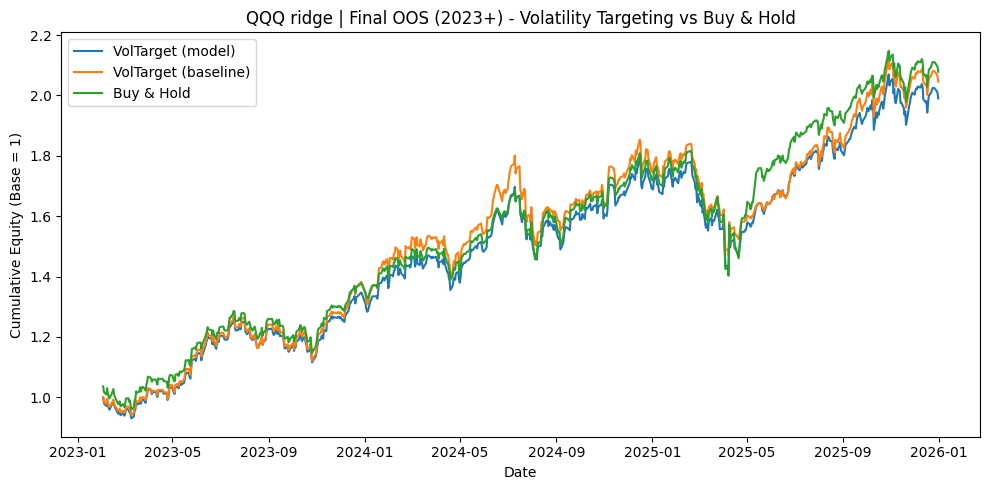

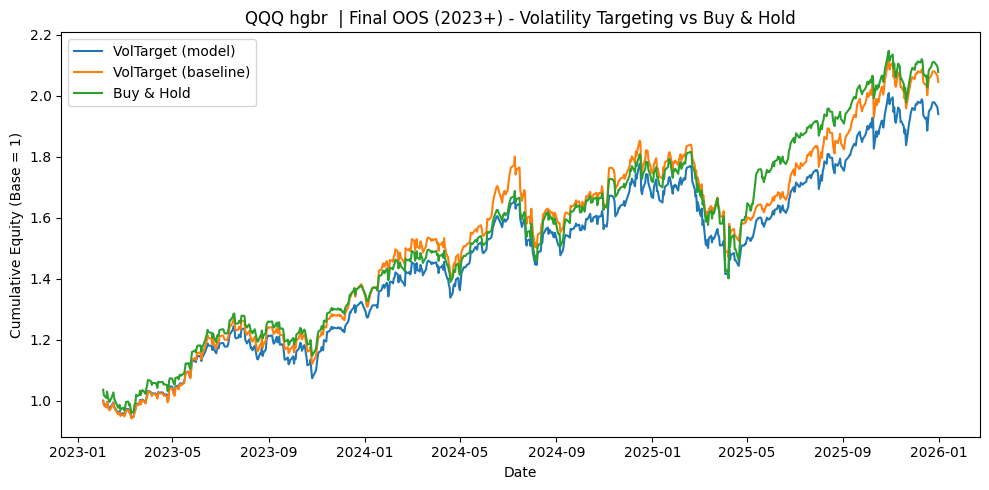

In [101]:
display(QQQ_ridge_stabilized["fig_equity"])
display(QQQ_hgbr_stabilized["fig_equity"])


## Key Takeaways

* Buy & Hold ends the period with the highest cumulative equity, indicating that constant full exposure captured the most upside overall. However, during 2024 the baseline strategy generally exceeded the Buy & Hold equity level, suggesting that the dynamic exposure approach can temporarily outperform in certain market phases.

* The model and baseline equity curves remain very close throughout the period, although the baseline strategy tends to perform slightly better than Ridge and HGBR during most of the out-of-sample period. 

* The Ridge model curve remains closer to the baseline and Buy & Hold, while the HGBR curve falls further below them, particularly toward the end of the period. This indicates that, under the same dynamic exposure strategy, Ridge slightly outperforms HGBR during this period.

* When embedded in the same dynamic exposure strategy, Ridge and HGBR generate broadly similar equity paths, though the differences observed suggest that model choice still has a modest impact on overall strategy performance.


# QQQ – Dynamic Exposure Comparison (Stabilized Allocation)

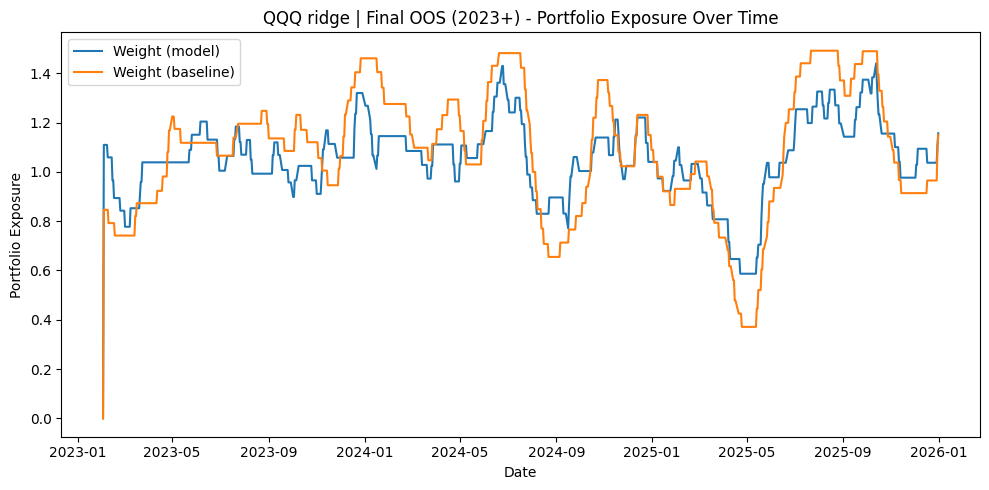

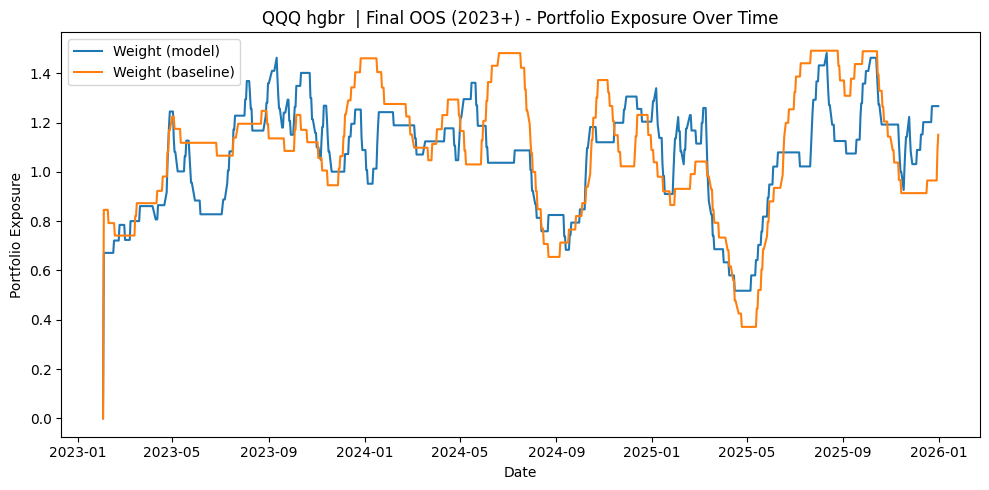

In [102]:
display(QQQ_ridge_stabilized["fig_weight"])
display(QQQ_hgbr_stabilized["fig_weight"])


- **Both approaches follow the same dynamic exposure framework**   
Both the baseline and the machine learning models dynamically adjust portfolio exposure based on estimated volatility. Exposure generally fluctuates between ~0.6 and ~1.5, increasing during lower-volatility periods and decreasing when volatility rises.   
This confirms that both approaches operate under the same risk-scaling mechanism, with the model only influencing the volatility estimate used to determine portfolio weights.

- **Model-based exposure adjustments are generally smoother**   
Compared with the baseline, the model-driven exposure tends to evolve more gradually, while the baseline allocation often reacts more sharply to short-term volatility changes.   
This suggests that the machine learning models produce more stable volatility estimates, leading to smoother exposure adjustments over time.

- **The baseline reacts more aggressively to volatility spikes**   
During periods of elevated volatility (for example around late-2024 and early-2025), the baseline reduces exposure more aggressively than the models.   
In contrast, the models tend to maintain moderately higher exposure levels, indicating that they filter some short-term volatility fluctuations rather than reacting immediately to them.

- **Ridge produces slightly smoother exposure than HGBR**   
While both models generate broadly similar exposure patterns, the Ridge model tends to produce more stable and gradual exposure changes, whereas HGBR occasionally shows slightly larger short-term fluctuations.   
However, the differences between the two models remain relatively small, with both producing broadly similar exposure paths over time.

# SPY – Regime-Aware Configuration: Out-of-Sample Evaluation (2023+)

In [103]:
SPY_ridge_regime_cap = run_vol_targeting_bt_enhanced(
    res_spy_ridge, close_spy, "SPY ridge | Final OOS (2023+)", target_ann_vol=None,  improvements=VOL_TARGET_REGIME_CAP, make_plots=True
)

SPY_hgbr_regime_cap = run_vol_targeting_bt_enhanced(
    res_spy_hgbr, close_spy, "SPY hgbr  | Final OOS (2023+)", target_ann_vol=None, improvements=VOL_TARGET_REGIME_CAP, make_plots=True
)

## Performance Overview (SPY, Regime-Aware Configuration)

In [104]:
perf_compare_SPY_regime_cap = compare_two_models_from_tables(
    SPY_ridge_regime_cap["performance_table"],
    SPY_hgbr_regime_cap["performance_table"],
    label="SPY | Final OOS (2023+)"
)

print("\n==================== Performance Summary | Final OOS (2023+) ====================")
display(perf_compare_SPY_regime_cap)


==================== Performance Summary | Final OOS (2023+) ====================


,CAGR,AnnVol,Sharpe,MaxDD,AvgDailyTurnover,AvgWeight,WeightP95,WeightP05
SPY ridge | Final OOS (2023+) (model),0.161765,0.114446,1.310533,-0.140349,0.012722,0.824951,1.196871,0.5
SPY hgbr | Final OOS (2023+) (model),0.183486,0.124560,1.352925,-0.159074,0.013429,0.903692,1.291237,0.5
SPY | Final OOS (2023+) (baseline),0.184413,0.132313,1.279575,-0.156690,0.013266,0.930376,1.464554,0.5
Buy & Hold,0.221349,0.153080,1.306740,-0.187552,NaN,NaN,NaN,NaN


The regime-aware configuration further reduces portfolio risk through exposure caps during weaker market conditions.

- Volatility is significantly lower than in the stabilized setup (≈11–12%).
- Maximum drawdown improves for Ridge (-14.0%) and remains controlled for HGBR (-15.9%).
- HGBR achieves the highest Sharpe (1.35), outperforming both the baseline (1.28) and Buy & Hold (1.31).
- Average exposure is lower (~0.82–0.90), reflecting the defensive regime filter.
- Turnover remains moderate (~1.3%) and broadly comparable to the baseline, indicating that the regime-aware adjustments do not materially increase trading activity.

Returns are lower than Buy & Hold in this strong market period, consistent with the more defensive positioning.

## Timing Effect – Dynamic vs Constant Exposure (Regime-Aware Configuration)

In [105]:

timing_compare_SPY_regime_cap = timing_firstrow_a_plus_all_b(
    SPY_ridge_regime_cap["timing_table"],
    SPY_hgbr_regime_cap["timing_table"]
)

print("\n==================== Timing Test | Dynamic vs Constant Weight ====================")
display(timing_compare_SPY_regime_cap)


==================== Timing Test | Dynamic vs Constant Weight ====================


,AvgWeight,Sharpe_Dynamic,Sharpe_ConstantWeight,Sharpe_Improvement,CAGR_Dynamic,CAGR_ConstantWeight
SPY ridge | Final OOS (2023+) (model),0.824951,1.310533,1.30674,0.003793,0.161765,0.179352
SPY hgbr | Final OOS (2023+) (model),0.903692,1.352925,1.30674,0.046185,0.183486,0.198062
SPY hgbr | Final OOS (2023+) (baseline),0.930376,1.279575,1.30674,-0.027165,0.184413,0.204470


This timing test isolates whether dynamic exposure adjustments add value relative to holding a constant weight equal to the strategy’s average exposure.

* **HGBR (model)** shows a clear timing benefit, improving Sharpe from ~1.31 (constant weight) to 1.35 (dynamic), with a positive Sharpe improvement of +0.046.
* **Ridge (model)** delivers only marginal timing value (+0.004 Sharpe), indicating that most of its performance comes from stable exposure rather than timing skill.
* The **baseline** shows negative timing improvement, meaning dynamic adjustments do not improve risk-adjusted performance relative to constant exposure.

CAGR comparisons highlight the defensive nature of the regime-aware setup: by reducing exposure during parts of the rally, dynamic allocation captures less upside than maintaining constant exposure.

# SPY – Equity Curve Comparison (Regime-Aware Dynamic Exposure Strategy)

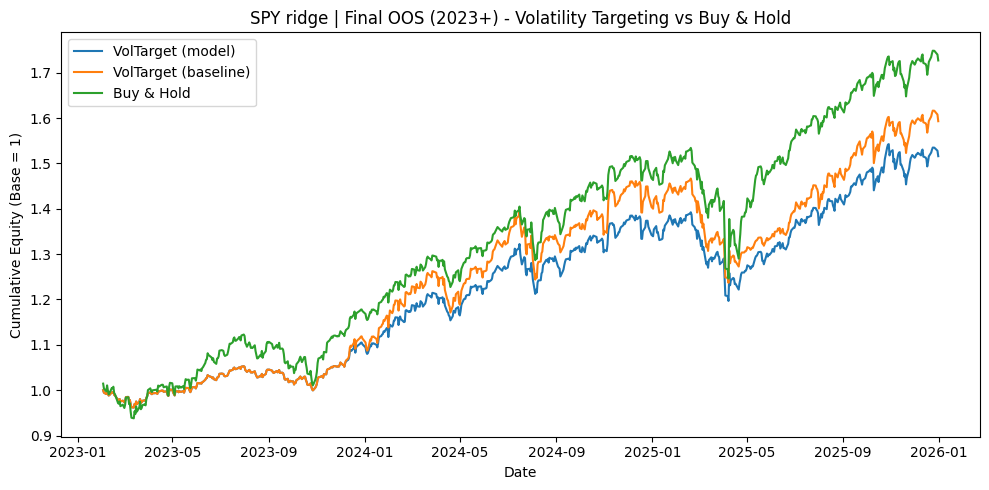

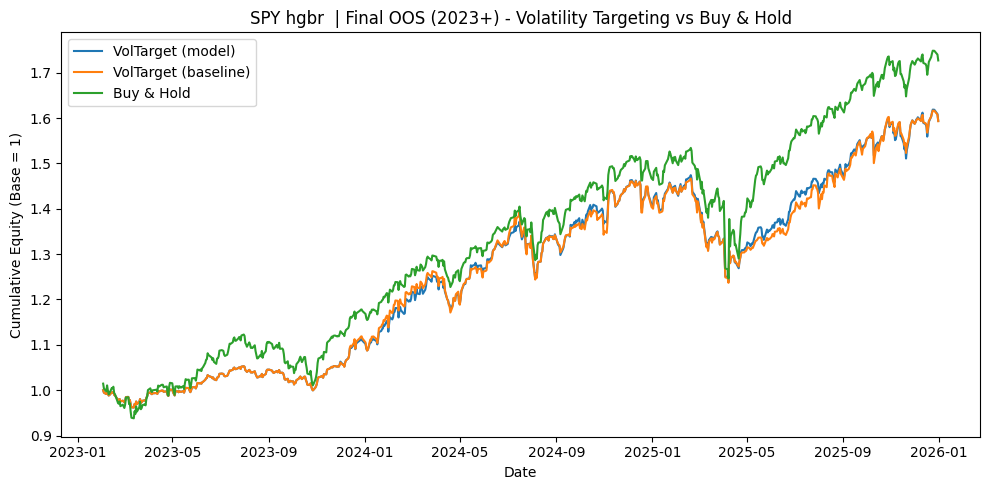

In [106]:
display(SPY_ridge_regime_cap["fig_equity"])
display(SPY_hgbr_regime_cap["fig_equity"])


## Key Takeaways

- Buy & Hold achieves the highest cumulative return over the full out-of-sample period. Because it maintains constant full market exposure, it captures more upside during sustained market rallies.
- The dynamic exposure strategies consistently remain below Buy & Hold, as the regime-aware configuration occasionally reduces portfolio exposure. This defensive mechanism helps limit risk but also reduces participation during strong upward trends.
- The volatility baseline remains closer to Buy & Hold during most of the period and generally outperforms the Ridge model, while HGBR performs very similarly to the baseline. This suggests that the predictive models do not provide meaningful improvements and may slightly worsen results under the regime-aware configuration for SPY.
- Differences between Ridge and HGBR are noticeable in this configuration. The HGBR model stays closer to the baseline strategy, while Ridge underperforms more clearly.

# SPY – Dynamic Exposure Comparison (Regime-Aware Allocation)

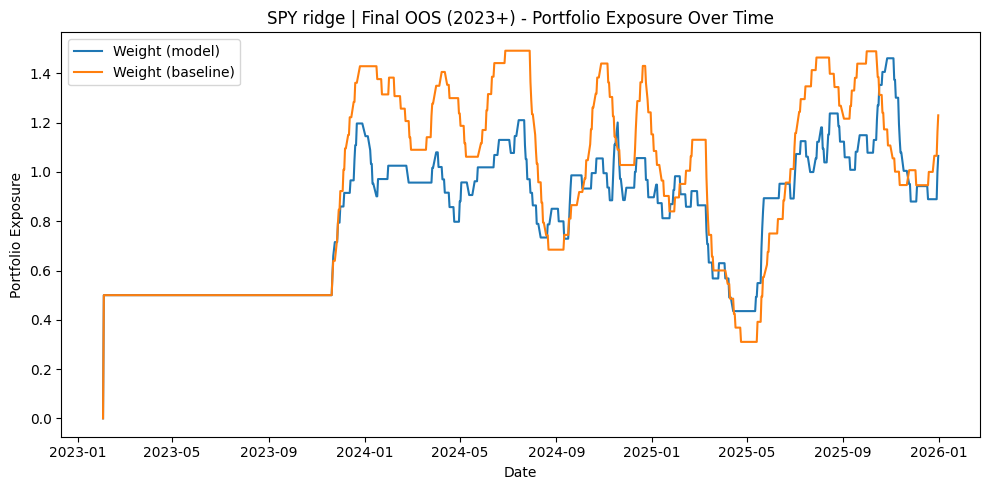

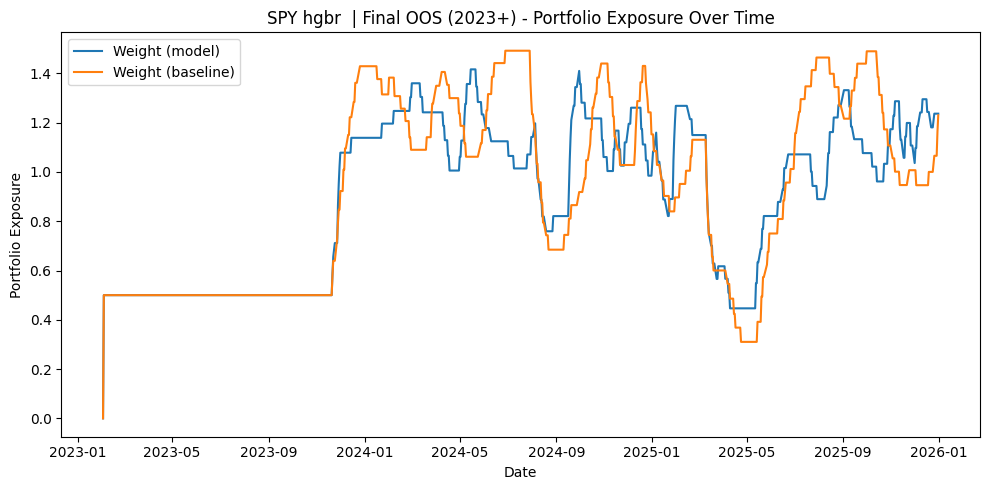

In [107]:
display(SPY_ridge_regime_cap["fig_weight"])
display(SPY_hgbr_regime_cap["fig_weight"])


- **Both approaches follow the same risk-scaling framework**      
Both the baseline and the machine learning models dynamically adjust exposure based on predicted volatility.     
Exposure typically fluctuates between ~0.5 and ~1.5, increasing during lower volatility periods and decreasing when volatility rises.      
This suggests that both approaches rely on the same dynamic allocation mechanism, with differences primarily driven by how volatility is estimated.

- **The baseline reacts more aggressively to volatility spikes**      
The baseline exposure often shows sharper changes, particularly during volatility spikes.     
For example, around early 2025, the baseline reduces exposure to very low levels before quickly increasing it again.     
This behaviour reflects the high sensitivity of traditional volatility estimates to short-term market shocks.

- **Model-based exposure adjustments are smoother**    
Both Ridge and HGBR produce more gradual exposure adjustments, avoiding some of the abrupt changes seen in the baseline.    
This indicates that the predictive models generate more stable volatility estimates, filtering some short-term noise in the volatility signal.

- **Differences between Ridge and HGBR are relatively small**    
The exposure paths generated by Ridge and HGBR are broadly similar across the period.
Although small deviations appear at certain points, both models produce comparable exposure dynamics when embedded in the same allocation framework.   
This suggests that model choice has only a limited impact on the overall exposure pattern. However, the Ridge model tends to produce smoother and more gradual exposure adjustments, while HGBR sometimes exhibits slightly larger short-term fluctuations.

# QQQ – Regime-Aware Configuration: Out-of-Sample Evaluation (2023+)

In [108]:
QQQ_ridge_regime_cap = run_vol_targeting_bt_enhanced(
    res_qqq_ridge, close_qqq, "QQQ ridge | Final OOS (2023+)",    target_ann_vol=None,  improvements=VOL_TARGET_REGIME_CAP, make_plots=True
)

QQQ_hgbr_regime_cap = run_vol_targeting_bt_enhanced(
    res_qqq_hgbr, close_qqq, "QQQ hgbr  | Final OOS (2023+)", target_ann_vol=None, improvements=VOL_TARGET_REGIME_CAP, make_plots=True
)

## Performance Overview (QQQ, Regime-Aware Configuration)

In [109]:
perf_compare_QQQ_regime_cap = compare_two_models_from_tables(
    QQQ_ridge_regime_cap["performance_table"],
    QQQ_hgbr_regime_cap["performance_table"],
    label="QQQ | Final OOS (2023+)"
)


print("\n==================== Performance Summary | Final OOS (2023+) ====================")
display(perf_compare_QQQ_regime_cap)



==================== Performance Summary | Final OOS (2023+) ====================


,CAGR,AnnVol,Sharpe,MaxDD,AvgDailyTurnover,AvgWeight,WeightP95,WeightP05
QQQ ridge | Final OOS (2023+) (model),0.214963,0.153164,1.271764,-0.170401,0.010193,0.819052,1.167552,0.5
QQQ hgbr | Final OOS (2023+) (model),0.235726,0.169003,1.252921,-0.191828,0.013620,0.895823,1.288024,0.5
QQQ | Final OOS (2023+) (baseline),0.248078,0.172988,1.281604,-0.182042,0.011384,0.921180,1.482210,0.5
Buy & Hold,0.312334,0.198893,1.367338,-0.227683,NaN,NaN,NaN,NaN


The regime-aware configuration materially reduces volatility and drawdowns by lowering average exposure. However, in the strong 2023+ bull market, this defensive positioning limits upside participation, resulting in lower returns and weaker Sharpe ratios relative to both the baseline and Buy & Hold.

- Volatility declines meaningfully (~15–17% vs ~19.9% for Buy & Hold).
- Turnover remains relatively low (~1–1.4%) and broadly comparable to the baseline, with Ridge showing slightly lower trading intensity.
- Average exposure is lower (~0.82–0.90), reflecting the defensive regime cap.
- Drawdowns improve relative to Buy & Hold, particularly for Ridge (-17.0% vs -22.8%).
- However, Sharpe ratios remain below both the baseline and passive exposure.
- CAGR is substantially lower than Buy & Hold, consistent with reduced participation during a strong upward trend.

Overall, the regime filter successfully reduces risk but limits upside capture in a sustained bull market environment.

## Timing Effect – Dynamic vs Constant Exposure (QQQ, Regime-Aware Configuration)

In [110]:

timing_compare_QQQ_regime_cap = timing_firstrow_a_plus_all_b(
    QQQ_ridge_regime_cap["timing_table"],
    QQQ_hgbr_regime_cap["timing_table"]
)

print("\n==================== Timing Test | Dynamic vs Constant Weight ====================")
display(timing_compare_QQQ_regime_cap)


==================== Timing Test | Dynamic vs Constant Weight ====================


,AvgWeight,Sharpe_Dynamic,Sharpe_ConstantWeight,Sharpe_Improvement,CAGR_Dynamic,CAGR_ConstantWeight
QQQ ridge | Final OOS (2023+) (model),0.819052,1.271764,1.367338,-0.095574,0.214963,0.249378
QQQ hgbr | Final OOS (2023+) (model),0.895823,1.252921,1.367338,-0.114417,0.235726,0.275712
QQQ hgbr | Final OOS (2023+) (baseline),0.921180,1.281604,1.367338,-0.085735,0.248078,0.284532


This timing test evaluates whether regime-based dynamic exposure improves performance relative to maintaining a constant exposure equal to the strategy’s average weight.

- Both Ridge and HGBR show **negative Sharpe improvement** (-0.095 and -0.114 respectively), indicating that dynamic adjustments reduce risk-adjusted performance relative to constant exposure.
- The baseline also exhibits negative timing value, although the Sharpe deterioration is smaller than for Ridge and HGBR.
- CAGR is consistently higher under constant exposure across all models.

These results suggest that in the strong 2023+ tech rally, maintaining steady exposure was more effective than dynamically reducing risk via the regime filter.

# QQQ – Equity Curve Comparison (Regime-Aware Dynamic Exposure Strategy)

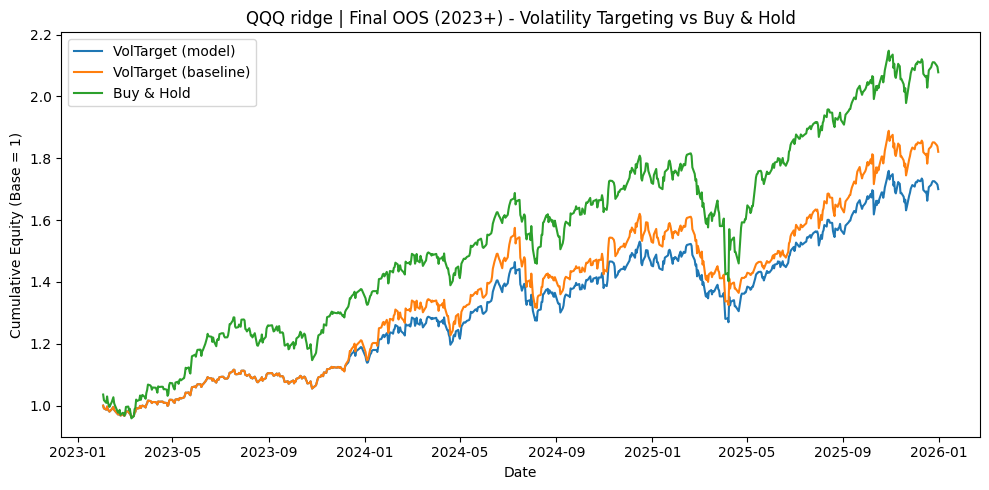

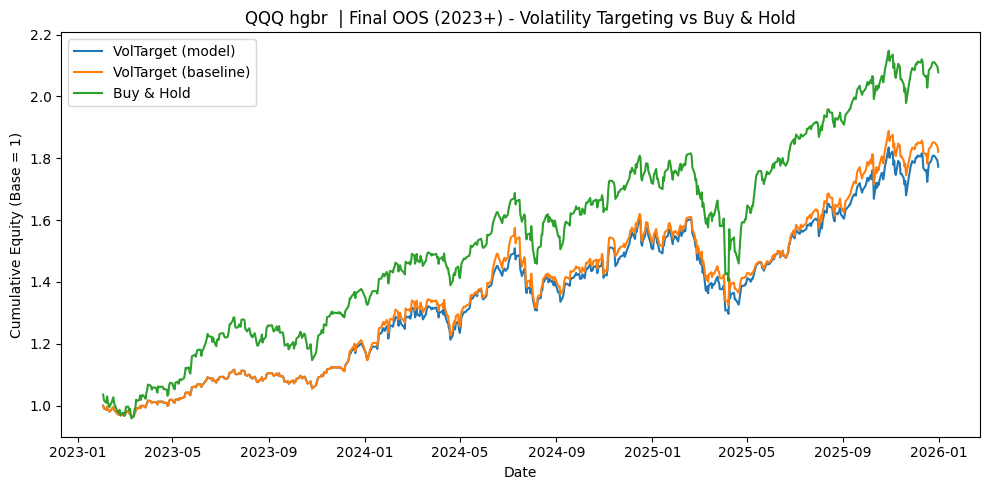

In [111]:
display(QQQ_ridge_regime_cap["fig_equity"])
display(QQQ_hgbr_regime_cap["fig_equity"])


## Key Takeaways

- Buy & Hold clearly achieves the highest cumulative return over the full out-of-sample period. Because it maintains constant market exposure, it captures more upside during the strong upward trend in QQQ.
- Dynamic exposure strategies remain consistently below Buy & Hold, since the regime-aware configuration periodically reduces portfolio exposure. This defensive mechanism limits risk but also reduces participation in strong rallies.
- The volatility baseline generally performs better than the ML models, staying closer to Buy & Hold for most of the sample. This suggests that the predictive models do not provide meaningful improvements and may slightly worsen results under the regime-aware configuration for QQQ.
- HGBR performs slightly better than Ridge, as its equity curve remains closer to the baseline throughout most of the period. This suggests that model choice has some impact, although the differences between models remain smaller than the overall gap between the dynamic strategies and Buy & Hold.


# QQQ – Dynamic Exposure Comparison (Regime-Aware Allocation)

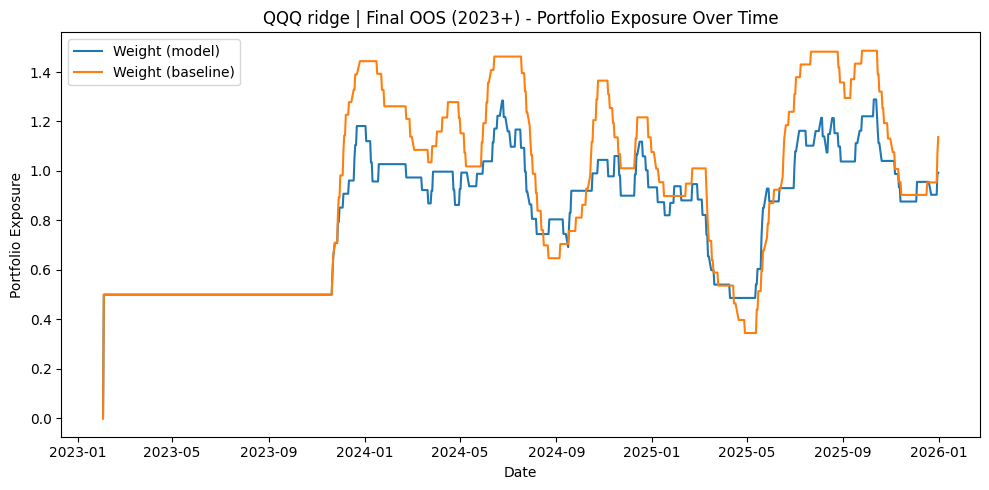

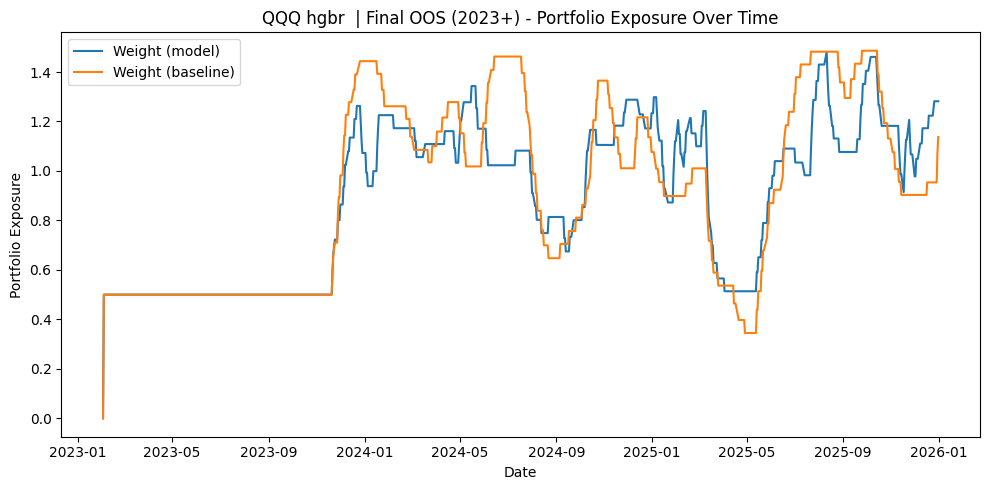

In [112]:
display(QQQ_ridge_regime_cap["fig_weight"])
display(QQQ_hgbr_regime_cap["fig_weight"])


- **Exposure patterns remain broadly similar across all approaches**   
Both Ridge and HGBR follow exposure paths that are broadly aligned with the baseline strategy.     
The major exposure changes — such as the reduction during the volatility spike around 2025 — occur at roughly the same time across all methods.      
This indicates that the core allocation framework drives most of the exposure dynamics, while the predictive models mainly introduce smaller adjustments around that baseline.

- **The baseline tends to take more aggressive exposure levels**    
Across many periods (particularly during 2024 and late 2025), the baseline reaches higher exposure peaks, often approaching the upper allocation limit.     
In contrast, both machine learning models typically maintain slightly lower and more moderate exposure levels, suggesting a more conservative allocation behaviour.

- **Ridge produces smoother and more stable exposure adjustments**    
The Ridge model generally adjusts exposure in a more gradual and stable way, with smaller short-term fluctuations around the baseline allocation.     
This behaviour results in a smoother exposure trajectory compared with both the baseline and HGBR, which can help reduce unnecessary trading and noise-driven adjustments.

- **HGBR reacts more aggressively to short-term changes**   
Compared with Ridge, the HGBR model exhibits more frequent short-term fluctuations in exposure.     
While the general exposure pattern remains similar to the baseline, HGBR introduces larger local variations, indicating a more reactive response to changes in predicted volatility.

---
# SPY – Consolidated Out-of-Sample Comparison (2023+)

In [113]:
perf_SPY_unified = unify_perf_tables_with_buyhold(
    perf_compare_SPY_stabilized,
    perf_compare_SPY_regime_cap,
    label_stab="Volatility Targeting – Stabilized",
    label_regime="Volatility Targeting – Regime Aware"
)

display(perf_SPY_unified)

,Framework,CAGR,AnnVol,Sharpe,MaxDD,AvgDailyTurnover,AvgWeight,WeightP95,WeightP05
SPY ridge | Final OOS (2023+) (model),Volatility Targeting – Stabilized,0.207876,0.143273,1.318702,-0.163947,0.017735,1.052758,1.322888,0.767401
SPY hgbr | Final OOS (2023+) (model),Volatility Targeting – Stabilized,0.202831,0.141408,1.306477,-0.164510,0.018032,1.058503,1.355652,0.660909
SPY ridge | Final OOS (2023+) (model),Volatility Targeting – Regime Aware,0.161765,0.114446,1.310533,-0.140349,0.012722,0.824951,1.196871,0.500000
SPY hgbr | Final OOS (2023+) (model),Volatility Targeting – Regime Aware,0.183486,0.124560,1.352925,-0.159074,0.013429,0.903692,1.291237,0.500000
Buy & Hold,Buy & Hold,0.221349,0.153080,1.306740,-0.187552,NaN,NaN,NaN,NaN


### 1) Risk-Adjusted Performance (Sharpe)
- The highest Sharpe is achieved by **HGBR under the Regime-Aware framework** (1.35).
- Stabilized Ridge also delivers strong risk-adjusted performance.
- Both frameworks outperform or match Buy & Hold in risk-adjusted terms.

### 2) Absolute Returns (CAGR)
- Buy & Hold delivers the highest raw return.
- The Stabilized framework preserves most of the upside.
- The Regime-Aware setup sacrifices more return due to defensive positioning.   
**Trade-off**: Regime filtering improves risk metrics but sacrifices CAGR in bull markets.

### 3) Risk (Volatility & Drawdown)
- Both frameworks reduce volatility relative to Buy & Hold.
- The Regime-Aware configuration delivers the strongest risk reduction, in terms of volatility and drawdowns. ---
- Stabilized provides a middle ground.
- Ridge-Regime achieves the lowest drawdown (-14.0%), while Buy & Hold carries the highest drawdown. ----
  
### 4) Exposure Behavior  
### Average Exposure (AvgWeight)  
- Stabilized:~1.05 (near full participation)  
- Regime-Aware: ~0.82–0.90 (defensive positioning)      
The regime-aware setup maintains lower average exposure (market participation), confirming its defensive nature.   
### Turnover  
- Stabilized: ~1.7–1.8%    
- Regime-Aware: ~1.2–1.3%           
The regime-aware framework reduces trading intensity relative to the stabilized setup, and smooths adjustments.


## Overall Conclusions
---

### 1) Does ML Add Value?

Yes.
Both Ridge and HGBR outperform Buy & Hold in Sharpe under at least one configuration.

### 2) Ridge or HGBR?

- Differences between Ridge and HGBR are relatively small in terms of Sharpe and CAGR.
- HGBR performs slightly better under the Regime-Aware configuration.
- Ridge performs slightly better under Stabilized.
  
### 3) Which Dynamic Strategy Works Best? Stabilized or Regime?

- If prioritizing **Sharpe** → HGBR (Regime-Aware).
- If prioritizing **CAGR** → Ridge (Stabilized), preserves upside better.
- If prioritizing **risk reduction** → Regime-Aware, because reduces volatility and drawdowns more aggressively.

### 4) What Is the Core Trade-Off?

Regime filtering lowers volatility and drawdowns but reduces participation in strong bull markets. In contrast, the Buy & Hold strategy maximizes returns in strong bull markets.

### 5) Are Strategies Operationally Reasonable?

Yes.
Turnover remains moderate (1–1.8%), indicating controlled trading intensity.

# QQQ – Consolidated Out-of-Sample Comparison (2023+)

In [114]:
perf_QQQ_unified = unify_perf_tables_with_buyhold(
    perf_compare_QQQ_stabilized,
    perf_compare_QQQ_regime_cap,
    label_stab="Volatility Targeting – Stabilized",
    label_regime="Volatility Targeting – Regime Aware"
)

display(perf_QQQ_unified)

,Framework,CAGR,AnnVol,Sharpe,MaxDD,AvgDailyTurnover,AvgWeight,WeightP95,WeightP05
QQQ ridge | Final OOS (2023+) (model),Volatility Targeting – Stabilized,0.291526,0.193113,1.325414,-0.208177,0.015081,1.052173,1.318951,0.807633
QQQ hgbr | Final OOS (2023+) (model),Volatility Targeting – Stabilized,0.280459,0.193589,1.277654,-0.211252,0.018517,1.060986,1.367261,0.671316
QQQ ridge | Final OOS (2023+) (model),Volatility Targeting – Regime Aware,0.214963,0.153164,1.271764,-0.170401,0.010193,0.819052,1.167552,0.500000
QQQ hgbr | Final OOS (2023+) (model),Volatility Targeting – Regime Aware,0.235726,0.169003,1.252921,-0.191828,0.013620,0.895823,1.288024,0.500000
Buy & Hold,Buy & Hold,0.312334,0.198893,1.367338,-0.227683,NaN,NaN,NaN,NaN


### 1) Risk-Adjusted Performance (Sharpe)

* **Buy & Hold achieves the highest Sharpe ratio**, reflecting the strong momentum-driven rally in QQQ during 2023+.
* The **Stabilized Ridge model** performs best among the dynamic strategies.
* Regime-aware variants show slightly lower Sharpe due to reduced market participation.

### 2) Absolute Returns (CAGR)

* **Buy & Hold captures the most upside** in the strong tech rally.
* Stabilized strategies retain most of the upside while controlling risk slightly.
* Regime-Aware strategies significantly reduce CAGR due to defensive positioning.    
**Trade-off:** Regime filtering sacrifices return in strong bull markets.    

### 3) Risk (Volatility and Drawdowns)

* Regime-aware strategies **materially reduce volatility and drawdowns**.
* Buy & Hold carries the highest downside risk.
* Stabilized strategies offer limited volatility reduction relative to passive exposure.

### 4) Exposure Behavior  

### Average Exposure

* Stabilized: **~1.05–1.06**
* Regime-Aware: **~0.82–0.90**

The regime filter lowers average exposure, leading to more defensive positioning.

### Turnover

* Stabilized: **~1.5–1.8%**
* Regime-Aware: **~1.0–1.4%**

Regime filtering also reduces trading activity, indicating smoother adjustments.


## Overall Conclusions

### 1) Does ML Add Value?

Not significantly in this case.
The baseline Buy & Hold strategy achieves the highest Sharpe and CAGR.

### 2) Ridge or HGBR?

- Performance differences between Ridge and HGBR are relatively small across configurations.
- Ridge slightly outperforms HGBR in both the Stabilized and Regime-Aware frameworks.
- This suggests that the strategy framework has a larger impact on performance than the specific prediction model.

### 3) Which Dynamic Strategy Works Best? Stabilized or Regime?

The **Stabilized Ridge model** delivers the strongest performance among dynamic strategies.
- If prioritizing **Sharpe** → Ridge (Stabilized), delivering the strongest risk-adjusted performance among dynamic strategies.
- If prioritizing **CAGR** → Ridge (Stabilized), as it preserves more upside participation in the strong QQQ rally.
- If prioritizing **risk reduction** → Regime-Aware, since it reduces volatility and drawdowns more aggressively.

### 4) What Is the Core Trade-Off?

* **Stabilized:** better upside participation
* **Regime-Aware:** better downside protection

### 5) Are Strategies Operationally Reasonable?

Yes.
Turnover remains moderate (≈1–1.8%), indicating controlled trading activity.

# Timing Effect of Dynamic Exposure – SPY (Stabilized vs Regime-Aware)

In [115]:
timing_SPY_unified = unify_timing_tables(
    timing_compare_SPY_stabilized,
    timing_compare_SPY_regime_cap,
    label_stab="Volatility Targeting – Stabilized",
    label_regime="Volatility Targeting – Regime Aware"
)

display(timing_SPY_unified)

,Framework,AvgWeight,Sharpe_Dynamic,Sharpe_ConstantWeight,Sharpe_Improvement,CAGR_Dynamic,CAGR_ConstantWeight
SPY ridge | Final OOS (2023+) (model),Volatility Targeting – Stabilized,1.052758,1.318702,1.30674,0.011962,0.207876,0.234296
SPY hgbr | Final OOS (2023+) (model),Volatility Targeting – Stabilized,1.058503,1.306477,1.30674,-0.000263,0.202831,0.235714
SPY ridge | Final OOS (2023+) (model),Volatility Targeting – Regime Aware,0.824951,1.310533,1.30674,0.003793,0.161765,0.179352
SPY hgbr | Final OOS (2023+) (model),Volatility Targeting – Regime Aware,0.903692,1.352925,1.30674,0.046185,0.183486,0.198062


### 1) Timing Value (Sharpe Improvement)

* The **HGBR Regime-Aware model shows the strongest timing value**, improving Sharpe by ~0.05 relative to constant exposure.
* **Ridge Stabilized provides a small positive timing contribution.**
* **HGBR Stabilized shows almost no timing benefit**, indicating that its performance mainly comes from exposure level rather than timing.

**Conclusion:** Dynamic exposure adjustments provide modest but measurable benefits, particularly under the **Regime-Aware HGBR configuration**.

### 2) Exposure Levels

* Stabilized strategies maintain **near full market exposure on average**.
* Regime-Aware strategies maintain lower average exposure (~0.82–0.90) than Stabilized configurations (~1.05), indicating a more conservative positioning on average.   
This explains why **CAGR is lower in the Regime-Aware setup**, despite improvements in risk metrics.

### 3) CAGR Comparison (Dynamic vs Constant)

Across all strategies:

* **Constant exposure produces higher CAGR** than dynamic exposure.
* Dynamic strategies sacrifice some return in exchange for improved **risk-adjusted performance and drawdown control**.

This is expected in strong bull markets where **reducing exposure can limit upside participation**.


## Key Takeaways

* Timing improvements exist but are **moderate rather than dramatic**.
* The **Regime-Aware HGBR configuration extracts the most value from timing adjustments**.
* Stabilized configurations mainly improve **risk stability**, not timing performance.
* Constant exposure captures more upside in strong market conditions.

# Timing Effect of Dynamic Exposure – QQQ (Stabilized vs Regime-Aware)

In [116]:
timing_QQQ_unified = unify_timing_tables(
    timing_compare_QQQ_stabilized,
    timing_compare_QQQ_regime_cap,
    label_stab="Volatility Targeting – Stabilized",
    label_regime="Volatility Targeting – Regime Aware"
)

display(timing_QQQ_unified)

,Framework,AvgWeight,Sharpe_Dynamic,Sharpe_ConstantWeight,Sharpe_Improvement,CAGR_Dynamic,CAGR_ConstantWeight
QQQ ridge | Final OOS (2023+) (model),Volatility Targeting – Stabilized,1.052173,1.325414,1.367338,-0.041925,0.291526,0.331066
QQQ hgbr | Final OOS (2023+) (model),Volatility Targeting – Stabilized,1.060986,1.277654,1.367338,-0.089684,0.280459,0.334256
QQQ ridge | Final OOS (2023+) (model),Volatility Targeting – Regime Aware,0.819052,1.271764,1.367338,-0.095574,0.214963,0.249378
QQQ hgbr | Final OOS (2023+) (model),Volatility Targeting – Regime Aware,0.895823,1.252921,1.367338,-0.114417,0.235726,0.275712


### 1) Timing Value (Sharpe Improvement)

* Timing contributions are **negative across all strategies**, particularly for regime-aware frameworks.
* For QQQ, maintaining a **constant exposure equal to the average weight** would have produced higher Sharpe ratios than dynamically adjusting exposure, with the best dynamic results coming from Ridge under the Stabilized configuration.


### 2) Exposure Levels

* Stabilized strategies maintain **near full market exposure** on average.
* Regime-Aware strategies maintain **lower average exposure**, reflecting a more conservative allocation.

Lower exposure explains part of the performance gap in a strongly rising market.

### 3) CAGR Comparison (Dynamic vs Constant)

Across all strategies:

* **Constant exposure delivers higher CAGR** than dynamic exposure.
* The difference in dynamic exposure is particularly large for the **Regime-Aware strategies**, where lower exposure limits participation in the rally.
* CAGR constant weight is similar the difference 

Dynamic exposure reduces returns in strong bull markets.

## Key Takeaways

* Timing contributions are **negative across all configurations**.
* Constant exposure would have produced **higher Sharpe and higher CAGR**.
* The performance gap is larger for **Regime-Aware strategies**, due to lower average exposure.
* Differences between Ridge and HGBR are **secondary relative to the framework choice**.





---

# Final Conclusions & Research Insights

This research evaluates whether machine learning models can improve short-term volatility forecasting and whether these improvements translate into more effective volatility-based exposure adjustments. The analysis combines feature engineering, predictive modeling, cross-asset validation, and portfolio backtesting across SPY and QQQ.

The main insights can be summarized in six key areas.

# 1. Key Empirical Findings (Predictive Signals)

The empirical analysis reveals a **simple but highly robust predictive structure for short-term volatility forecasting**.

Across all assets and models, the dominant signal is **volatility persistence**. Past realized volatility consistently emerges as the most important predictor, confirming that volatility regimes exhibit strong short-term autocorrelation.

Momentum indicators provide **secondary predictive value**, particularly short-term momentum (1-week), while nonlinear models occasionally extract additional information from price normalization signals. In contrast, higher-moment distributional features such as skewness and kurtosis show **little or no stable predictive contribution**, suggesting they introduce noise rather than useful signal.

Feature selection results reinforce this finding: a **small and interpretable set of predictors captures most of the predictive power**, indicating that volatility forecasting relies on a compact and stable signal structure.

**Key insight:**
Short-term volatility forecasts are primarily driven by volatility persistence, with momentum and price normalization providing smaller incremental signals.


# 2. Model Insights (Ridge vs HGBR)

The comparison between linear and nonlinear models reveals that **both approaches rely on the same underlying predictive backbone**.

Ridge regression captures the core volatility-momentum structure efficiently and produces **stable and consistent ranking performance across regimes**. HGBR, by contrast, introduces additional nonlinear refinements that allow it to achieve **larger reductions in prediction error**, particularly in favorable market environments.

However, these gains come with a trade-off: nonlinear models exhibit **greater variability across time and assets**, while linear models tend to provide **more stable and interpretable signals**.

Overall:

* **HGBR:** stronger error reduction and better detection of extreme volatility events
* **Ridge:** more stable ranking performance and more robust behavior across regimes

This pattern suggests that nonlinear models improve forecasts mainly by **refining existing signals rather than discovering entirely new predictive structures**.


# 3. Cross-Asset Generalization

The cross-asset analysis shows that the **core volatility forecasting signal generalizes well across SPY and QQQ**.

Absolute prediction accuracy remains stable across assets, indicating that the volatility-momentum structure reflects **structural dynamics common to large U.S. equity indices**.

However, differences emerge when evaluating **incremental value relative to the persistence baseline**.

* Ridge maintains its advantage across assets, demonstrating **strong cross-asset portability**.
* HGBR achieves larger improvements on SPY but loses a significant portion of this advantage when applied to QQQ, indicating **greater sensitivity to asset-specific patterns**.

This reveals a clear trade-off:

* **Linear models → more portable signals**
* **Nonlinear models → stronger but more asset-dependent patterns**


# 4. Strategy Design Insights

When integrated into dynamic exposure strategies, machine learning forecasts produce **incremental improvements in risk-aware exposure adjustments**, but the overall strategy design remains the dominant driver of performance.

Across both SPY and QQQ:

* ML forecasts generate **smoother exposure adjustments** than the volatility baseline.
* Exposure changes become **less reactive to short-term volatility spikes**.
* Position turnover remains moderate (~1–1.8%), indicating **realistic trading intensity for practical implementation**.

However, performance differences between models remain relatively small. The **dynamic exposure configuration itself** plays a much larger role in determining overall outcomes than the specific forecasting model used.

Two allocation structures illustrate this clearly:

**Stabilized Risk-Scaling Strategy**

* Maintains near-full exposure (~1.05)
* Preserves most participation during strong market trends
* Provides modest volatility reduction

**Regime-Aware Risk-Scaling Strategy**

* Maintains lower average exposure (~0.82–0.90)
* Reduces volatility and drawdowns more aggressively
* Limits participation during strong upward market trends



# 5. Market Regime Effects

One of the strongest findings of the study is that **market regime dominates model complexity**.

The 2023–2025 period is characterized by a **strong upward trend in equity markets**, particularly in technology stocks. In this environment:

* A constant exposure baseline (Buy & Hold) captures the highest returns.
* Constant exposure strategies outperform dynamic exposure strategies in terms of CAGR.
* Dynamic exposure approaches primarily improve **risk control rather than return generation**.

Dynamic exposure adjustments provide **only modest timing benefits**.

For SPY, the regime-aware HGBR configuration shows a small but measurable timing improvement. For QQQ, dynamic adjustments reduce Sharpe ratios relative to constant exposure, as temporary volatility spikes lead to reduced exposure during an ongoing rally.

This highlights an important structural trade-off:

Dynamic exposure strategies stabilize risk but may **reduce participation during sustained upward market trends**.


# 6. Practical Implementation Takeaways

Several practical insights emerge from implementing machine-learning-based volatility forecasting in dynamic exposure strategies:

**1. Feature simplicity matters.**  
A small set of interpretable signals captures most of the predictive power.

**2. Model complexity offers diminishing returns.**  
Nonlinear models improve forecast accuracy but do not dramatically change overall strategy performance.

**3. Strategy design dominates model choice.**  
Strategy configuration and exposure rules drive most performance differences.

**4. Market regime is the primary determinant of success.**  
Dynamic exposure strategies perform best in unstable or sideways markets, while constant exposure performs better during strong upward market trends.

**5. Operational feasibility is realistic.**  
Position update frequency remains low and exposure adjustments remain gradual, making the strategies practical to implement.

# Executive Insight

Machine learning models can improve short-term volatility forecasts, particularly through nonlinear methods that reduce prediction error and better capture extreme volatility events. However, translating better forecasts into better strategy performance depends far more on the decision framework in which predictions are used. In this study, strategy configuration and market regime effects dominate model complexity.

In practice, volatility-adjusted exposure improves risk stability but does not necessarily improve returns during strong market trends. Simpler linear models often provide more stable and transferable signals across assets, while more complex models mainly refine existing signals rather than fundamentally changing strategy behavior.

The main takeaway is that in applied financial machine learning, robust strategy design and market regime awareness matter more than increasingly complex prediction models.